# Trabalho Final PACD
**Título:** Eficiência de Recursos nas PME Europeias: Fatores Determinantes da Adoção e da sua Intensidade  
**Fonte de dados:** Flash Eurobarometer 549 (Junho 2024) — GESIS ZA8869  
**Amostra:** PME dos 27 países da UE + Reino Unido

---

## Setup

In [1]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
%matplotlib inline

# ── Paleta de cores global ────────────────────────────────────────────────────
BLUE       = '#4C6EFF'   # azul principal
LIGHT_BLUE = '#A3C1FF'   # azul claro
ORANGE     = '#FF7043'   # laranja — alertas / destaque
GREEN      = '#2E7D5E'   # verde — Q8 / apoios
BG         = '#F9F9F9'   # fundo dos gráficos

---
# Secção 1 — Extração e Preparação dos Dados

> Esta secção cobre o carregamento do dataset, a recoding dos valores em falta, a aplicação dos filtros de âmbito e a seleção das variáveis relevantes para o estudo.

## 1.1 Carregamento do Dataset

In [2]:
# Carregamento do ficheiro de dados original
# Fonte: Flash Eurobarometer 549 (Junho 2024) — GESIS ZA8869
# Formato: SPSS .sav com códigos numéricos
# apply_value_formats=False → mantém os códigos numéricos originais (mais estável para filtros)
df_raw, meta = pyreadstat.read_sav('../data/raw/initial_data.sav', apply_value_formats=False)
print(f"Dataset carregado: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")

# ── Recoding dos valores DK/NA (convenção SPSS do Eurobarómetro) ──────────────
# 997/998/999 = Don't know / No answer → NaN
# 999997/999998/999999 = mesmos códigos para variáveis de valor elevado
DK_NA = {997.0, 998.0, 999.0, 999997.0, 999998.0, 999999.0}
df_raw = df_raw.copy()
for col in df_raw.select_dtypes(include='number').columns:
    df_raw[col] = df_raw[col].replace({k: np.nan for k in DK_NA})

print(f"Recoding DK/NA concluído.")
df_raw.head()

Dataset carregado: 18,159 linhas × 236 colunas
Recoding DK/NA concluído.


,studyno,doi,version,edition,survey,uniqid,serialid,ipscntry,country,isocntry,nace_a,nace_b,d1b,scr10a,scr10b,scr10,scr11a,scr11b,scr12,scr12a,scr12b,scr13a,scr14,scr16,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q1.10,q1.11,q1.12,q1t,q2.1,q2.2,q2.3,q2.4,q2.5,q2.6,q2.7,q2.8,q2.9,q2.10,q2.11,q2.12,q2t,q3,q4,n1a,n1b,q5.1,q5.2,q5.3,q5.4,q5.5,q6.1,q6.2,q6.3,q6.4,q6.5,q6.6,q6.7,q6.8,q6.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,q7.13,q8.1,q8.2,q8.3,q8.4,q8.5,q8.6,q8.7,q8.8,q8.9,q8.10,q8.11,q14,q15.1,q15.2,q15.3,q15.4,q15.5,q15.6,q15.7,n2,n3,q9,q10,q13.1,q13.2,q13.3,q13.4,q13.5,dx1.1,dx1.2,dx1.3,dx1.4,dx1.5,dx1.6,dx1.7,dx1.8,dx1.9,dx3.1,dx3.2,dx3.3,dx3.4,dx3.5,dx3.6,dx3.7,dx4.1,dx4.2,dx4.3,dx4.4,dx4.5,dx4.6,dx4.7,dx5,dx5r,d12be,d12be_r,d12at,d12at_r,d12bg,d12cy,d12cz,d12dk,d12ee,d12de,d12gr,d12gr_r,d12es,d12es_r,d12fi,d12fr,d12fr_r,d12hu,d12ie,d12it,d12it_r,d12lt,d12lu,d12lv,d12nl,d12nl_r,d12pl,d12pl_r,d12pt,d12ro,d12se_r,d12si,d12si_r,d12sk,d12mt,d12hr,d12al,d12is,d12me_r,d12mk,d12no,d12rs,d12rs_r,d12tr,d12gb,d12us,d12us_r,d12md,d12ch,eu6,eu9,eu10,eu12_2,eu_nms3,eu15,euroz20,euronz20,eu_nms10,eu_nms12,eu_nms13,eu25,eu27,eu_la6,eucc5,v_noneu_us,v_efta,w1,w5,w6,w7,w9,w10,w11,w13,w14,w24,w87,w94,w102,w103,w100,w91,w109,w113,w1_sme,w5_sme,w6_sme,w7_sme,w9_sme,w10_sme,w11_sme,w13_sme,w14_sme,w24_sme,w87_sme,w94_sme,w102_sme,w103_sme,w100_sme,w91_sme,w109_sme,w113_sme
0,8869.0,doi:10.4232/1.14493,1.0.0 (2025-03-12),1.0,549.0,34000001.0,1.0,34.0,37.0,AL,5.0,2.0,3.0,160.0,NaN,3.0,3.0,3.0,1.0,9998.0,1.0,1.0,8.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.065564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027545,NaN,0.027793,0.063834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025719,NaN,0.025947
1,8869.0,doi:10.4232/1.14493,1.0.0 (2025-03-12),1.0,549.0,34000002.0,2.0,34.0,37.0,AL,12.0,4.0,11.0,75.0,NaN,3.0,1.0,1.0,1.0,2011.0,NaN,2.0,8.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,3.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.033504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014075,NaN,0.014202,0.032620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.013142,NaN,0.013259
2,8869.0,doi:10.4232/1.14493,1.0.0 (2025-03-12),1.0,549.0,34000003.0,3.0,34.0,37.0,AL,5.0,2.0,3.0,280.0,NaN,4.0,1.0,2.0,1.0,2010.0,NaN,1.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [3]:
# Verificar os valores únicos de isocntry — confirmar se UK aparece como 'GB' ou 'UK'
print("Valores únicos de isocntry:")
print(sorted(df_raw['isocntry'].dropna().unique()))
print(f"\nTotal países: {df_raw['isocntry'].nunique()}")

Valores únicos de isocntry:
['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'MD', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'US']

Total países: 38


## 1.2 Filtro Geográfico — UE + Reino Unido

> O Reino Unido é mantido porque participou no inquérito apesar do Brexit. Os países candidatos e EFTA são excluídos por não integrarem o mercado único.

In [4]:
# Filtro geográfico: reter apenas os 27 países da UE + Reino Unido
# Nota: o ficheiro usa ISO-2 standard — 'GR' (não 'EL') para a Grécia, 'GB' (não 'UK') para o RU
eu_uk = [
    'AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','GR','HU','IE','IT','LV','LT','LU','MT','NL',
    'PL','PT','RO','SK','SI','ES','SE',
    'GB'   # Reino Unido
]

df = df_raw[df_raw['isocntry'].isin(eu_uk)].copy()
print(f"Dataset original:        {df_raw.shape[0]:,} empresas")
print(f"Após filtro EU+UK:        {df.shape[0]:,} empresas")
print(f"Removidas:                {df_raw.shape[0] - df.shape[0]:,} empresas")
print(f"\nPaíses na amostra: {df['isocntry'].nunique()}")
print(df['isocntry'].value_counts())

Dataset original:        18,159 empresas
Após filtro EU+UK:        14,549 empresas
Removidas:                3,610 empresas

Países na amostra: 28
isocntry
PL    610
RO    609
SE    605
DE    604
PT    603
BE    602
FR    602
NL    602
ES    600
CZ    600
IT    600
GR    600
LV    512
HR    510
EE    505
AT    505
HU    504
IE    504
FI    504
BG    503
DK    503
LT    502
SK    501
SI    501
GB    501
LU    253
CY    252
MT    252
Name: count, dtype: int64


## 1.3 Filtro PME — Empresas com menos de 250 FTE

> De acordo com a Recomendação Europeia 2003/361/CE, a PME é definida como tendo menos de 250 FTE. As categorias 250–499 e 500+ são excluídas por estarem fora do âmbito do estudo.

In [5]:
# scr10 (dimensão FTE):
#   1 = Micro   (1–9 FTE)
#   2 = Pequena (10–49 FTE)
#   3 = Média   (50–249 FTE)
#   4 = Grande  (250–499 FTE)  → excluída
#   5 = Muito grande (500+)    → excluída

size_map = {
    1.0: 'Micro (1–9)',
    2.0: 'Pequena (10–49)',
    3.0: 'Média (50–249)',
    4.0: 'Grande (250–499)',
    5.0: 'Muito grande (500+)',
}

print("Distribuição por dimensão ANTES do filtro PME:")
print(df['scr10'].map(size_map).value_counts())
print(f"Total: {len(df):,}")

df = df[df['scr10'].isin([1.0, 2.0, 3.0])].copy()

print(f"\nDistribuição por dimensão APÓS filtro PME:")
print(df['scr10'].map(size_map).value_counts())
print(f"\nAmostra final PME: {df.shape[0]:,} empresas")
n_before_pme = len(df_raw[df_raw['isocntry'].isin(eu_uk)])
print(f"Grandes empresas removidas: {n_before_pme - df.shape[0]:,}")

Distribuição por dimensão ANTES do filtro PME:
scr10
Micro (1–9)            5941
Pequena (10–49)        4992
Média (50–249)         2626
Grande (250–499)        655
Muito grande (500+)     327
Name: count, dtype: int64
Total: 14,549

Distribuição por dimensão APÓS filtro PME:
scr10
Micro (1–9)        5941
Pequena (10–49)    4992
Média (50–249)     2626
Name: count, dtype: int64

Amostra final PME: 13,559 empresas
Grandes empresas removidas: 990


## 1.4 Seleção e Documentação das Variáveis Chave

In [6]:
# Seleção das variáveis relevantes para o estudo
#
# ── Variável Dependente ───────────────────────────────────────────────────────
# Q1.1–Q1.9  → 9 práticas de eficiência de recursos (binário)
#               → ÍNDICE DE INTENSIDADE (0–9) construído na Secção 3
#
# ── Variáveis Independentes — Estruturais ─────────────────────────────────────
# isocntry   → País (ISO-2)
# nace_b     → Setor de atividade (4 categorias: 1=Manufatura, 2=Indústria, 3=Retalho, 4=Serviços)
# scr10      → Dimensão FTE (1=Micro, 2=Pequena, 3=Média)
#
# ── Variáveis Independentes — Características da Empresa ──────────────────────
# scr12      → Antiguidade categórica (1=Antes 2016, 2=2016-18, 3=2019-23, 4=Após 2023)
# scr11a     → Evolução do nº de empregados (1=Aum.≥10%, 2=Aum.<10%, 3=Igual, 4=Dim.)
# scr13a     → Evolução do volume de negócios (1=Aum.≥10%, 2=Aum.<10%, 3=Igual, 4=Dim.)
# scr14      → Volume de negócios anual (faixas)
# scr16      → Tipo de output (1=Produtos, 2=Serviços, 3=Ambos, 4=DK/NA)
#
# ── Variáveis Independentes — Financeiras / Estratégicas ──────────────────────
# q3         → Impacto nos custos de produção das ações de eficiência
# q4         → % da receita investida em ações ambientais
#
# ── Barreiras à Eficiência (Q7) ───────────────────────────────────────────────
# q7.1–q7.12 → 12 barreiras (binárias: 1=mencionada, NaN=não mencionada)
#
# ── Pesos de inquérito ────────────────────────────────────────────────────────
# w1_sme     → Peso pós-estratificação para PME (descritivas ponderadas)
#

key_vars = [
    # Estruturais
    'isocntry', 'nace_b', 'scr10',
    # Características da empresa
    'scr12', 'scr11a', 'scr13a', 'scr14', 'scr16',
    # Financeiras / estratégicas
    'q3', 'q4',
    # Variável dependente
    'q1.1','q1.2','q1.3','q1.4','q1.5',
    'q1.6','q1.7','q1.8','q1.9',
    # Barreiras
    'q7.1','q7.2','q7.3','q7.4','q7.5',
    'q7.6','q7.7','q7.8','q7.9','q7.10',
    'q7.11','q7.12',
    # Peso
    'w1_sme',
]

# Reter apenas variáveis que existam no dataset (protege contra versões do ficheiro)
key_vars = [v for v in key_vars if v in df.columns]
missing_vars = [v for v in key_vars if v not in df.columns]
if missing_vars:
    print(f"⚠ Variáveis não encontradas: {missing_vars}")

df_key = df[key_vars].copy()
print(f"df_key: {df_key.shape[0]:,} linhas × {df_key.shape[1]} colunas")
print(f"Variáveis seleccionadas: {key_vars}")

df_key: 13,559 linhas × 32 colunas
Variáveis seleccionadas: ['isocntry', 'nace_b', 'scr10', 'scr12', 'scr11a', 'scr13a', 'scr14', 'scr16', 'q3', 'q4', 'q1.1', 'q1.2', 'q1.3', 'q1.4', 'q1.5', 'q1.6', 'q1.7', 'q1.8', 'q1.9', 'q7.1', 'q7.2', 'q7.3', 'q7.4', 'q7.5', 'q7.6', 'q7.7', 'q7.8', 'q7.9', 'q7.10', 'q7.11', 'q7.12', 'w1_sme']


In [7]:
# ── Dicionários de labels — reutilizados em toda a análise ────────────────────

q1_map = {
    'q1.1': 'Poupar água',
    'q1.2': 'Poupar energia',
    'q1.3': 'Energia renovável',
    'q1.4': 'Poupar materiais',
    'q1.5': 'Fornecedores mais verdes',
    'q1.6': 'Minimizar resíduos',
    'q1.7': 'Vender resíduos',
    'q1.8': 'Reciclar internamente',
    'q1.9': 'Eco-design',
}

q7_map = {
    'q7.1':  'Complexidade admin./legal',
    'q7.2':  'Dificuldade em adaptar legislação',
    'q7.3':  'Requisitos técnicos desatualizados',
    'q7.4':  'Dificuldade em escolher ações',
    'q7.5':  'Custo das ações ambientais',
    'q7.6':  'Falta de expertise ambiental',
    'q7.7':  'Falta de oferta de materiais/peças',
    'q7.8':  'Falta de procura por prod. eficientes',
    'q7.9':  'Complexidade de rotulagem ambiental',
    'q7.10': 'Requisitos complexos de reporte',
    'q7.11': 'Outra',
    'q7.12': 'Nenhuma',
}
# Filtrar para barreiras que existam no df_key
q7_map = {k: v for k, v in q7_map.items() if k in df_key.columns}

# Mapeamentos para variáveis numéricas
size_map = {
    1.0: 'Micro (1–9)',
    2.0: 'Pequena (10–49)',
    3.0: 'Média (50–249)',
}
size_order = [1.0, 2.0, 3.0]
size_short = ['Micro\n(1–9)', 'Pequena\n(10–49)', 'Média\n(50–249)']

sector_map = {
    1.0: 'Manufatura (C)',
    2.0: 'Indústria (B/D/E/F)',
    3.0: 'Retalho (G)',
    4.0: 'Serviços (H–M)',
}
sector_order = [1.0, 2.0, 3.0, 4.0]
sector_short  = ['Manufatura', 'Indústria', 'Retalho', 'Serviços']

print("Labels definidos com sucesso.")
print(f"  q1_map:     {len(q1_map)} práticas")
print(f"  q7_map:     {len(q7_map)} barreiras")

Labels definidos com sucesso.
  q1_map:     9 práticas
  q7_map:     12 barreiras


---
# Secção 2 — Análise Exploratória de Dados (AED)

> A AED precede o tratamento de dados para que todas as decisões de limpeza sejam motivadas pelos dados e documentáveis no relatório. As subsecções seguem uma lógica progressiva: da caracterização geral, para os problemas de qualidade dos dados, para a variável dependente, e finalmente para as relações bivariadas.

## 2.1 Caracterização Geral da Amostra

### 2.1.1 Estrutura do dataset

In [8]:
# Dimensão do dataset após filtros
print(f"Amostra PME (EU+UK): {df_key.shape[0]:,} empresas × {df_key.shape[1]} variáveis")

Amostra PME (EU+UK): 13,559 empresas × 32 variáveis


In [9]:
# Primeiras linhas do df_key — inspecção visual da estrutura
df_key.head()

,isocntry,nace_b,scr10,scr12,scr11a,scr13a,scr14,scr16,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
108,AT,3.0,3.0,3.0,4.0,2.0,6.0,3.0,2.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.033974
109,AT,1.0,1.0,1.0,2.0,1.0,8.0,2.0,3.0,3.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.184658
110,AT,4.0,1.0,3.0,2.0,4.0,6.0,2.0,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,4.017757
111,AT,4.0,3.0,1.0,3.0,2.0,8.0,2.0,5.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.047376
112,AT,3.0,2.0,1.0,2.0,1.0,6.0,3.0,3.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.215637


In [10]:
df_key.tail()

,isocntry,nace_b,scr10,scr12,scr11a,scr13a,scr14,scr16,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
17640,GB,4.0,3.0,1.0,2.0,2.0,6.0,2.0,5.0,5.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.145868
17641,GB,4.0,3.0,1.0,2.0,4.0,5.0,2.0,5.0,7.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.028199
17643,GB,4.0,3.0,2.0,3.0,4.0,5.0,3.0,4.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.113940
17644,GB,4.0,3.0,1.0,2.0,3.0,4.0,2.0,6.0,4.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.028199
17645,GB,4.0,3.0,2.0,2.0,3.0,6.0,1.0,4.0,3.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022199


In [11]:
# Tipos de dados — identificar variáveis categóricas vs numéricas
df_key.dtypes

isocntry     object
nace_b      float64
scr10       float64
scr12       float64
scr11a      float64
scr13a      float64
scr14       float64
scr16       float64
q3          float64
q4          float64
q1.1        float64
q1.2        float64
q1.3        float64
q1.4        float64
q1.5        float64
q1.6        float64
q1.7        float64
q1.8        float64
q1.9        float64
q7.1        float64
q7.2        float64
q7.3        float64
q7.4        float64
q7.5        float64
q7.6        float64
q7.7        float64
q7.8        float64
q7.9        float64
q7.10       float64
q7.11       float64
q7.12       float64
w1_sme      float64
dtype: object

In [12]:
# Estatísticas descritivas — todas as colunas incluindo categóricas
df_key.describe(include='all')

,isocntry,nace_b,scr10,scr12,scr11a,scr13a,scr14,scr16,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
count,13559,13559.000000,13559.000000,13559.000000,13460.000000,12932.000000,13559.000000,13559.000000,12608.000000,12608.000000,13559.000000,13559.00000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,13559.000000
unique,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,RO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.704477,1.755513,1.351280,2.630981,2.483065,5.839295,2.076038,3.463436,3.044734,0.475846,0.65226,0.266760,0.572166,0.355557,0.650048,0.295745,0.474814,0.279519,0.343591,0.226681,0.195669,0.210581,0.292592,0.224302,0.208280,0.187659,0.206694,0.258645,0.016022,0.250476,1.000000
std,NaN,1.105406,0.756373,0.770829,0.961093,1.108711,2.522459,0.808323,1.479592,1.832322,0.499435,0.47627,0.442282,0.494783,0.478699,0.476972,0.456394,0.499384,0.448780,0.474925,0.418701,0.396731,0.407737,0.454971,0.417138,0.406095,0.390455,0.404950,0.437908,0.125563,0.433304,1.340524
min,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010811
25%,NaN,2.000000,1.000000,1.000000,2.000000,1.000000,4.000000,1.000000,2.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.086554
50%,NaN,3.000000,2.000000,1.000000,3.000000,3.000000,6.000000,2.000000,3.000000,3.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.223016
75%,NaN,4.000000,2.000000,1.000000,3.000000,3.000000,7.000000,3.000000,5.000000,4.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.545604


In [13]:
# Estatísticas descritivas — apenas colunas numéricas
df_key.describe()

,nace_b,scr10,scr12,scr11a,scr13a,scr14,scr16,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
count,13559.000000,13559.000000,13559.000000,13460.000000,12932.000000,13559.000000,13559.000000,12608.000000,12608.000000,13559.000000,13559.00000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,13559.000000
mean,2.704477,1.755513,1.351280,2.630981,2.483065,5.839295,2.076038,3.463436,3.044734,0.475846,0.65226,0.266760,0.572166,0.355557,0.650048,0.295745,0.474814,0.279519,0.343591,0.226681,0.195669,0.210581,0.292592,0.224302,0.208280,0.187659,0.206694,0.258645,0.016022,0.250476,1.000000
std,1.105406,0.756373,0.770829,0.961093,1.108711,2.522459,0.808323,1.479592,1.832322,0.499435,0.47627,0.442282,0.494783,0.478699,0.476972,0.456394,0.499384,0.448780,0.474925,0.418701,0.396731,0.407737,0.454971,0.417138,0.406095,0.390455,0.404950,0.437908,0.125563,0.433304,1.340524
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010811
25%,2.000000,1.000000,1.000000,2.000000,1.000000,4.000000,1.000000,2.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.086554
50%,3.000000,2.000000,1.000000,3.000000,3.000000,6.000000,2.000000,3.000000,3.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.223016
75%,4.000000,2.000000,1.000000,3.000000,3.000000,7.000000,3.000000,5.000000,4.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.545604
max,4.000000,3.000000,5.000000,4.000000,4.000000,10.000000,4.000000,6.000000,7.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000097


In [14]:
# Número de valores únicos por coluna
# Útil para identificar variáveis binárias (nunique=2) vs categóricas vs contínuas
df_key.nunique().sort_values()

q1.3           2
q1.4           2
q1.6           2
q1.5           2
q1.1           2
q1.2           2
q7.7           2
q7.6           2
q7.5           2
q7.4           2
q7.3           2
q7.2           2
q7.1           2
q1.9           2
q1.8           2
q1.7           2
q7.10          2
q7.11          2
q7.8           2
q7.9           2
q7.12          2
scr10          3
nace_b         4
scr11a         4
scr13a         4
scr16          4
scr12          5
q3             6
q4             7
scr14         10
isocntry      28
w1_sme      1013
dtype: int64

In [15]:
# Distribuição de valores para cada variável — inspecção completa
# Permite identificar categorias raras, DK/NA, e valores inesperados
for col in df_key.columns:
    print(f"\n{'═'*55}")
    print(f"  {col}")
    print(f"{'═'*55}")
    print(df_key[col].value_counts(dropna=False))


═══════════════════════════════════════════════════════
  isocntry
═══════════════════════════════════════════════════════
isocntry
RO    595
DE    571
ES    566
GR    566
PL    553
NL    550
IT    545
PT    544
FR    544
CZ    544
BE    543
SE    537
LV    502
EE    497
HR    493
SK    491
LT    488
IE    476
BG    475
FI    473
HU    468
SI    459
AT    455
DK    442
GB    435
LU    250
MT    249
CY    248
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  nace_b
═══════════════════════════════════════════════════════
nace_b
4.0    4136
3.0    4016
1.0    2736
2.0    2671
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  scr10
═══════════════════════════════════════════════════════
scr10
1.0    5941
2.0    4992
3.0    2626
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  scr12
═══════════════════════════════════════════════════════
scr12
1.0    10791
3.0     1229
2.0     1191
4.0

### 2.1.2 Distribuição geográfica, setorial e por dimensão

In [16]:
# Distribuição por país — verificar representatividade geográfica
print("=== DISTRIBUIÇÃO POR PAÍS ===")
country_counts = df_key['isocntry'].value_counts()
print(country_counts)
print(f"\nTotal países: {df_key['isocntry'].nunique()}")
print(f"Mín por país: {country_counts.min()} ({country_counts.idxmin()})")
print(f"Máx por país: {country_counts.max()} ({country_counts.idxmax()})")

=== DISTRIBUIÇÃO POR PAÍS ===
isocntry
RO    595
DE    571
ES    566
GR    566
PL    553
NL    550
IT    545
PT    544
FR    544
CZ    544
BE    543
SE    537
LV    502
EE    497
HR    493
SK    491
LT    488
IE    476
BG    475
FI    473
HU    468
SI    459
AT    455
DK    442
GB    435
LU    250
MT    249
CY    248
Name: count, dtype: int64

Total países: 28
Mín por país: 248 (CY)
Máx por país: 595 (RO)


In [17]:
# Distribuição por setor de atividade
print("=== SETOR (nace_b) ===")
print(df_key['nace_b'].value_counts())
print()
print("Percentagem:")
print((df_key['nace_b'].value_counts(normalize=True)*100).round(1))

=== SETOR (nace_b) ===
nace_b
4.0    4136
3.0    4016
1.0    2736
2.0    2671
Name: count, dtype: int64

Percentagem:
nace_b
4.0    30.5
3.0    29.6
1.0    20.2
2.0    19.7
Name: proportion, dtype: float64


In [18]:
# Distribuição por dimensão — confirmar que só temos PME
print("=== DIMENSÃO (scr10) ===")
print(df_key['scr10'].value_counts())
print()
print("Percentagem:")
print((df_key['scr10'].value_counts(normalize=True)*100).round(1))

=== DIMENSÃO (scr10) ===
scr10
1.0    5941
2.0    4992
3.0    2626
Name: count, dtype: int64

Percentagem:
scr10
1.0    43.8
2.0    36.8
3.0    19.4
Name: proportion, dtype: float64


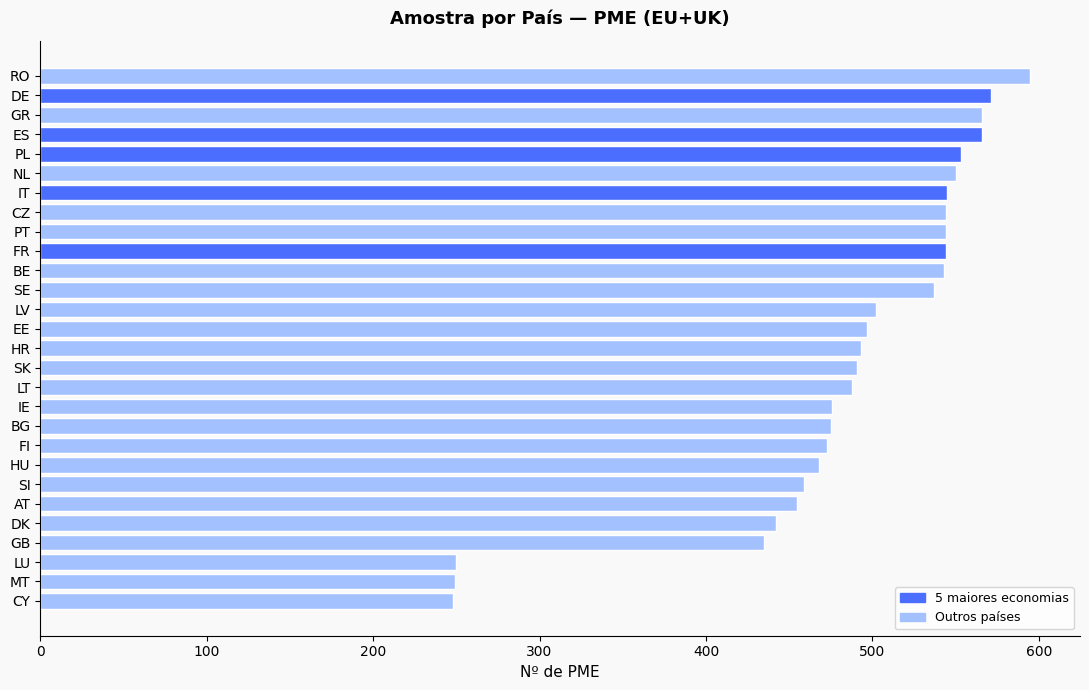

In [19]:
# Gráfico: dimensão da amostra por país
country_counts = df_key['isocntry'].value_counts().sort_values()
colors = [BLUE if c in ['DE','FR','IT','ES','PL'] else LIGHT_BLUE
          for c in country_counts.index]

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.barh(country_counts.index, country_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Nº de PME', fontsize=11)
ax.set_title('Amostra por País — PME (EU+UK)', fontsize=13, fontweight='bold', pad=12)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,       label='5 maiores economias'),
    mpatches.Patch(color=LIGHT_BLUE, label='Outros países'),
], fontsize=9, loc='lower right')
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

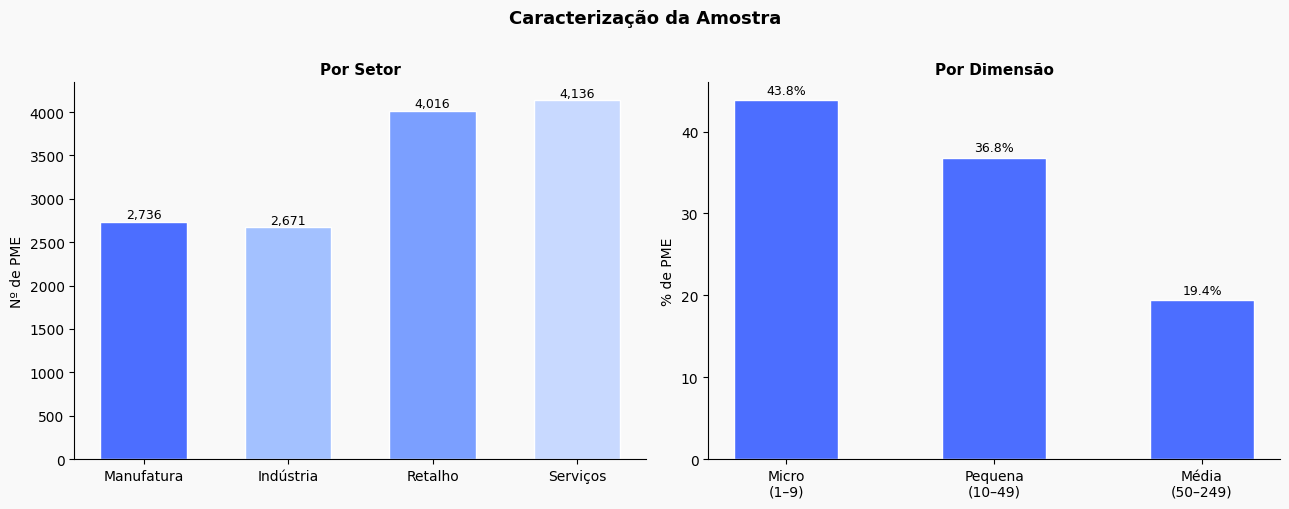

In [20]:
# Gráficos: distribuição por setor e dimensão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Setor
PALETTE = ['#4C6EFF','#A3C1FF','#7B9FFF','#C8D9FF']
sector_counts = df_key['nace_b'].value_counts()
bars = axes[0].bar(sector_short,
                   [sector_counts.get(s,0) for s in sector_order],
                   color=PALETTE, edgecolor='white', width=0.6)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+40,
                 f'{int(h):,}', ha='center', fontsize=9)
axes[0].set_ylabel('Nº de PME', fontsize=10)
axes[0].set_title('Por Setor', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Dimensão
size_counts = (df_key['scr10'].value_counts(normalize=True)
               .reindex(size_order, fill_value=0)*100)
bars2 = axes[1].bar(size_short, size_counts.values,
                    color=BLUE, width=0.5, edgecolor='white')
for bar, val in zip(bars2, size_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('% de PME', fontsize=10)
axes[1].set_title('Por Dimensão', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Caracterização da Amostra', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 2.2 Análise de Missing Values

> Identificação dos padrões de não-resposta — essencial para fundamentar as decisões de tratamento da Secção 3.
>
> **Nota importante:** As variáveis Q3, Q4 e Q7 só foram perguntadas às empresas que adotaram pelo menos uma prática de eficiência (Q1 ≥ 1). As empresas com NaN nestas variáveis são, portanto, as que responderam "não" a todas as práticas Q1 — trata-se de **lógica de salto do questionário**, não de não-resposta aleatória.

In [21]:
# Análise de missing values — contagem absoluta e percentagem
# Esta análise é essencial para fundamentar as decisões de tratamento da Secção 3
missing_n   = df_key.isnull().sum()
missing_pct = (missing_n / len(df_key) * 100).round(1)
missing_df  = pd.DataFrame({'n': missing_n, 'pct': missing_pct})
missing_df  = missing_df.query('n > 0').sort_values('pct', ascending=False)

print("=== MISSING VALUES — df_key ===")
print(missing_df.to_string())
print(f"\nVariáveis sem NAs: {(df_key.isnull().sum() == 0).sum()}")
print(f"Variáveis com NAs: {(df_key.isnull().sum() > 0).sum()}")

=== MISSING VALUES — df_key ===
          n  pct
q4      951  7.0
q3      951  7.0
q7.2    951  7.0
q7.1    951  7.0
q7.3    951  7.0
q7.4    951  7.0
q7.6    951  7.0
q7.5    951  7.0
q7.9    951  7.0
q7.10   951  7.0
q7.7    951  7.0
q7.8    951  7.0
q7.11   951  7.0
q7.12   951  7.0
scr13a  627  4.6
scr11a   99  0.7

Variáveis sem NAs: 16
Variáveis com NAs: 16


In [22]:
# Identificação do padrão de NAs
# Hipótese: os NAs em q3/q4/q7.x correspondem a lógica de salto do questionário
# → empresas que não adotaram nenhuma prática Q1 não foram questionadas sobre Q3/Q4/Q7

mask_na = df_key['q3'].isnull()
print(f"Empresas com q3 nulo:         {mask_na.sum():,} ({mask_na.mean()*100:.1f}%)")
print(f"  → q4 também nulo:           {df_key[mask_na]['q4'].isnull().sum():,}")
print(f"  → q7.1 também nulo:         {df_key[mask_na]['q7.1'].isnull().sum():,}")
print(f"  → q7.10 também nulo:        {df_key[mask_na]['q7.10'].isnull().sum():,}")
print(f"  → isocntry nulo:            {df_key[mask_na]['isocntry'].isnull().sum():,}")
print("\n→ Todas as variáveis Q3/Q4/Q7 em falta para o mesmo bloco de empresas.")

# ── Prova da lógica de salto ──────────────────────────────────────────────────
# Se a hipótese estiver correta, TODAS estas empresas terão Q1 = 0 em todas as práticas
q1_cols = list(q1_map.keys())
na_q1_sum = df_key.loc[mask_na, q1_cols].apply(lambda c: (c == 1.0).sum()).sum()
print(f"\n=== VERIFICAÇÃO DA LÓGICA DE SALTO ===")
print(f"Empresas com NAs em Q3/Q4/Q7:    {mask_na.sum():,}")
print(f"  → total de práticas Q1=1 neste grupo: {na_q1_sum}")
print(f"  → TODAS têm Q1=0:              {na_q1_sum == 0}")
print(f"\n→ CONFIRMADO: 100% destas empresas têm Q1 = 0 (nenhuma prática adotada).")
print(f"   Os NAs em Q3/Q4/Q7 são lógica de salto do questionário, não missing aleatório.")
print(f"   Estas empresas devem ser MANTIDAS no dataset (não eliminadas).")
print(f"   → Na Secção 3: Q7 será codificado como 0 (barreiras não aplicáveis)")
print(f"     e Q3/Q4 receberão uma categoria indicadora ('Não questionado').")

print("\n=== PERFIL DAS EMPRESAS COM NAs (Q1 = 0) ===")
print("\nPor país (top 10):")
print(df_key[mask_na]['isocntry'].value_counts().head(10))
print("\nPor setor:")
print(df_key[mask_na]['nace_b'].map(sector_map).value_counts())
print("\nPor dimensão:")
print(df_key[mask_na]['scr10'].map(size_map).value_counts())


Empresas com q3 nulo:         951 (7.0%)
  → q4 também nulo:           951
  → q7.1 também nulo:         951
  → q7.10 também nulo:        951
  → isocntry nulo:            0

→ Todas as variáveis Q3/Q4/Q7 em falta para o mesmo bloco de empresas.

=== VERIFICAÇÃO DA LÓGICA DE SALTO ===
Empresas com NAs em Q3/Q4/Q7:    951
  → total de práticas Q1=1 neste grupo: 0
  → TODAS têm Q1=0:              True

→ CONFIRMADO: 100% destas empresas têm Q1 = 0 (nenhuma prática adotada).
   Os NAs em Q3/Q4/Q7 são lógica de salto do questionário, não missing aleatório.
   Estas empresas devem ser MANTIDAS no dataset (não eliminadas).
   → Na Secção 3: Q7 será codificado como 0 (barreiras não aplicáveis)
     e Q3/Q4 receberão uma categoria indicadora ('Não questionado').

=== PERFIL DAS EMPRESAS COM NAs (Q1 = 0) ===

Por país (top 10):
isocntry
LV    103
RO     81
EE     64
HR     58
PL     48
DE     47
GR     47
PT     47
HU     45
SI     42
Name: count, dtype: int64

Por setor:
nace_b
Serviços (H–M)

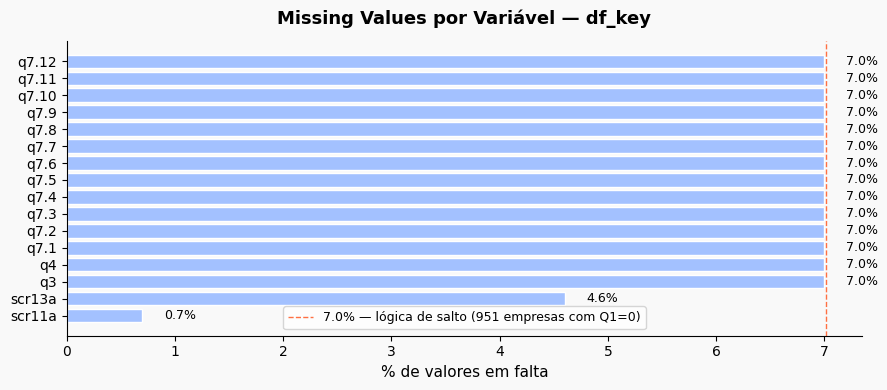

In [23]:
# Visualização dos missing values
# As barras a laranja indicam variáveis afetadas pela lógica de salto (Q1=0 → Q3/Q4/Q7 não perguntados)
n_na_bloco = df_key['q3'].isnull().sum()
pct_bloco  = n_na_bloco / len(df_key) * 100

missing_plot = (df_key.isnull().mean() * 100).round(1)
missing_plot = missing_plot[missing_plot > 0].sort_values()

fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
colors_m = [ORANGE if v >= pct_bloco else LIGHT_BLUE for v in missing_plot.values]
ax.barh(missing_plot.index, missing_plot.values, color=colors_m, edgecolor='white')
for bar, val in zip(ax.patches, missing_plot.values):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.axvline(pct_bloco, color=ORANGE, linestyle='--', linewidth=1,
           label=f'{pct_bloco:.1f}% — lógica de salto ({n_na_bloco:,} empresas com Q1=0)')
ax.set_xlabel('% de valores em falta', fontsize=11)
ax.set_title('Missing Values por Variável — df_key', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2.3 Identificação de Outliers e Problemas de Qualidade

> Os problemas são mostrados aqui, **antes** de qualquer tratamento, para que as decisões da Secção 3 sejam fundamentadas.

### 2.3.1 scr12a — Anos de fundação impossíveis

In [24]:
# Outliers em scr12a (ano de fundação)
# scr12a é numérica contínua — esperamos anos entre ~1900 e 2024
# Código 9998.0 = DK/NA (específico desta variável, não apanhado pelo recoding geral)

scr12a_num = df['scr12a'].copy()
n_dkna_12a = (scr12a_num == 9998.0).sum()
scr12a_years = scr12a_num[(scr12a_num != 9998.0) & scr12a_num.notna()]

print("=== scr12a — ANO DE FUNDAÇÃO ===")
print(scr12a_years.describe())

print("\nValores mais antigos (possíveis outliers):")
print(scr12a_years.sort_values().head(20).value_counts().sort_index())

print("\nValores mais recentes:")
print(scr12a_years.sort_values().tail(5).value_counts().sort_index())

n_impossivel = (scr12a_years < 1900).sum()
print(f"\nAnos antes de 1900 (impossíveis): {n_impossivel}")
print(f"DK/NA (9998):                      {n_dkna_12a:,} ({n_dkna_12a/len(df)*100:.1f}%)")

# scr12 categórica como alternativa (código 5.0 = DK/NA)
n_dkna_12 = (df_key['scr12'] == 5.0).sum()
print(f"\n→ Decisão: usar scr12 (categórica) em vez de scr12a")
print(f"  scr12 tem apenas {n_dkna_12:,} DK/NA ({n_dkna_12/len(df_key)*100:.1f}%)")

=== scr12a — ANO DE FUNDAÇÃO ===
count    11809.000000
mean      2000.078669
std         20.912816
min       1750.000000
25%       1992.000000
50%       2004.000000
75%       2014.000000
max       2024.000000
Name: scr12a, dtype: float64

Valores mais antigos (possíveis outliers):
scr12a
1750.0    1
1777.0    1
1800.0    1
1802.0    1
1804.0    1
1812.0    1
1821.0    1
1823.0    1
1824.0    1
1829.0    1
1831.0    1
1839.0    1
1840.0    1
1841.0    1
1843.0    1
1852.0    1
1854.0    1
1856.0    2
1863.0    1
Name: count, dtype: int64

Valores mais recentes:
scr12a
2024.0    5
Name: count, dtype: int64

Anos antes de 1900 (impossíveis): 67
DK/NA (9998):                      1,750 (12.9%)

→ Decisão: usar scr12 (categórica) em vez de scr12a
  scr12 tem apenas 70 DK/NA (0.5%)


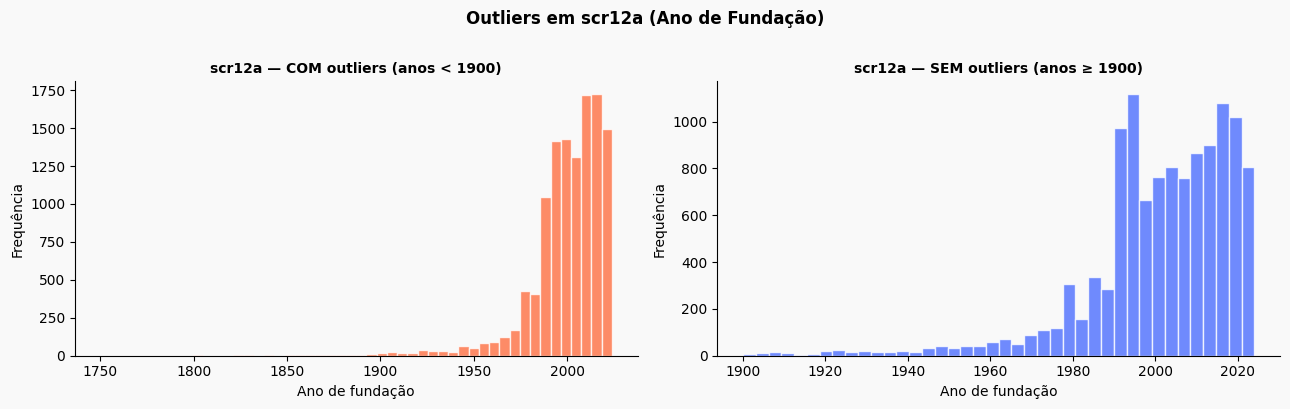

In [25]:
# Visualização da distribuição de scr12a — mostrar os outliers
scr12a_plot = scr12a_years.dropna()
scr12a_valid = scr12a_plot[scr12a_plot >= 1900]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)

# Com outliers
axes[0].hist(scr12a_plot, bins=50, color=ORANGE, edgecolor='white', alpha=0.8)
axes[0].set_title('scr12a — COM outliers (anos < 1900)', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Ano de fundação'); axes[0].set_ylabel('Frequência')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Sem outliers
axes[1].hist(scr12a_valid, bins=40, color=BLUE, edgecolor='white', alpha=0.8)
axes[1].set_title('scr12a — SEM outliers (anos ≥ 1900)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Ano de fundação'); axes[1].set_ylabel('Frequência')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Outliers em scr12a (Ano de Fundação)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.3.2 scr10a — Nº exato de FTE (após filtro PME)

=== scr10a — Nº EXATO DE FTE (após filtro PME) ===
count    13071.000000
mean        31.743172
std         47.790328
min          0.000000
25%          3.000000
50%         12.000000
75%         38.000000
max        249.000000
Name: scr10a, dtype: float64

Valores > 249: 0 → deve ser 0 após filtro PME
Valores = 0:   224
Valores = 1:   1,362 (microempresas unipessoais — válidas)


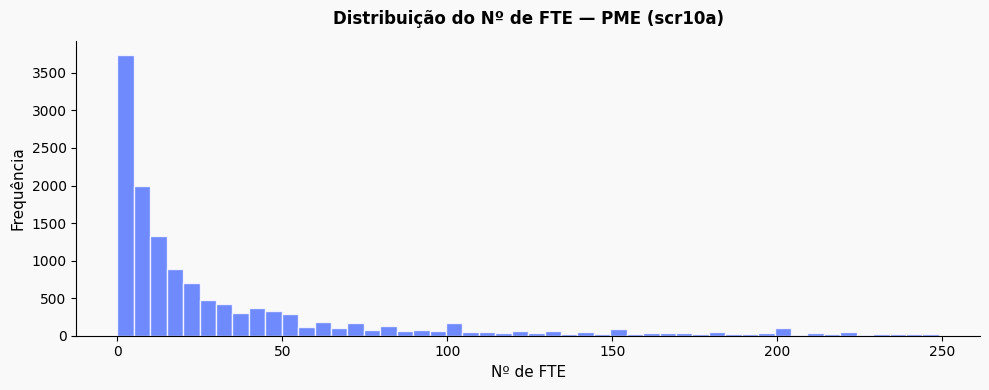

In [26]:
# Outliers em scr10a (nº exato de FTE)
# Após filtro PME esperamos apenas valores entre 1 e 249

scr10a_num = df['scr10a'].copy()

print("=== scr10a — Nº EXATO DE FTE (após filtro PME) ===")
print(scr10a_num.describe())
print(f"\nValores > 249: {(scr10a_num > 249).sum()} → deve ser 0 após filtro PME")
print(f"Valores = 0:   {(scr10a_num == 0).sum()}")
print(f"Valores = 1:   {(scr10a_num == 1).sum():,} (microempresas unipessoais — válidas)")

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
ax.hist(scr10a_num.dropna(), bins=50, color=BLUE, edgecolor='white', alpha=0.8)
ax.set_xlabel('Nº de FTE', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição do Nº de FTE — PME (scr10a)', fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.3.3 scr11b — Problema de construto

In [27]:
# Problema conceptual em scr11b — não é um outlier mas um problema de construto
# A variável mistura dois conceitos distintos:
#   (a) dificuldade de recrutamento — para quem tentou contratar
#   (b) decisão de não contratar — código 4.0 "Not relevant. Did not hire"
# Isto torna a variável não comparável numa escala única
#
# Códigos: 1=Muito difícil, 2=Algo difícil, 3=Nada difícil, 4=Não recrutou

scr11b_labels = {
    1.0: 'Muito difícil',
    2.0: 'Algo difícil',
    3.0: 'Nada difícil',
    4.0: 'Não recrutou',
}

print("=== scr11b — DIFICULDADE DE RECRUTAMENTO ===")
print(df['scr11b'].map(scr11b_labels).value_counts(dropna=False))
print()
n_not_relevant = (df['scr11b'] == 4.0).sum()
print(f"'Não recrutou' representa {n_not_relevant:,} empresas ({n_not_relevant/len(df)*100:.1f}%)")
print("→ Decisão: desdobrar em hired_bin + fin_difficulty (ver Secção 3)")

=== scr11b — DIFICULDADE DE RECRUTAMENTO ===
scr11b
Muito difícil    5061
Algo difícil     3475
Não recrutou     3069
Nada difícil     1819
NaN               135
Name: count, dtype: int64

'Não recrutou' representa 3,069 empresas (22.6%)
→ Decisão: desdobrar em hired_bin + fin_difficulty (ver Secção 3)


### 2.3.4 scr14 — Volume de negócios: DK/NA elevado

In [28]:
# Análise do DK/NA em scr14 (volume de negócios)
# Código 10.0 = DK/NA (específico desta variável)
# Empresas que não conhecem o seu volume de negócios tendem a ser microempresas
# sem contabilidade formal — excluí-las sub-representaria este segmento

scr14_labels = {
    1.0: '< 25k€', 2.0: '25–50k€', 3.0: '50–100k€',
    4.0: '100–250k€', 5.0: '250–500k€', 6.0: '500k–2M€',
    7.0: '2–10M€', 8.0: '10–50M€', 9.0: '> 50M€', 10.0: 'DK/NA',
}

print("=== scr14 — VOLUME DE NEGÓCIOS ANUAL ===")
print(df_key['scr14'].map(scr14_labels).value_counts(dropna=False))

n_dkna = (df_key['scr14'] == 10.0).sum()
print(f"\nDK/NA: {n_dkna:,} ({n_dkna/len(df_key)*100:.1f}%)")
print("→ Decisão: criar dummy turnover_unknown = 1 para preservar estas observações")

# Verificar se DK/NA se concentra em microempresas
print("\nDK/NA por dimensão:")
mask_dkna = df_key['scr14'] == 10.0
print(df_key[mask_dkna]['scr10'].map(size_map).value_counts())

=== scr14 — VOLUME DE NEGÓCIOS ANUAL ===
scr14
500k–2M€     2636
2–10M€       2197
DK/NA        1810
100–250k€    1522
250–500k€    1397
10–50M€      1116
50–100k€     1010
25–50k€       914
< 25k€        699
> 50M€        258
Name: count, dtype: int64

DK/NA: 1,810 (13.3%)
→ Decisão: criar dummy turnover_unknown = 1 para preservar estas observações

DK/NA por dimensão:
scr10
Micro (1–9)        772
Pequena (10–49)    651
Média (50–249)     387
Name: count, dtype: int64


### 2.3.5 Resumo dos problemas identificados

In [29]:
# Resumo dos problemas identificados na AED — serão tratados na Secção 3
n_na_skip = df_key['q3'].isnull().sum()
pct_na = n_na_skip / len(df_key) * 100

print("=" * 60)
print("  RESUMO — PROBLEMAS IDENTIFICADOS NA AED")
print("=" * 60)
print()
print(f"1. LÓGICA DE SALTO DO QUESTIONÁRIO ({pct_na:.1f}% — {n_na_skip:,} empresas)")
print("   Variáveis: q3, q4, q7.1–q7.12")
print("   Causa: empresas com Q1=0 (nenhuma prática) não foram questionadas")
print("   → NÃO é missing aleatório — é informação determinística")
print("   Tratamento: MANTER no dataset")
print("     • Q7 → codificar como 0 (barreiras não aplicáveis)")
print("     • Q3/Q4 → categoria indicadora 'Não questionado'")
print()
print("2. scr12a — ANOS DE FUNDAÇÃO IMPOSSÍVEIS")
print("   Problema: valores como 1750, 1777, 1800...")
print("   Tratamento: substituir por scr12 (categórica, poucos DK/NA)")
print()
print("3. scr11b — PROBLEMA DE CONSTRUTO")
print("   Problema: mistura dificuldade de recrutamento com não-recrutamento")
print("   Tratamento: desdobrar em hired_bin + fin_difficulty")
print()
n_dkna_14 = (df_key['scr14'] == 10.0).sum()
print(f"4. scr14 — {n_dkna_14/len(df_key)*100:.1f}% DK/NA")
print("   Problema: muitos DK/NA para exclusão simples")
print("   Tratamento: manter + criar dummy turnover_unknown")
print()
print("5. q3, q4 — ~10% DK/NA (além da lógica de salto)")
print("   Problema: DK/NA informativo (menor sofisticação de gestão)")
print("   Tratamento: manter como categoria separada")
print("=" * 60)

  RESUMO — PROBLEMAS IDENTIFICADOS NA AED

1. LÓGICA DE SALTO DO QUESTIONÁRIO (7.0% — 951 empresas)
   Variáveis: q3, q4, q7.1–q7.12
   Causa: empresas com Q1=0 (nenhuma prática) não foram questionadas
   → NÃO é missing aleatório — é informação determinística
   Tratamento: MANTER no dataset
     • Q7 → codificar como 0 (barreiras não aplicáveis)
     • Q3/Q4 → categoria indicadora 'Não questionado'

2. scr12a — ANOS DE FUNDAÇÃO IMPOSSÍVEIS
   Problema: valores como 1750, 1777, 1800...
   Tratamento: substituir por scr12 (categórica, poucos DK/NA)

3. scr11b — PROBLEMA DE CONSTRUTO
   Problema: mistura dificuldade de recrutamento com não-recrutamento
   Tratamento: desdobrar em hired_bin + fin_difficulty

4. scr14 — 13.3% DK/NA
   Problema: muitos DK/NA para exclusão simples
   Tratamento: manter + criar dummy turnover_unknown

5. q3, q4 — ~10% DK/NA (além da lógica de salto)
   Problema: DK/NA informativo (menor sofisticação de gestão)
   Tratamento: manter como categoria separada


## 2.4 Variável Dependente — Análise Univariada

> O índice de intensidade é construído aqui sobre o df_key (com NAs) apenas para fins exploratórios. O índice final para modelação é construído na Secção 3 sobre o df_model.

In [30]:
# Construção prévia do índice para análise exploratória
# Q1.x: 0.0 = não mencionada, 1.0 = mencionada → já binárias
# Nota: construído sobre df_key (com NAs) apenas para a AED

q1_cols = list(q1_map.keys())
for col in q1_cols:
    df_key[col+'_bin'] = (df_key[col] == 1.0).astype(int)

bin_cols = [c+'_bin' for c in q1_cols]
df_key['intensity_index'] = df_key[bin_cols].sum(axis=1)

print("=== ÍNDICE DE INTENSIDADE — df_key (inclui NAs) ===")
print(df_key['intensity_index'].value_counts().sort_index())
print(f"\nMédia:   {df_key['intensity_index'].mean():.2f}")
print(f"Mediana: {df_key['intensity_index'].median():.1f}")
print(f"Std:     {df_key['intensity_index'].std():.2f}")
print(f"Mín/Máx: {int(df_key['intensity_index'].min())} / {int(df_key['intensity_index'].max())}")

=== ÍNDICE DE INTENSIDADE — df_key (inclui NAs) ===
intensity_index
0     951
1    1183
2    1449
3    1963
4    2234
5    2094
6    1660
7    1202
8     613
9     210
Name: count, dtype: int64

Média:   4.02
Mediana: 4.0
Std:     2.24
Mín/Máx: 0 / 9


In [31]:
# Confirmação: empresas da lógica de salto (Q3=NaN) vs restantes
# Este teste NÃO serve para avaliar aleatoriedade do missing —
# sabemos que é determinístico (Q1=0 → Q3/Q4/Q7 não perguntados).
# Serve apenas para quantificar a diferença no índice entre os dois grupos.

mask_na = df_key['q3'].isnull()

print("=== COMPARAÇÃO: EMPRESAS COM Q1=0 (salto) vs Q1≥1 ===")
print(f"\nEmpresas com Q1=0 (lógica de salto):  {mask_na.sum():,}")
print(f"  Índice: {df_key[mask_na]['intensity_index'].mean():.2f} (por definição = 0)")
print(f"\nEmpresas com Q1≥1 (responderam Q3/Q4/Q7): {(~mask_na).sum():,}")
print(f"  Índice médio: {df_key[~mask_na]['intensity_index'].mean():.2f}")
print(f"  Índice mediano: {df_key[~mask_na]['intensity_index'].median():.1f}")

print(f"\n→ A diferença é trivialmente significativa porque o grupo Q1=0 tem")
print(f"  índice=0 por construção. Não se trata de missing — são empresas que")
print(f"  genuinamente não adotaram nenhuma prática de eficiência de recursos.")
print(f"  Eliminá-las (listwise deletion) removeria informação válida e enviesaria")
print(f"  o modelo para cima.")

=== COMPARAÇÃO: EMPRESAS COM Q1=0 (salto) vs Q1≥1 ===

Empresas com Q1=0 (lógica de salto):  951
  Índice: 0.00 (por definição = 0)

Empresas com Q1≥1 (responderam Q3/Q4/Q7): 12,608
  Índice médio: 4.33
  Índice mediano: 4.0

→ A diferença é trivialmente significativa porque o grupo Q1=0 tem
  índice=0 por construção. Não se trata de missing — são empresas que
  genuinamente não adotaram nenhuma prática de eficiência de recursos.
  Eliminá-las (listwise deletion) removeria informação válida e enviesaria
  o modelo para cima.


In [32]:
# ── Teste de Mann-Whitney — MCAR vs MNAR ────────────────────────────────────
# H0: empresas sem Q3 (skip-logic, Q1=0) têm a mesma distribuição de
# intensity_index que as restantes.
# p < 0.05 → MNAR: adotam sistematicamente menos práticas — esperado, dado
# que o questionário só perguntou Q3/Q4 a quem reportou pelo menos uma prática Q1.

from scipy.stats import mannwhitneyu

mask_na = df_key['q3'].isnull()

stat, p = mannwhitneyu(
    df_key.loc[mask_na,  'intensity_index'].dropna(),
    df_key.loc[~mask_na, 'intensity_index'].dropna(),
    alternative='two-sided'
)

print("=== TESTE MCAR vs MNAR — Empresas skip-logic (Q3=NaN) ===\n")
print(f"  Empresas Q3=NaN (Q1=0): {mask_na.sum():,}  |  intensity médio: "
      f"{df_key.loc[mask_na, 'intensity_index'].mean():.3f}")
print(f"  Empresas Q3 respondido: {(~mask_na).sum():,}  |  intensity médio: "
      f"{df_key.loc[~mask_na, 'intensity_index'].mean():.3f}")
print(f"\n  Mann-Whitney U = {stat:.0f},  p = {p:.4e}")
if p < 0.05:
    print("  → MNAR confirmado: empresas sem Q3 adotam sistematicamente menos práticas.")
else:
    print("  → Sem evidência de MNAR.")
print("\n  Tratamento adotado: Q3=ref, Q4=ref, Q7=0 (conservador — mantém todas as obs).")


=== TESTE MCAR vs MNAR — Empresas skip-logic (Q3=NaN) ===

  Empresas Q3=NaN (Q1=0): 951  |  intensity médio: 0.000
  Empresas Q3 respondido: 12,608  |  intensity médio: 4.326

  Mann-Whitney U = 0,  p = 0.0000e+00
  → MNAR confirmado: empresas sem Q3 adotam sistematicamente menos práticas.

  Tratamento adotado: Q3=ref, Q4=ref, Q7=0 (conservador — mantém todas as obs).


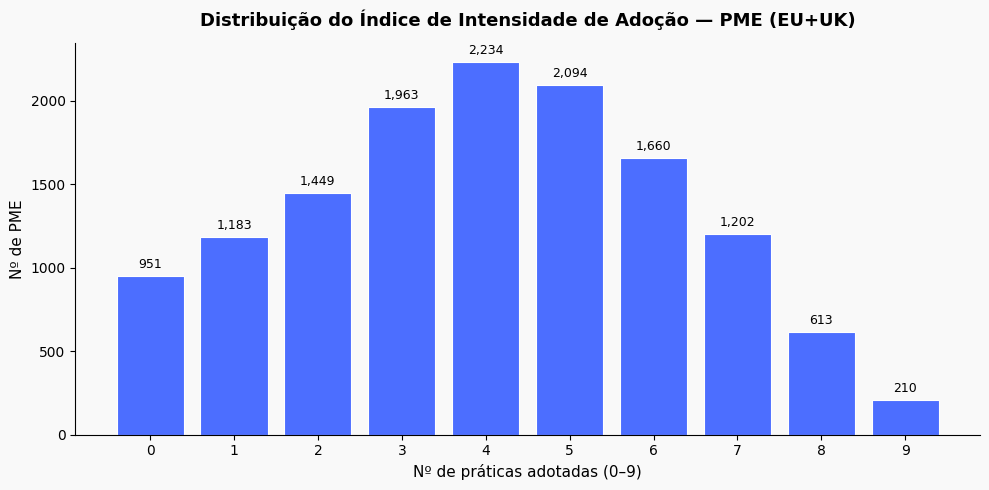

In [33]:
# Distribuição do índice de intensidade — primeiro olhar sobre a VD

counts = df_key['intensity_index'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
bars = ax.bar(counts.index, counts.values, color=BLUE, edgecolor='white', linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+30,
            f'{int(h):,}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Nº de práticas adotadas (0–9)', fontsize=11)
ax.set_ylabel('Nº de PME', fontsize=11)
ax.set_title('Distribuição do Índice de Intensidade de Adoção — PME (EU+UK)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(range(10))
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

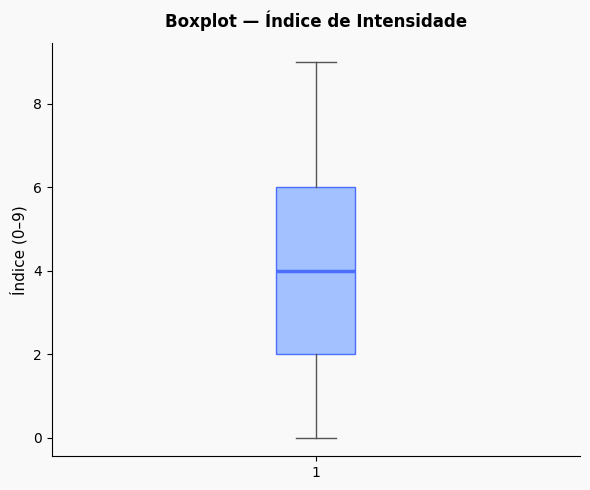

count    13559.00
mean         4.02
std          2.24
min          0.00
25%          2.00
50%          4.00
75%          6.00
max          9.00
Name: intensity_index, dtype: float64


In [34]:
# Boxplot do índice — distribuição, mediana e valores extremos

fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.boxplot(df_key['intensity_index'].dropna(), patch_artist=True,
           boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
           medianprops=dict(color=BLUE, linewidth=2.5),
           whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
           flierprops=dict(marker='o', color=ORANGE, alpha=0.3, markersize=3))
ax.set_ylabel('Índice (0–9)', fontsize=11)
ax.set_title('Boxplot — Índice de Intensidade', fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(df_key['intensity_index'].describe().round(2))

### 2.4.1 Impacto dos Pesos de Inquérito (w1_sme)

> Os pesos pós-estratificação corrigem desvios entre a amostra e a população-alvo. Comparar estatísticas ponderadas e não ponderadas permite avaliar a magnitude do viés amostral.

In [35]:
# Comparação ponderada vs não ponderada — índice de intensidade
# w1_sme: peso pós-estratificação para PME (média ≈ 1.0)

w = df_key['w1_sme']
idx = df_key['intensity_index']

# Média ponderada
wt_mean = np.average(idx, weights=w)
# Variância ponderada (reliability weights)
wt_var  = np.average((idx - wt_mean)**2, weights=w)
wt_std  = np.sqrt(wt_var)

print("=== ÍNDICE DE INTENSIDADE — PONDERADO vs NÃO PONDERADO ===")
print(f"{'Estatística':<20} {'Não ponderado':>15} {'Ponderado (w1_sme)':>20}")
print(f"{'─'*57}")
print(f"{'Média':<20} {idx.mean():>15.3f} {wt_mean:>20.3f}")
print(f"{'Desvio-padrão':<20} {idx.std():>15.3f} {wt_std:>20.3f}")
print(f"{'Mediana':<20} {idx.median():>15.1f} {'—':>20}")
print(f"{'N':<20} {len(idx):>15,} {len(idx):>20,}")

diff = idx.mean() - wt_mean
print(f"\nDiferença (não pond. − pond.): {diff:+.3f}")
print(f"→ A média não ponderada sobrestima o índice em {diff:.2f} pontos (escala 0–9).")
print(f"   Isto indica que países/segmentos com maior adoção estão sobre-representados na amostra.")

# Comparação por dimensão — onde o peso mais importa?
print(f"\n{'─'*60}")
print(f"{'Dimensão':<20} {'Não pond.':>10} {'Ponderado':>10} {'Diferença':>10}")
print(f"{'─'*60}")
for s in size_order:
    mask = df_key['scr10'] == s
    uw = idx[mask].mean()
    wm = np.average(idx[mask], weights=w[mask])
    print(f"{size_map[s]:<20} {uw:>10.3f} {wm:>10.3f} {uw-wm:>+10.3f}")

# Comparação por setor
print(f"\n{'─'*60}")
print(f"{'Setor':<25} {'Não pond.':>10} {'Ponderado':>10} {'Diferença':>10}")
print(f"{'─'*60}")
for s in sector_order:
    mask = df_key['nace_b'] == s
    uw = idx[mask].mean()
    wm = np.average(idx[mask], weights=w[mask])
    print(f"{sector_map[s]:<25} {uw:>10.3f} {wm:>10.3f} {uw-wm:>+10.3f}")

=== ÍNDICE DE INTENSIDADE — PONDERADO vs NÃO PONDERADO ===
Estatística            Não ponderado   Ponderado (w1_sme)
─────────────────────────────────────────────────────────
Média                          4.023                3.648
Desvio-padrão                  2.243                2.231
Mediana                          4.0                    —
N                             13,559               13,559

Diferença (não pond. − pond.): +0.374
→ A média não ponderada sobrestima o índice em 0.37 pontos (escala 0–9).
   Isto indica que países/segmentos com maior adoção estão sobre-representados na amostra.

────────────────────────────────────────────────────────────
Dimensão              Não pond.  Ponderado  Diferença
────────────────────────────────────────────────────────────
Micro (1–9)               3.690      3.618     +0.072
Pequena (10–49)           4.128      4.027     +0.101
Média (50–249)            4.575      4.449     +0.126

──────────────────────────────────────────────────

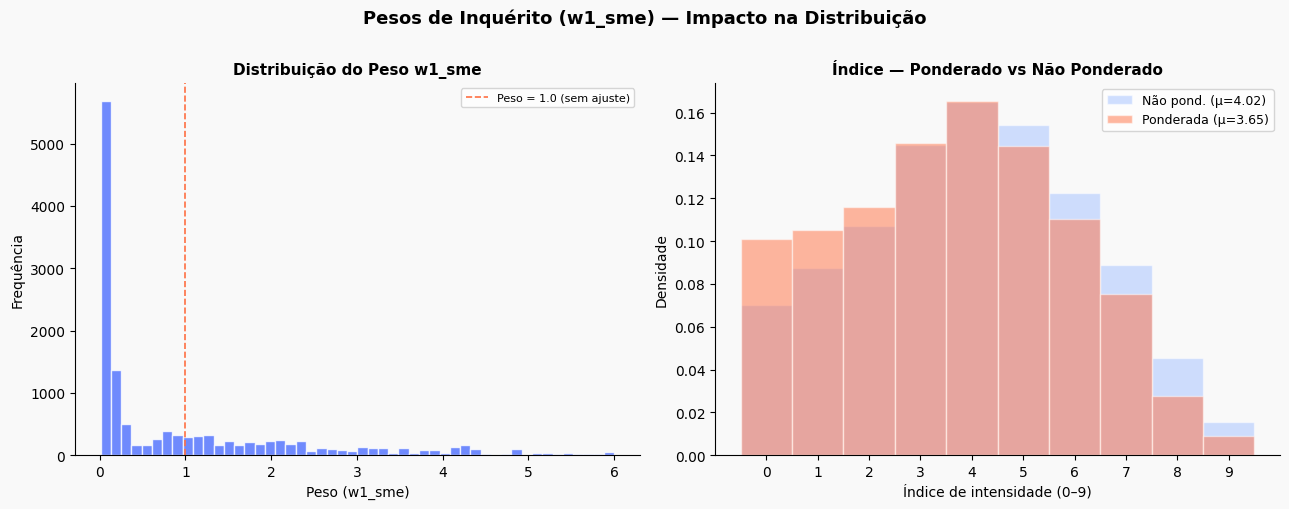

Peso w1_sme: média=1.000, std=1.341, min=0.011, max=6.000


In [36]:
# Distribuição dos pesos e comparação visual ponderada vs não ponderada

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Distribuição do peso w1_sme
axes[0].hist(df_key['w1_sme'].dropna(), bins=50, color=BLUE, edgecolor='white', alpha=0.8)
axes[0].axvline(1.0, color=ORANGE, linestyle='--', linewidth=1.2, label='Peso = 1.0 (sem ajuste)')
axes[0].set_xlabel('Peso (w1_sme)', fontsize=10)
axes[0].set_ylabel('Frequência', fontsize=10)
axes[0].set_title('Distribuição do Peso w1_sme', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Comparação: distribuição ponderada vs não ponderada do índice
bins = np.arange(-0.5, 10.5, 1)
# Não ponderada
axes[1].hist(idx, bins=bins, density=True, alpha=0.5, color=LIGHT_BLUE,
             edgecolor='white', label=f'Não pond. (μ={idx.mean():.2f})')
# Ponderada
axes[1].hist(idx, bins=bins, density=True, weights=w, alpha=0.5, color=ORANGE,
             edgecolor='white', label=f'Ponderada (μ={wt_mean:.2f})')
axes[1].set_xlabel('Índice de intensidade (0–9)', fontsize=10)
axes[1].set_ylabel('Densidade', fontsize=10)
axes[1].set_title('Índice — Ponderado vs Não Ponderado', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(10))
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Pesos de Inquérito (w1_sme) — Impacto na Distribuição',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"Peso w1_sme: média={w.mean():.3f}, std={w.std():.3f}, min={w.min():.3f}, max={w.max():.3f}")

In [37]:
# Empresas nos extremos do índice — quem são?

print("=== EMPRESAS COM ÍNDICE = 0 (nenhuma prática) ===")
zero = df_key[df_key['intensity_index'] == 0]
print(f"Total: {len(zero):,} ({len(zero)/len(df_key)*100:.1f}%)")
print("\nPor setor:")
print(zero['nace_b'].map(sector_map).value_counts())
print("\nPor dimensão:")
print(zero['scr10'].map(size_map).value_counts())

print("\n=== EMPRESAS COM ÍNDICE = 9 (todas as práticas) ===")
nine = df_key[df_key['intensity_index'] == 9]
print(f"Total: {len(nine):,} ({len(nine)/len(df_key)*100:.1f}%)")
print("\nPor setor:")
print(nine['nace_b'].map(sector_map).value_counts())
print("\nPor dimensão:")
print(nine['scr10'].map(size_map).value_counts())

=== EMPRESAS COM ÍNDICE = 0 (nenhuma prática) ===
Total: 951 (7.0%)

Por setor:
nace_b
Serviços (H–M)         393
Retalho (G)            272
Indústria (B/D/E/F)    174
Manufatura (C)         112
Name: count, dtype: int64

Por dimensão:
scr10
Micro (1–9)        561
Pequena (10–49)    304
Média (50–249)      86
Name: count, dtype: int64

=== EMPRESAS COM ÍNDICE = 9 (todas as práticas) ===
Total: 210 (1.5%)

Por setor:
nace_b
Manufatura (C)         68
Retalho (G)            60
Serviços (H–M)         48
Indústria (B/D/E/F)    34
Name: count, dtype: int64

Por dimensão:
scr10
Pequena (10–49)    90
Média (50–249)     71
Micro (1–9)        49
Name: count, dtype: int64


In [38]:
# Taxa de adoção por prática — counts e percentagem

print("=== TAXA DE ADOÇÃO POR PRÁTICA (PME — EU+UK) ===")
for col, label in q1_map.items():
    n   = df_key[col+'_bin'].sum()
    pct = df_key[col+'_bin'].mean() * 100
    bar = '█' * int(pct/5)
    print(f"  {label:<35} {n:>5,}  ({pct:.1f}%)  {bar}")

=== TAXA DE ADOÇÃO POR PRÁTICA (PME — EU+UK) ===
  Poupar água                         6,452  (47.6%)  █████████
  Poupar energia                      8,844  (65.2%)  █████████████
  Energia renovável                   3,617  (26.7%)  █████
  Poupar materiais                    7,758  (57.2%)  ███████████
  Fornecedores mais verdes            4,821  (35.6%)  ███████
  Minimizar resíduos                  8,814  (65.0%)  █████████████
  Vender resíduos                     4,010  (29.6%)  █████
  Reciclar internamente               6,438  (47.5%)  █████████
  Eco-design                          3,790  (28.0%)  █████


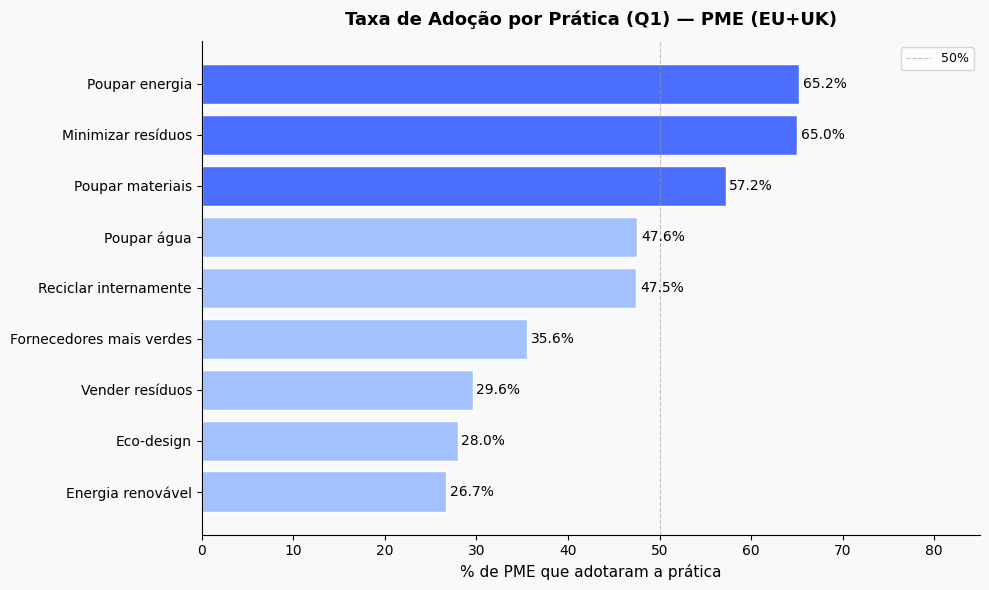

In [39]:
# Gráfico: taxa de adoção por prática
eu_q1 = {label: df_key[col+'_bin'].mean()*100 for col, label in q1_map.items()}
sorted_items = sorted(eu_q1.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
colors_q1 = [BLUE if v >= 50 else LIGHT_BLUE for _, v in sorted_items]
bars = ax.barh([i[0] for i in sorted_items], [i[1] for i in sorted_items],
               color=colors_q1, edgecolor='white')
for bar, val in zip(bars, [i[1] for i in sorted_items]):
    ax.text(val+0.4, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.axvline(50, color='#999', linestyle='--', linewidth=0.8, alpha=0.6, label='50%')
ax.set_xlabel('% de PME que adotaram a prática', fontsize=11)
ax.set_title('Taxa de Adoção por Prática (Q1) — PME (EU+UK)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 85)
ax.legend(fontsize=9)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2.5 Variável Dependente × País

In [40]:
# Índice médio por país — tabela com estatísticas completas
country_stats = (
    df_key.groupby('isocntry')['intensity_index']
    .agg(['mean','median','std','count'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print("=== ÍNDICE MÉDIO POR PAÍS ===")
print(country_stats.to_string())
print(f"\nAmplitude (máx - mín): {country_stats['mean'].max() - country_stats['mean'].min():.2f}")

=== ÍNDICE MÉDIO POR PAÍS ===
          mean  median   std  count
isocntry                           
ES        5.76     6.0  1.91    566
BE        5.34     6.0  2.14    543
SE        5.34     6.0  2.29    537
LT        4.76     5.0  2.21    488
SK        4.73     5.0  2.13    491
FI        4.62     5.0  2.39    473
FR        4.57     5.0  2.27    544
DK        4.57     5.0  2.33    442
CZ        4.52     5.0  2.23    544
DE        4.25     4.0  2.41    571
GR        4.21     5.0  2.34    566
NL        4.08     4.0  1.48    550
LU        4.02     4.0  1.50    250
AT        3.99     4.0  1.36    455
IT        3.97     4.0  1.52    545
GB        3.93     4.0  1.40    435
HU        3.90     4.0  2.32    468
RO        3.76     4.0  2.57    595
BG        3.67     3.0  2.32    475
SI        3.64     3.0  2.43    459
PL        3.31     3.0  2.02    553
MT        3.27     3.0  1.41    249
EE        3.15     3.0  2.37    497
HR        2.98     3.0  2.24    493
CY        2.96     3.0  2.08    24

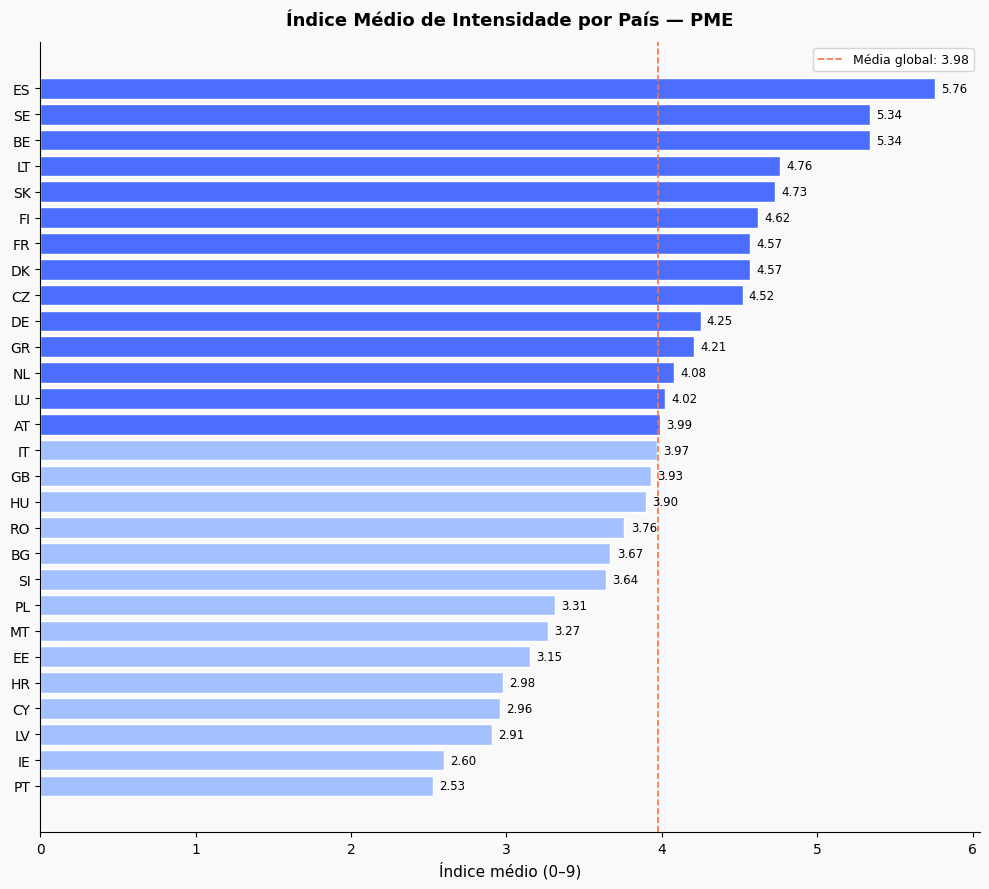

In [41]:
# Gráfico: índice médio por país — acima/abaixo da média global destacados
country_means = df_key.groupby('isocntry')['intensity_index'].mean().round(2).sort_values()
global_mean   = country_means.mean()

fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
colors_c = [BLUE if v >= global_mean else LIGHT_BLUE for v in country_means.values]
ax.barh(country_means.index, country_means.values, color=colors_c, edgecolor='white')
ax.axvline(global_mean, color=ORANGE, linestyle='--', linewidth=1.2,
           label=f"Média global: {global_mean:.2f}")
for i, val in enumerate(country_means.values):
    ax.text(val+0.04, i, f'{val:.2f}', va='center', fontsize=8.5)
ax.set_xlabel('Índice médio (0–9)', fontsize=11)
ax.set_title('Índice Médio de Intensidade por País — PME',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

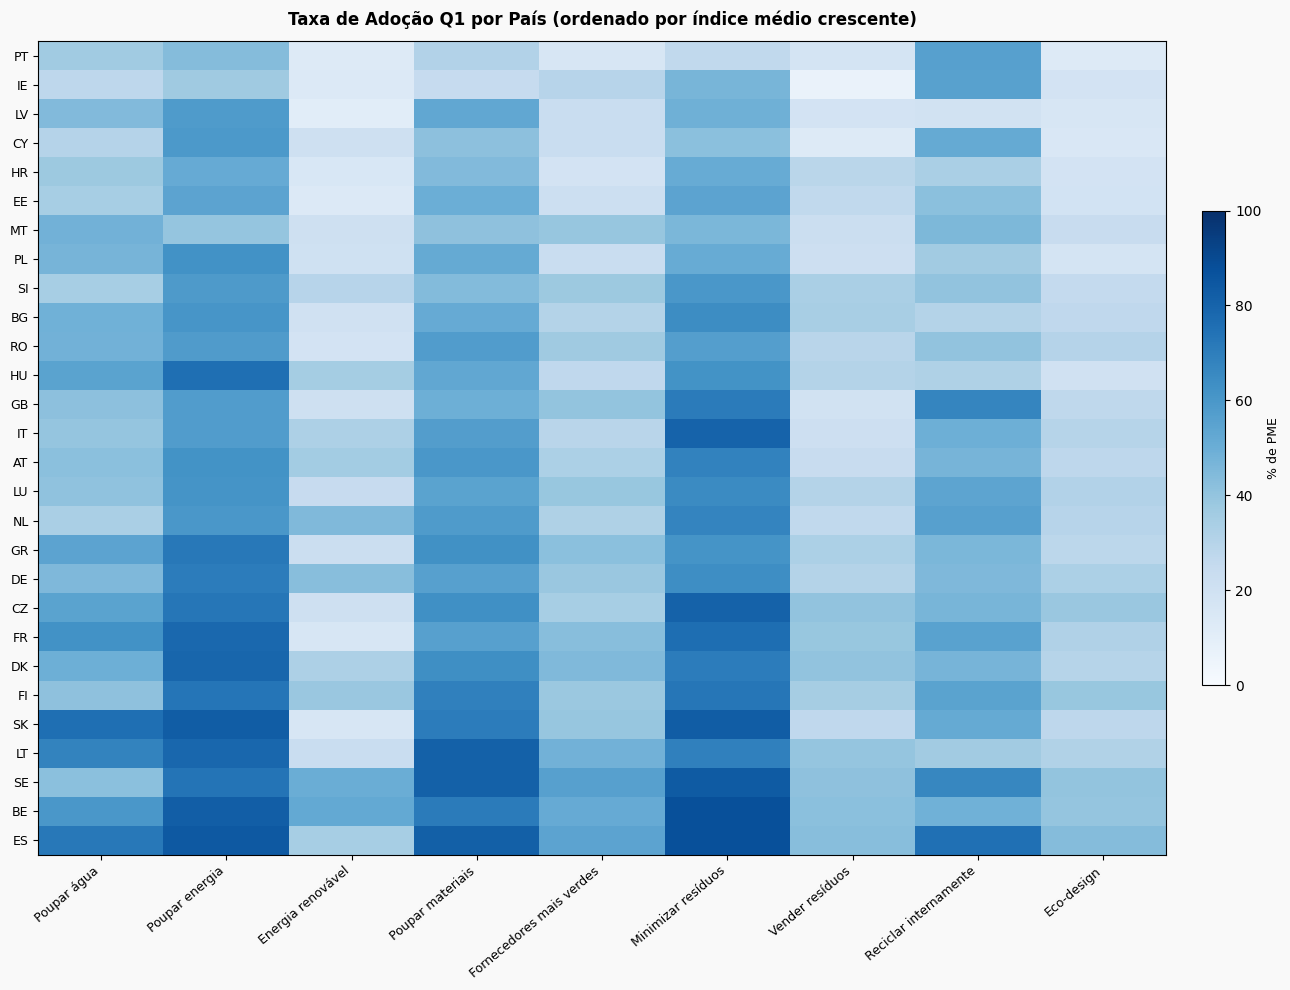

In [42]:
# Heatmap: taxa de adoção de cada prática Q1 por país
# Ordenado do país com menor para o de maior intensidade média

q1_cols_bin = [c+'_bin' for c in q1_map.keys()]
country_q1  = (df_key.groupby('isocntry')[q1_cols_bin].mean()*100).round(1)
country_q1.columns = list(q1_map.values())
country_order_c = df_key.groupby('isocntry')['intensity_index'].mean().sort_values().index
country_q1 = country_q1.reindex(country_order_c)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
im = ax.imshow(country_q1.values, cmap='Blues', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(9))
ax.set_xticklabels(list(q1_map.values()), rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(country_q1.index)))
ax.set_yticklabels(country_q1.index, fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.03).set_label('% de PME', fontsize=9)
ax.set_title('Taxa de Adoção Q1 por País (ordenado por índice médio crescente)',
             fontsize=12, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

## 2.6 Análise Bivariada — VD × Variáveis Independentes

> As relações bivariadas apresentadas aqui são análises descritivas não ajustadas. As relações controladas serão estimadas nos modelos de regressão.

### 2.6.1 VD × Setor de Atividade

=== VD × SETOR ===
        mean  median   std  count
nace_b                           
1.0     4.50     5.0  2.22   2736
2.0     4.03     4.0  2.23   2671
3.0     4.02     4.0  2.23   4016
4.0     3.71     4.0  2.23   4136


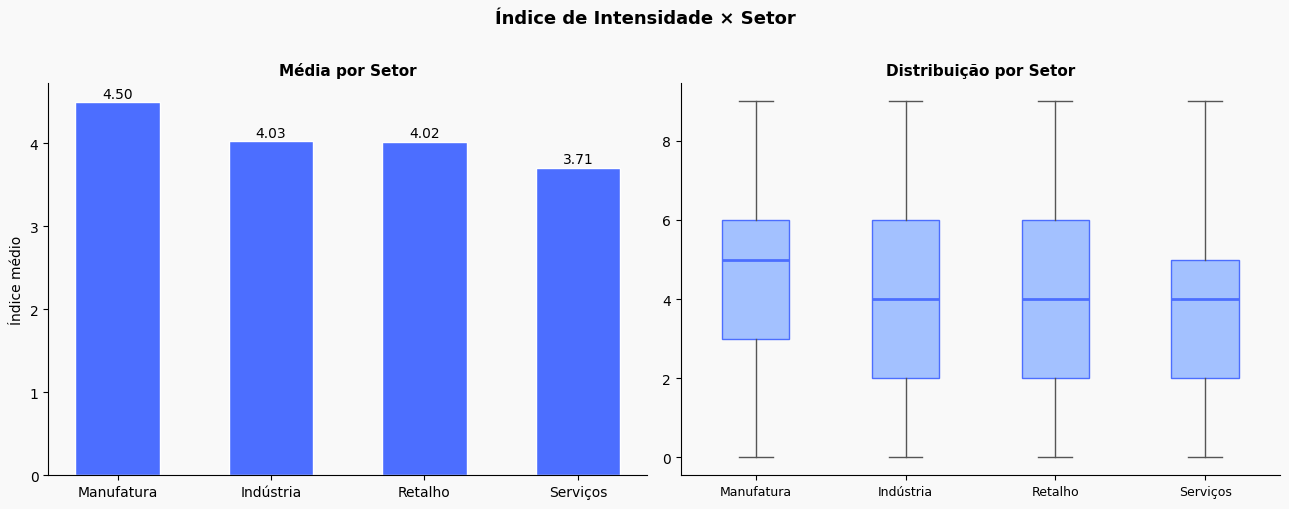

In [43]:
# VD × Setor — tabela e visualização

print("=== VD × SETOR ===")
print(df_key.groupby('nace_b')['intensity_index']
      .agg(['mean','median','std','count'])
      .round(2).sort_values('mean', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

means = df_key.groupby('nace_b')['intensity_index'].mean().reindex(sector_order)
axes[0].bar(sector_short, means.values, color=BLUE, edgecolor='white', width=0.55)
for i, val in enumerate(means.values):
    axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Setor', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_s = [df_key[df_key['nace_b']==s]['intensity_index'].dropna().values for s in sector_order]
axes[1].boxplot(data_s, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(sector_short, fontsize=9)
axes[1].set_title('Distribuição por Setor', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Setor', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.6.2 VD × Dimensão da Empresa

=== VD × DIMENSÃO ===
       mean  median   std  count
scr10                           
1.0    3.69     4.0  2.22   5941
2.0    4.13     4.0  2.24   4992
3.0    4.57     5.0  2.18   2626


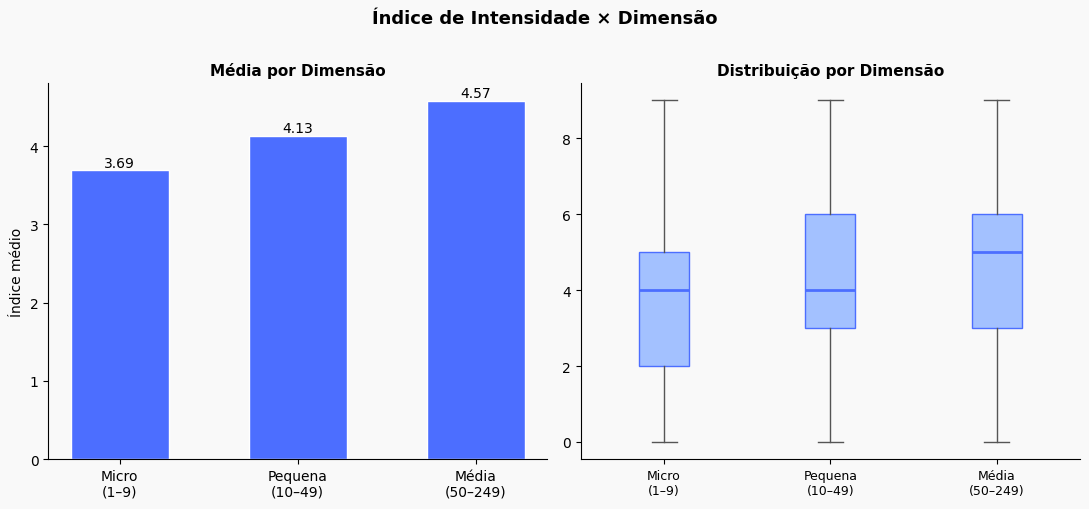

In [44]:
# VD × Dimensão — tabela e visualização

print("=== VD × DIMENSÃO ===")
print(df_key[df_key['scr10'].isin(size_order)]
      .groupby('scr10')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(size_order).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor=BG)

df_s    = df_key[df_key['scr10'].isin(size_order)]
means_s = df_s.groupby('scr10')['intensity_index'].mean().reindex(size_order)
axes[0].bar(size_short, means_s.values, color=BLUE, edgecolor='white', width=0.55)
for i, val in enumerate(means_s.values):
    axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Dimensão', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_sz = [df_s[df_s['scr10']==s]['intensity_index'].dropna().values for s in size_order]
axes[1].boxplot(data_sz, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(size_short, fontsize=9)
axes[1].set_title('Distribuição por Dimensão', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Dimensão', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.6.3 Cruzamento Setor × Dimensão

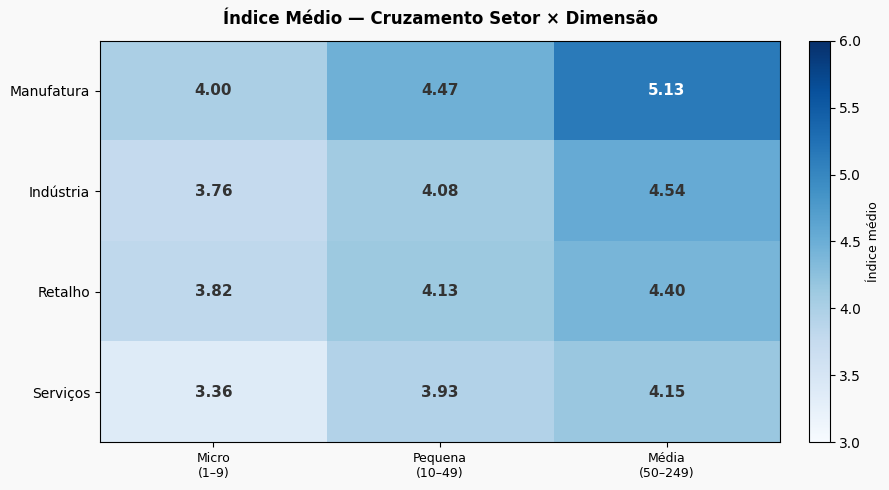

In [45]:
# Cruzamento Setor × Dimensão — heatmap do índice médio

df_cross = df_key[df_key['scr10'].isin(size_order)].copy()
pivot = df_cross.groupby(['nace_b','scr10'])['intensity_index'].mean().unstack()
pivot = pivot.reindex(index=sector_order, columns=size_order)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto', vmin=3, vmax=6)
ax.set_xticks(range(3)); ax.set_xticklabels(size_short, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(sector_short, fontsize=10)
for i in range(4):
    for j in range(3):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, color='white' if val > 5 else '#333', fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label('Índice médio', fontsize=9)
ax.set_title('Índice Médio — Cruzamento Setor × Dimensão',
             fontsize=12, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.6.4 VD × Antiguidade da Empresa (scr12)

=== VD × ANTIGUIDADE (scr12) ===
       mean  median   std  count
scr12                           
1.0    4.08     4.0  2.25  10791
2.0    3.84     4.0  2.22   1191
3.0    3.76     4.0  2.22   1229
4.0    3.90     4.0  1.97    278
5.0    2.96     3.0  1.92     70


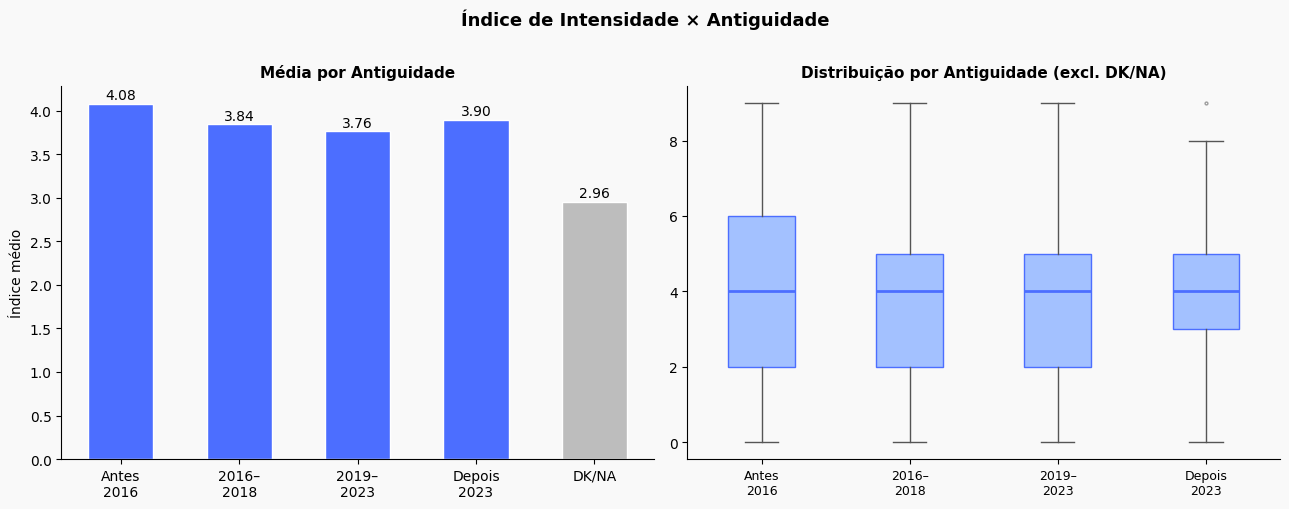

In [46]:
# VD × scr12 (antiguidade categórica)
# Códigos: 1=Antes 2016, 2=2016–2018, 3=2019–2023, 4=Depois 2023, 5=DK/NA

scr12_map = {
    1.0: 'Antes de 2016',
    2.0: '2016–2018',
    3.0: '2019–2023',
    4.0: 'Depois de 2023',
    5.0: 'DK/NA',
}
scr12_order = [1.0, 2.0, 3.0, 4.0, 5.0]
scr12_short = ['Antes\n2016', '2016–\n2018', '2019–\n2023', 'Depois\n2023', 'DK/NA']

print("=== VD × ANTIGUIDADE (scr12) ===")
print(df_key.groupby('scr12')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(scr12_order).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

means_a = df_key.groupby('scr12')['intensity_index'].mean().reindex(scr12_order)
colors_a = [BLUE, BLUE, BLUE, BLUE, '#BDBDBD']
axes[0].bar(scr12_short, means_a.values, color=colors_a, edgecolor='white', width=0.55)
for i, val in enumerate(means_a.values):
    if not np.isnan(val):
        axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Antiguidade', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_a = [df_key[df_key['scr12']==s]['intensity_index'].dropna().values for s in scr12_order[:4]]
axes[1].boxplot(data_a, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(scr12_short[:4], fontsize=9)
axes[1].set_title('Distribuição por Antiguidade (excl. DK/NA)', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Antiguidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 2.6.5 VD × Evolução do Volume de Negócios (scr13a)

=== VD × EVOLUÇÃO DO VOLUME DE NEGÓCIOS (scr13a) ===
        mean  median   std  count
scr13a                           
4.0     3.86     4.0  2.20   2751
3.0     3.97     4.0  2.21   4327
2.0     4.19     4.0  2.16   2272
1.0     4.14     4.0  2.36   3582

DK/NA (NaN): 627 empresas


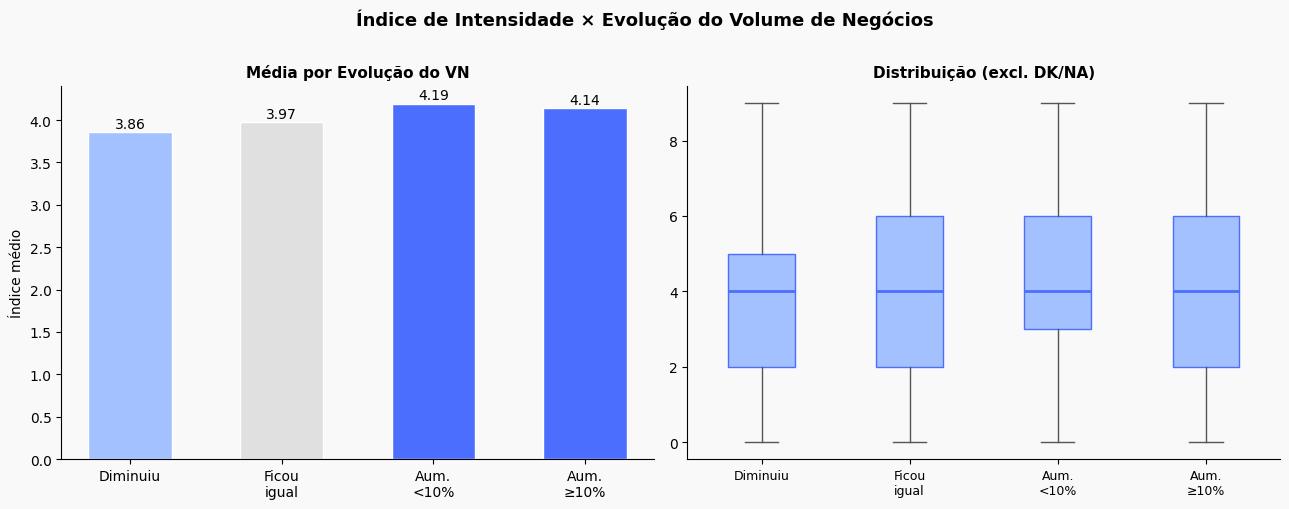

In [47]:
# VD × scr13a (evolução do volume de negócios nos últimos 3 anos)
# Códigos: 1=Aumentou ≥10%, 2=Aumentou <10%, 3=Ficou igual, 4=Diminuiu
# 998 (→ NaN após recoding) = DK/NA

scr13a_map = {
    1.0: 'Aumentou ≥10%',
    2.0: 'Aumentou <10%',
    3.0: 'Ficou igual',
    4.0: 'Diminuiu',
}
scr13a_order = [4.0, 3.0, 2.0, 1.0]
scr13a_short = ['Diminuiu', 'Ficou\nigual', 'Aum.\n<10%', 'Aum.\n≥10%']

print("=== VD × EVOLUÇÃO DO VOLUME DE NEGÓCIOS (scr13a) ===")
print(df_key.groupby('scr13a')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(scr13a_order).round(2))

# Incluir NaN como categoria visível
n_dkna = df_key['scr13a'].isna().sum()
print(f"\nDK/NA (NaN): {n_dkna:,} empresas")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

means_e = df_key.groupby('scr13a')['intensity_index'].mean().reindex(scr13a_order)
colors_e = [LIGHT_BLUE, '#E0E0E0', BLUE, BLUE]
axes[0].bar(scr13a_short, means_e.values, color=colors_e, edgecolor='white', width=0.55)
for i, val in enumerate(means_e.values):
    if not np.isnan(val):
        axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Evolução do VN', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_e = [df_key[df_key['scr13a']==s]['intensity_index'].dropna().values for s in scr13a_order]
axes[1].boxplot(data_e, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(scr13a_short, fontsize=9)
axes[1].set_title('Distribuição (excl. DK/NA)', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Evolução do Volume de Negócios', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.6.6 VD × Volume de Negócios (scr14)

=== VD × VOLUME DE NEGÓCIOS (scr14) ===
       mean  median   std  count
scr14                           
1.0    3.48     4.0  2.22    699
2.0    3.57     4.0  2.20    914
3.0    3.63     4.0  2.12   1010
4.0    3.76     4.0  2.09   1522
5.0    3.80     4.0  2.12   1397
6.0    4.01     4.0  2.21   2636
7.0    4.50     5.0  2.26   2197
8.0    4.95     5.0  2.24   1116
9.0    5.05     5.0  2.32    258
10.0   3.81     4.0  2.26   1810


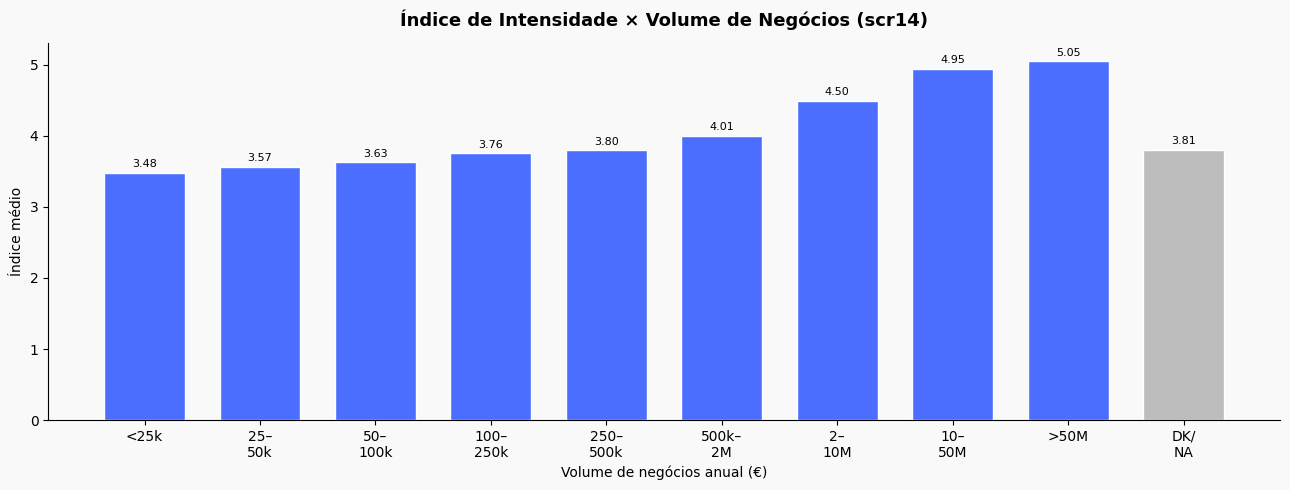

In [48]:
# VD × scr14 (volume de negócios anual — faixas)
# Códigos: 1=<25k€, 2=25-50k€, ..., 9=>50M€, 10=DK/NA

scr14_map_biv = {
    1.0: '<25k€', 2.0: '25–50k€', 3.0: '50–100k€',
    4.0: '100–250k€', 5.0: '250–500k€', 6.0: '500k–2M€',
    7.0: '2–10M€', 8.0: '10–50M€', 9.0: '>50M€', 10.0: 'DK/NA',
}
scr14_order = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
scr14_short = ['<25k','25–\n50k','50–\n100k','100–\n250k','250–\n500k',
               '500k–\n2M','2–\n10M','10–\n50M','>50M','DK/\nNA']

print("=== VD × VOLUME DE NEGÓCIOS (scr14) ===")
print(df_key.groupby('scr14')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(scr14_order).round(2))

fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)

means_t = df_key.groupby('scr14')['intensity_index'].mean().reindex(scr14_order)
colors_t = [BLUE]*9 + ['#BDBDBD']
bars = ax.bar(scr14_short, means_t.values, color=colors_t, edgecolor='white', width=0.7)
for bar, val in zip(bars, means_t.values):
    if not np.isnan(val):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Índice médio', fontsize=10)
ax.set_xlabel('Volume de negócios anual (€)', fontsize=10)
ax.set_title('Índice de Intensidade × Volume de Negócios (scr14)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


### 2.6.7 VD × Impacto nos Custos de Produção (Q3)

=== VD × Q3 — Impacto nos Custos de Produção ===
     mean   std  count
q3                    
1.0  4.63  2.15    567
2.0  4.63  2.04   3898
5.0  3.80  1.88   2781
3.0  4.54  2.02   2617
4.0  4.31  2.11   1461
6.0  3.99  1.87   1284


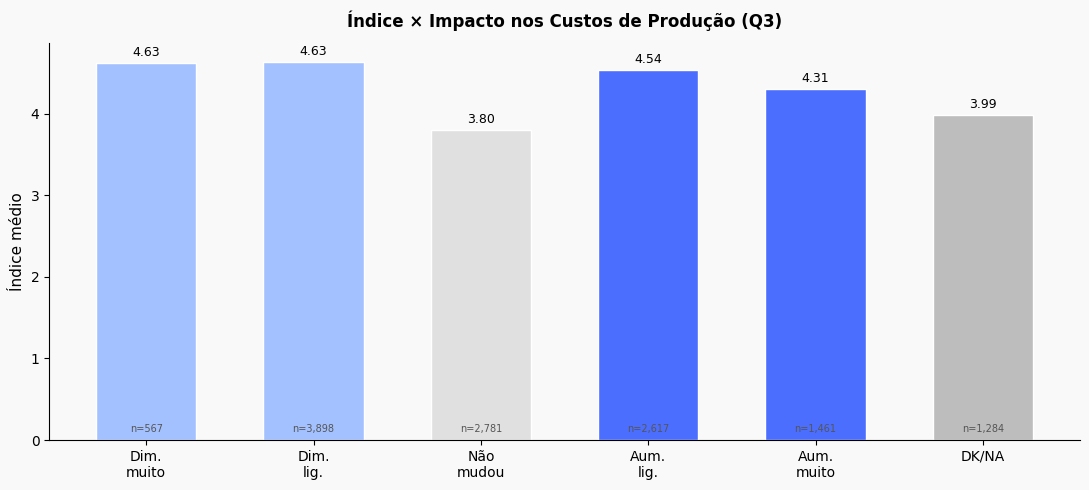

In [49]:
# VD × Q3 (impacto nos custos de produção das ações de eficiência)
# ⚠ ATENÇÃO: os códigos SPSS do Q3 NÃO são monotónicos!
#   1=Dim. muito, 2=Dim. lig., 3=Aum. lig., 4=Aum. muito, 5=Não mudou, 6=DK/NA
#   A ordem semântica correta é: 1 → 2 → 5 → 3 → 4  (diminuiu → estável → aumentou)
#   q3_code_order abaixo reordena para a escala lógica.

q3_code_order  = [1.0, 2.0, 5.0, 3.0, 4.0, 6.0]
q3_labels_biv  = ['Dim.\nmuito','Dim.\nlig.','Não\nmudou','Aum.\nlig.','Aum.\nmuito','DK/NA']

df_q3  = df_key[df_key['q3'].isin(q3_code_order)]
means  = df_q3.groupby('q3')['intensity_index'].mean().reindex(q3_code_order)
counts = df_q3.groupby('q3')['intensity_index'].count().reindex(q3_code_order)

print("=== VD × Q3 — Impacto nos Custos de Produção ===")
print(df_q3.groupby('q3')['intensity_index']
      .agg(['mean','std','count']).reindex(q3_code_order).round(2))

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
colors_q3 = [LIGHT_BLUE, LIGHT_BLUE, '#E0E0E0', BLUE, BLUE, '#BDBDBD']
bars = ax.bar(q3_labels_biv, means.values, color=colors_q3, edgecolor='white', width=0.6)
for bar, val, n in zip(bars, means.values, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar.get_x()+bar.get_width()/2, 0.1,
            f'n={n:,}', ha='center', fontsize=7, color='#555')
ax.set_ylabel('Índice médio', fontsize=11)
ax.set_title('Índice × Impacto nos Custos de Produção (Q3)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.6.8 VD × Investimento Ambiental (Q4)

=== VD × Q4 — Investimento Ambiental ===
     mean   std  count
q4                    
1.0  3.55  1.79   2682
2.0  4.21  1.88   2795
3.0  4.75  2.04   3785
4.0  4.92  2.16   1169
5.0  4.76  2.15    453
6.0  4.35  2.22    248
7.0  4.27  1.98   1476


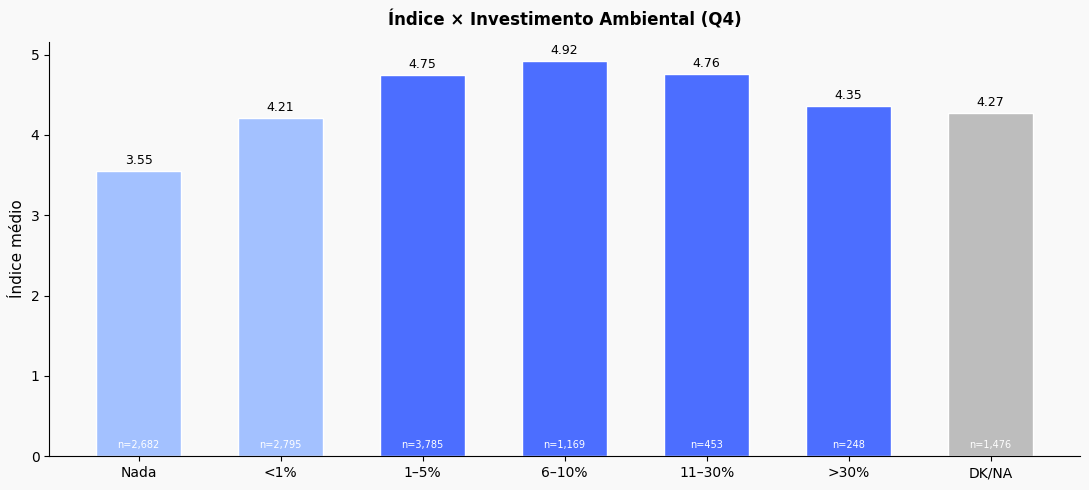

In [50]:
# VD × Q4 (% receita investida em ações ambientais)
# Códigos: 1=Nada, 2=<1%, 3=1-5%, 4=6-10%, 5=11-30%, 6=>30%, 7=DK/NA

q4_code_order  = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
q4_labels_biv  = ['Nada','<1%','1–5%','6–10%','11–30%','>30%','DK/NA']

df_q4  = df_key[df_key['q4'].isin(q4_code_order)]
means  = df_q4.groupby('q4')['intensity_index'].mean().reindex(q4_code_order)
counts = df_q4.groupby('q4')['intensity_index'].count().reindex(q4_code_order)

print("=== VD × Q4 — Investimento Ambiental ===")
print(df_q4.groupby('q4')['intensity_index']
      .agg(['mean','std','count']).reindex(q4_code_order).round(2))

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
colors_q4 = [LIGHT_BLUE,LIGHT_BLUE,BLUE,BLUE,BLUE,BLUE,'#BDBDBD']
bars = ax.bar(q4_labels_biv, means.values, color=colors_q4, edgecolor='white', width=0.6)
for bar, val, n in zip(bars, means.values, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar.get_x()+bar.get_width()/2, 0.1,
            f'n={n:,}', ha='center', fontsize=7, color='white')
ax.set_ylabel('Índice médio', fontsize=11)
ax.set_title('Índice × Investimento Ambiental (Q4)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.6.9 VD × Barreiras à Eficiência (Q7)

=== VD × BARREIRAS Q7 ===
                             Barreira  Mencionou  Não mencionou  Diferença  N mencionou
      Requisitos complexos de reporte       5.15           4.04       1.11         3261
  Complexidade de rotulagem ambiental       5.17           4.11       1.06         2606
           Custo das ações ambientais       5.04           4.03       1.02         3689
   Requisitos técnicos desatualizados       5.10           4.14       0.96         2467
            Complexidade admin./legal       4.92           4.02       0.90         4332
         Falta de expertise ambiental       4.98           4.14       0.84         2828
    Dificuldade em adaptar legislação       4.97           4.14       0.83         2858
   Falta de oferta de materiais/peças       4.96           4.16       0.81         2626
        Dificuldade em escolher ações       4.94           4.16       0.77         2655
Falta de procura por prod. eficientes       4.95           4.18       0.77         2366
      

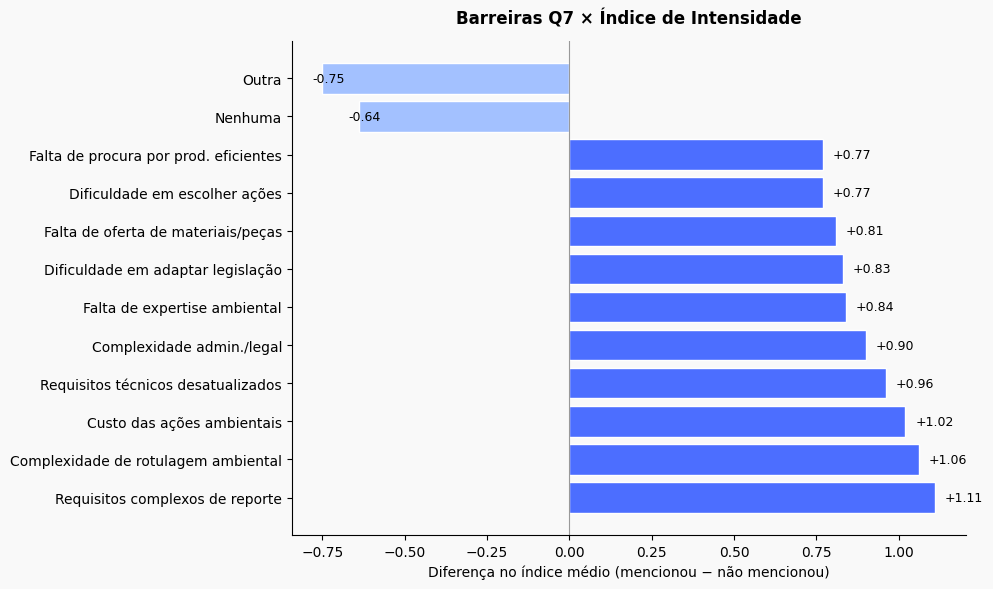

In [51]:
# VD × Barreiras Q7 — diferença no índice médio
# Q7.x: 0.0 = não mencionada, 1.0 = mencionada
# Empresas que mencionam barreiras tendem a ter índice mais alto ou mais baixo?

results = []
for col, label in q7_map.items():
    mentioned     = df_key[df_key[col] == 1.0]['intensity_index']
    not_mentioned = df_key[df_key[col] == 0.0]['intensity_index']
    results.append({
        'Barreira': label,
        'Mencionou': round(mentioned.mean(), 2),
        'Não mencionou': round(not_mentioned.mean(), 2),
        'Diferença': round(mentioned.mean() - not_mentioned.mean(), 2),
        'N mencionou': len(mentioned),
    })

q7_df = pd.DataFrame(results).sort_values('Diferença', ascending=False)
print("=== VD × BARREIRAS Q7 ===")
print(q7_df.to_string(index=False))

labels_q7 = q7_df['Barreira'].tolist()
diffs     = q7_df['Diferença'].tolist()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
colors_q7 = [BLUE if d > 0 else LIGHT_BLUE for d in diffs]
ax.barh(labels_q7, diffs, color=colors_q7, edgecolor='white')
ax.axvline(0, color='#999', linewidth=0.8)
for i, val in enumerate(diffs):
    ax.text(val+(0.03 if val>=0 else -0.03), i,
            f'{val:+.2f}', va='center', fontsize=9)
ax.set_xlabel('Diferença no índice médio (mencionou − não mencionou)', fontsize=10)
ax.set_title('Barreiras Q7 × Índice de Intensidade',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

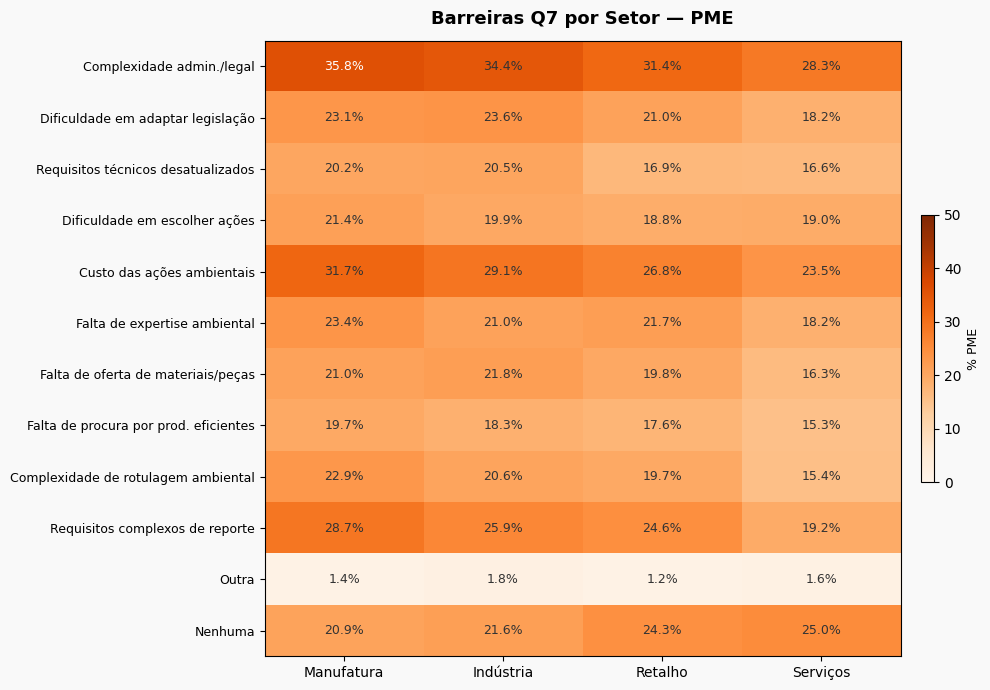

In [52]:
# Cruzamento barreiras × setor — quais setores sentem mais cada barreira
# Q7.x: 1.0 = mencionada

barrier_sector = {}
for col, label in q7_map.items():
    barrier_sector[label] = (
        df_key.groupby('nace_b')[col]
        .apply(lambda s: (s == 1.0).mean() * 100)
        .reindex(sector_order)
    )

bs_df = pd.DataFrame(barrier_sector).T
bs_df.columns = sector_short

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
im = ax.imshow(bs_df.values, cmap='Oranges', aspect='auto', vmin=0, vmax=50)
ax.set_xticks(range(4)); ax.set_xticklabels(sector_short, fontsize=10)
ax.set_yticks(range(len(bs_df.index))); ax.set_yticklabels(bs_df.index, fontsize=9)
for i in range(len(bs_df.index)):
    for j in range(4):
        val = bs_df.values[i,j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white' if val > 35 else '#333')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.03).set_label('% PME', fontsize=9)
ax.set_title('Barreiras Q7 por Setor — PME', fontsize=13, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.6.10 Testes Estatísticos e Tamanho do Efeito

> Complementa as análises visuais das subsecções anteriores com testes formais de significância e medidas de efeito. Utilizam-se testes não paramétricos dado que o índice é uma contagem discreta (0–9).

In [53]:
# ── Testes estatísticos formais + tamanho do efeito ──────────────────────────
# Todos os testes são não-paramétricos (índice é contagem discreta 0–9)

from scipy.stats import kruskal, mannwhitneyu, spearmanr

results_tests = []

# ── 1. Kruskal-Wallis: Setor (nace_b) ───────────────────────────────────────
groups_sector = [df_key[df_key['nace_b']==s]['intensity_index'].dropna() for s in sector_order]
H_sec, p_sec = kruskal(*groups_sector)
N_sec = sum(len(g) for g in groups_sector)
k_sec = len(groups_sector)
eta2_sec = (H_sec - k_sec + 1) / (N_sec - k_sec)
results_tests.append({
    'Variável': 'Setor (nace_b)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_sec:.1f}',
    'p-valor': f'{p_sec:.2e}' if p_sec < 0.001 else f'{p_sec:.4f}',
    'Efeito': f'η² = {eta2_sec:.4f}',
    'Interpretação': 'pequeno' if eta2_sec < 0.06 else ('médio' if eta2_sec < 0.14 else 'grande'),
})

# ── 2. Kruskal-Wallis: Dimensão (scr10) ─────────────────────────────────────
groups_size = [df_key[df_key['scr10']==s]['intensity_index'].dropna() for s in size_order]
H_sz, p_sz = kruskal(*groups_size)
N_sz = sum(len(g) for g in groups_size)
k_sz = len(groups_size)
eta2_sz = (H_sz - k_sz + 1) / (N_sz - k_sz)
results_tests.append({
    'Variável': 'Dimensão (scr10)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_sz:.1f}',
    'p-valor': f'{p_sz:.2e}' if p_sz < 0.001 else f'{p_sz:.4f}',
    'Efeito': f'η² = {eta2_sz:.4f}',
    'Interpretação': 'pequeno' if eta2_sz < 0.06 else ('médio' if eta2_sz < 0.14 else 'grande'),
})

# ── 3. Kruskal-Wallis: Antiguidade (scr12, excl. DK/NA=5.0) ─────────────────
scr12_valid = [1.0, 2.0, 3.0, 4.0]
groups_age = [df_key[df_key['scr12']==s]['intensity_index'].dropna() for s in scr12_valid]
H_age, p_age = kruskal(*groups_age)
N_age = sum(len(g) for g in groups_age)
k_age = len(groups_age)
eta2_age = (H_age - k_age + 1) / (N_age - k_age)
results_tests.append({
    'Variável': 'Antiguidade (scr12)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_age:.1f}',
    'p-valor': f'{p_age:.2e}' if p_age < 0.001 else f'{p_age:.4f}',
    'Efeito': f'η² = {eta2_age:.4f}',
    'Interpretação': 'pequeno' if eta2_age < 0.06 else ('médio' if eta2_age < 0.14 else 'grande'),
})

# ── 4. Kruskal-Wallis: Evolução VN (scr13a, excl. NaN=DK/NA) ────────────────
scr13a_valid = [1.0, 2.0, 3.0, 4.0]
groups_emp = [df_key[df_key['scr13a']==s]['intensity_index'].dropna() for s in scr13a_valid]
H_emp, p_emp = kruskal(*groups_emp)
N_emp = sum(len(g) for g in groups_emp)
k_emp = len(groups_emp)
eta2_emp = (H_emp - k_emp + 1) / (N_emp - k_emp)
results_tests.append({
    'Variável': 'Evol. VN (scr13a)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_emp:.1f}',
    'p-valor': f'{p_emp:.2e}' if p_emp < 0.001 else f'{p_emp:.4f}',
    'Efeito': f'η² = {eta2_emp:.4f}',
    'Interpretação': 'pequeno' if eta2_emp < 0.06 else ('médio' if eta2_emp < 0.14 else 'grande'),
})

# ── 5. Spearman: Q3 (ordinal, excluindo DK/NA código 6.0) ────────────────────
q3_ordinal_map = {1.0: 1, 2.0: 2, 5.0: 3, 3.0: 4, 4.0: 5}
df_q3_test = df_key[df_key['q3'].isin([1.0,2.0,3.0,4.0,5.0])].copy()
df_q3_test['q3_ord'] = df_q3_test['q3'].map(q3_ordinal_map)
rho_q3, p_q3 = spearmanr(df_q3_test['q3_ord'], df_q3_test['intensity_index'])
results_tests.append({
    'Variável': 'Q3 — Custos produção (ordinal)',
    'Teste': 'Spearman ρ',
    'Estatística': f'ρ = {rho_q3:.3f}',
    'p-valor': f'{p_q3:.2e}' if p_q3 < 0.001 else f'{p_q3:.4f}',
    'Efeito': f'|ρ| = {abs(rho_q3):.3f}',
    'Interpretação': 'fraco' if abs(rho_q3) < 0.3 else ('moderado' if abs(rho_q3) < 0.5 else 'forte'),
})

# ── 6. Spearman: Q4 (ordinal, excluindo DK/NA código 7.0) ────────────────────
df_q4_test = df_key[df_key['q4'].isin([1.0,2.0,3.0,4.0,5.0,6.0])].copy()
rho_q4, p_q4 = spearmanr(df_q4_test['q4'], df_q4_test['intensity_index'])
results_tests.append({
    'Variável': 'Q4 — Invest. ambiental (ordinal)',
    'Teste': 'Spearman ρ',
    'Estatística': f'ρ = {rho_q4:.3f}',
    'p-valor': f'{p_q4:.2e}' if p_q4 < 0.001 else f'{p_q4:.4f}',
    'Efeito': f'|ρ| = {abs(rho_q4):.3f}',
    'Interpretação': 'fraco' if abs(rho_q4) < 0.3 else ('moderado' if abs(rho_q4) < 0.5 else 'forte'),
})

# ── 7. Spearman: scr14 (ordinal, excluindo DK/NA código 10.0) ────────────────
df_s14_test = df_key[df_key['scr14'].isin([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0])].copy()
rho_s14, p_s14 = spearmanr(df_s14_test['scr14'], df_s14_test['intensity_index'])
results_tests.append({
    'Variável': 'Vol. negócios (scr14, ordinal)',
    'Teste': 'Spearman ρ',
    'Estatística': f'ρ = {rho_s14:.3f}',
    'p-valor': f'{p_s14:.2e}' if p_s14 < 0.001 else f'{p_s14:.4f}',
    'Efeito': f'|ρ| = {abs(rho_s14):.3f}',
    'Interpretação': 'fraco' if abs(rho_s14) < 0.3 else ('moderado' if abs(rho_s14) < 0.5 else 'forte'),
})

# ── Tabela resumo ────────────────────────────────────────────────────────────
print("=== TESTES BIVARIADOS — VD × VARIÁVEIS INDEPENDENTES ===\n")
print(pd.DataFrame(results_tests).to_string(index=False))

# ── 8. Mann-Whitney U: cada barreira Q7 ─────────────────────────────────────
print("\n\n=== MANN-WHITNEY U — BARREIRAS Q7 × ÍNDICE ===")
print(f"{'Barreira':<35} {'U':>12} {'p-valor':>12} {'r (rank-bis.)':>14} {'Efeito':>10}")
print(f"{'─'*85}")

for col, label in q7_map.items():
    g1 = df_key[df_key[col] == 1.0]['intensity_index'].dropna()
    g0 = df_key[df_key[col] == 0.0]['intensity_index'].dropna()
    if len(g1) > 0 and len(g0) > 0:
        U, p = mannwhitneyu(g1, g0, alternative='two-sided')
        n1, n2 = len(g1), len(g0)
        r_rb = 1 - (2*U) / (n1 * n2)
        eff = 'pequeno' if abs(r_rb) < 0.3 else ('médio' if abs(r_rb) < 0.5 else 'grande')
        p_str = f'{p:.2e}' if p < 0.001 else f'{p:.4f}'
        print(f"{label:<35} {U:>12,.0f} {p_str:>12} {r_rb:>+14.3f} {eff:>10}")

print("\nNotas:")
print("  η² < 0.06 = pequeno, 0.06–0.14 = médio, > 0.14 = grande (Cohen 1988)")
print("  |ρ| < 0.3 = fraco, 0.3–0.5 = moderado, > 0.5 = forte")
print("  |r| rank-biserial: mesmos limiares que ρ")


=== TESTES BIVARIADOS — VD × VARIÁVEIS INDEPENDENTES ===

                        Variável            Teste Estatística   p-valor      Efeito Interpretação
                  Setor (nace_b) Kruskal-Wallis H   H = 196.0  3.06e-42 η² = 0.0142       pequeno
                Dimensão (scr10) Kruskal-Wallis H   H = 273.4  4.31e-60 η² = 0.0200       pequeno
             Antiguidade (scr12) Kruskal-Wallis H    H = 29.4  1.87e-06 η² = 0.0020       pequeno
               Evol. VN (scr13a) Kruskal-Wallis H    H = 37.4  3.84e-08 η² = 0.0027       pequeno
  Q3 — Custos produção (ordinal)       Spearman ρ  ρ = -0.047  4.29e-07 |ρ| = 0.047         fraco
Q4 — Invest. ambiental (ordinal)       Spearman ρ   ρ = 0.223 9.38e-126 |ρ| = 0.223         fraco
  Vol. negócios (scr14, ordinal)       Spearman ρ   ρ = 0.191  1.95e-97 |ρ| = 0.191         fraco


=== MANN-WHITNEY U — BARREIRAS Q7 × ÍNDICE ===
Barreira                                       U      p-valor  r (rank-bis.)     Efeito
─────────────────────

## 2.7 Análise Descritiva das Variáveis Independentes

### 2.7.1 Q3 e Q4

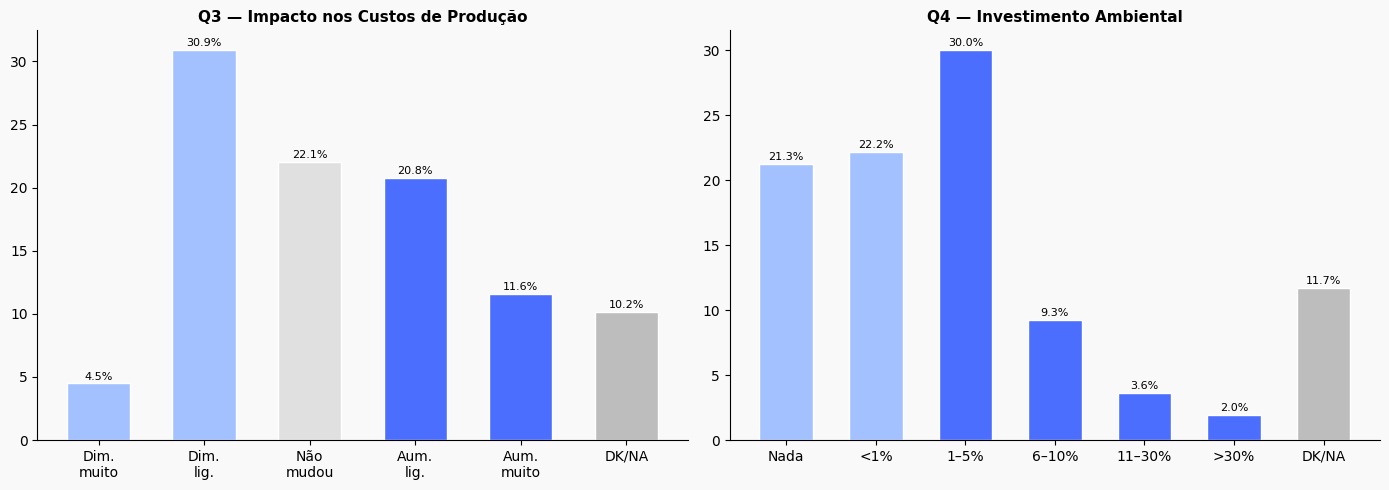

In [54]:
# Distribuição de Q3 e Q4 — incluindo DK/NA como categoria visível
# Q3 códigos: 1=Dim. muito, 2=Dim. lig., 5=Não mudou, 3=Aum. lig., 4=Aum. muito, 6=DK/NA
# Q4 códigos: 1=Nada, 2=<1%, 3=1-5%, 4=6-10%, 5=11-30%, 6=>30%, 7=DK/NA

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

q3c = df_key['q3'].value_counts(normalize=True).reindex(q3_code_order, fill_value=0)*100
axes[0].bar(q3_labels_biv, q3c.values,
            color=[LIGHT_BLUE,LIGHT_BLUE,'#E0E0E0',BLUE,BLUE,'#BDBDBD'],
            edgecolor='white', width=0.6)
for bar, val in zip(axes[0].patches, q3c.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)
axes[0].set_title('Q3 — Impacto nos Custos de Produção', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG); axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

q4c = df_key['q4'].value_counts(normalize=True).reindex(q4_code_order, fill_value=0)*100
axes[1].bar(q4_labels_biv, q4c.values,
            color=[LIGHT_BLUE,LIGHT_BLUE,BLUE,BLUE,BLUE,BLUE,'#BDBDBD'],
            edgecolor='white', width=0.6)
for bar, val in zip(axes[1].patches, q4c.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)
axes[1].set_title('Q4 — Investimento Ambiental', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.7.2 Barreiras Q7

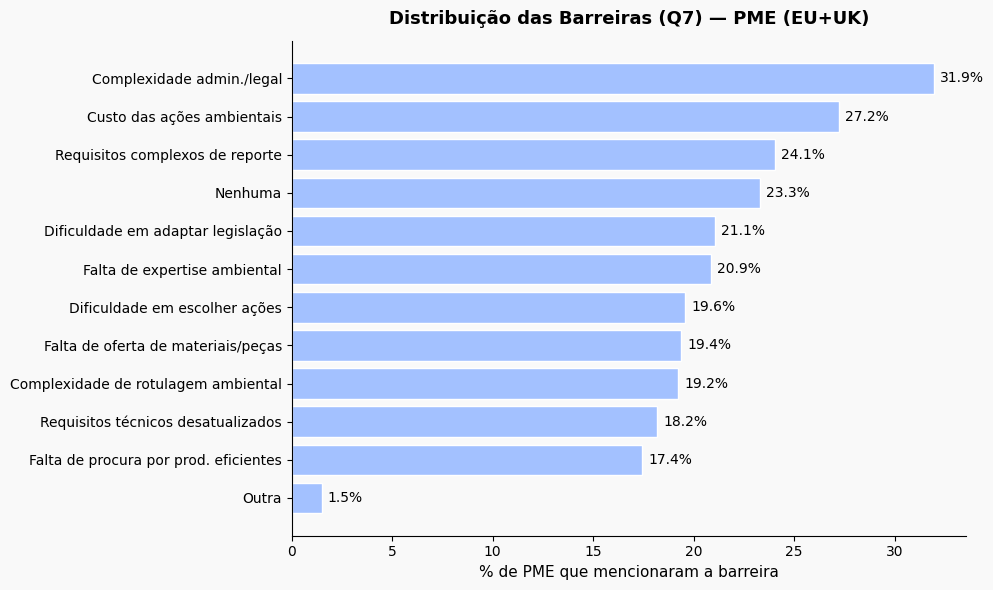

In [55]:
# Distribuição das barreiras Q7 — taxa de menção geral
# Q7.x: 1.0 = mencionada

eu_q7 = {
    label: (df_key[col] == 1.0).mean() * 100
    for col, label in q7_map.items()
}
sorted_q7 = sorted(eu_q7.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bars = ax.barh([i[0] for i in sorted_q7], [i[1] for i in sorted_q7],
               color=LIGHT_BLUE, edgecolor='white')
for bar, val in zip(bars, [i[1] for i in sorted_q7]):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de PME que mencionaram a barreira', fontsize=11)
ax.set_title('Distribuição das Barreiras (Q7) — PME (EU+UK)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.7.3 Apoios à eficiência Q8 — apenas descritiva

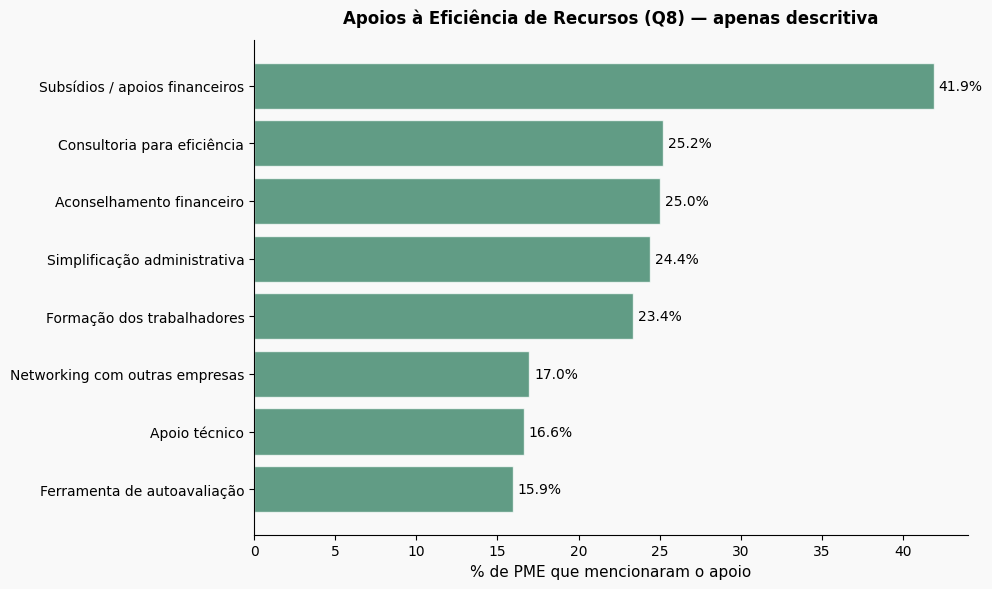

In [56]:
# Apoios à eficiência (Q8) — apenas para análise descritiva
# Estas variáveis NÃO entram no modelo por questões de causalidade inversa
# Q8.x: 0.0 = não mencionado, 1.0 = mencionado

q8_map = {
    'q8.1':  'Ferramenta de autoavaliação',
    'q8.2':  'Consultoria para eficiência',
    'q8.3':  'Subsídios / apoios financeiros',
    'q8.4':  'Aconselhamento financeiro',
    'q8.5':  'Formação dos trabalhadores',
    'q8.6':  'Apoio técnico',
    'q8.7':  'Simplificação administrativa',
    'q8.8':  'Networking com outras empresas',
}

eu_q8 = {
    label: (df[col] == 1.0).mean() * 100
    for col, label in q8_map.items()
    if col in df.columns
}
sorted_q8 = sorted(eu_q8.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bars = ax.barh([i[0] for i in sorted_q8], [i[1] for i in sorted_q8],
               color=GREEN, alpha=0.75, edgecolor='white')
for bar, val in zip(bars, [i[1] for i in sorted_q8]):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de PME que mencionaram o apoio', fontsize=11)
ax.set_title('Apoios à Eficiência de Recursos (Q8) — apenas descritiva',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2.8 Análise de Colinearidade

> A colinearidade é analisada aqui para informar as decisões de construção do índice e do modelo.

### 2.8.1 Correlação entre práticas Q1 — valida construção do índice

=== MATRIZ DE CORRELAÇÃO (Phi) — Práticas Q1 ===
                          Poupar água  Poupar energia  Energia renovável  \
Poupar água                     1.000           0.333              0.095   
Poupar energia                  0.333           1.000              0.168   
Energia renovável               0.095           0.168              1.000   
Poupar materiais                0.298           0.303              0.115   
Fornecedores mais verdes        0.200           0.189              0.154   
Minimizar resíduos              0.303           0.306              0.143   
Vender resíduos                 0.113           0.138              0.108   
Reciclar internamente           0.135           0.117              0.092   
Eco-design                      0.138           0.158              0.109   

                          Poupar materiais  Fornecedores mais verdes  \
Poupar água                          0.298                     0.200   
Poupar energia                       0.303    

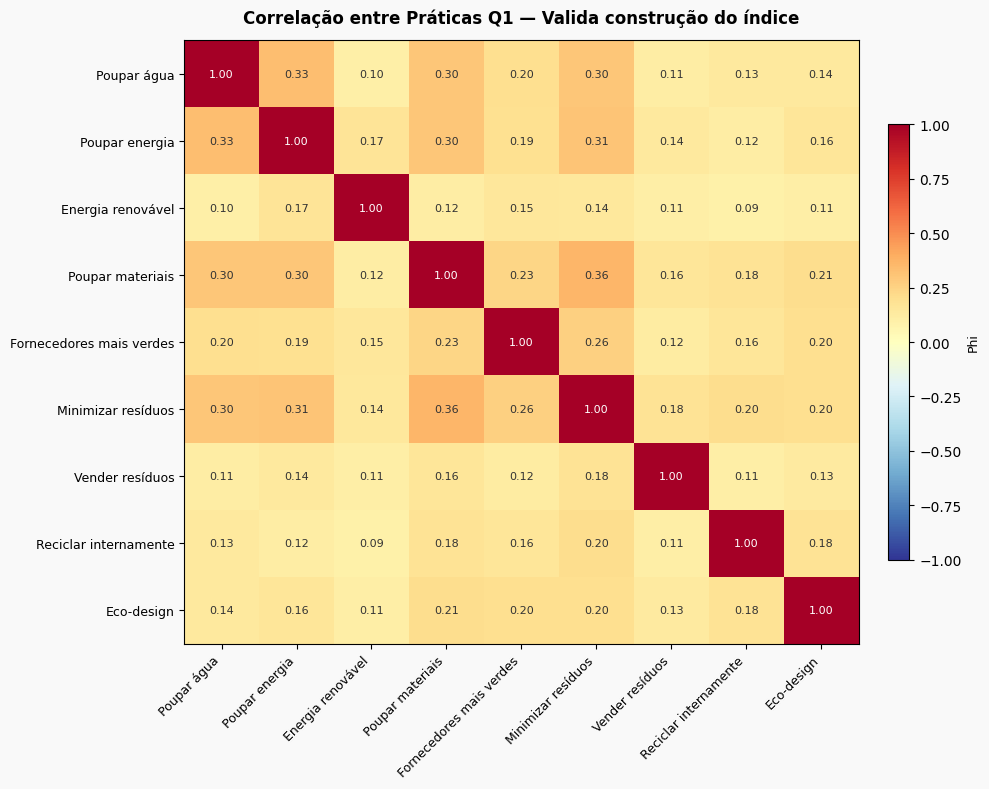

In [57]:
# Correlação entre as práticas Q1 — valida a construção do índice
# Para variáveis binárias, o coeficiente de Pearson equivale ao coeficiente Phi

bin_cols_q1 = [c+'_bin' for c in q1_map.keys()]
labels_q1   = list(q1_map.values())
corr_m      = df_key[bin_cols_q1].rename(
    columns=dict(zip(bin_cols_q1, labels_q1))
).corr()

print("=== MATRIZ DE CORRELAÇÃO (Phi) — Práticas Q1 ===")
print(corr_m.round(3))

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
im = ax.imshow(corr_m.values, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(9)); ax.set_xticklabels(labels_q1, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(9)); ax.set_yticklabels(labels_q1, fontsize=9)
for i in range(9):
    for j in range(9):
        val = corr_m.values[i,j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(val) > 0.6 else '#333')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label('Phi', fontsize=9)
ax.set_title('Correlação entre Práticas Q1 — Valida construção do índice',
             fontsize=12, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.8.2 VIF — Práticas Q1

In [58]:
# VIF das práticas Q1 — complementa a análise de correlação
# VIF < 5: sem colinearidade problemática → o índice é válido

from statsmodels.stats.outliers_influence import variance_inflation_factor

bin_cols_q1 = [c+'_bin' for c in q1_map.keys()]
labels_q1   = list(q1_map.values())
df_vif      = df_key[bin_cols_q1].dropna()

vif_data = pd.DataFrame({
    'Variável': labels_q1,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(9)]
}).sort_values('VIF', ascending=False)

print("=== VIF — Práticas Q1 ===")
print(vif_data.round(3).to_string(index=False))
print(f"\nVIF máximo: {vif_data['VIF'].max():.3f}")
print(f"Todos < 5:  {(vif_data['VIF'] < 5).all()} → índice válido")

=== VIF — Práticas Q1 ===
                Variável   VIF
      Minimizar resíduos 3.469
          Poupar energia 3.182
        Poupar materiais 2.920
             Poupar água 2.327
   Reciclar internamente 1.950
Fornecedores mais verdes 1.785
              Eco-design 1.539
         Vender resíduos 1.494
       Energia renovável 1.434

VIF máximo: 3.469
Todos < 5:  True → índice válido


---
# Secção 3 — Tratamento e Construção das Variáveis

> As decisões de tratamento são fundamentadas pela AED da Secção 2. Cada transformação é aplicada no `df_model`, deixando o `df_key` intacto para referência.
>
> **Decisão-chave:** As 951 empresas com Q1=0 (lógica de salto) são **mantidas** no dataset. Eliminá-las enviesaria o modelo para cima e perderia informação válida sobre não-adoção.

## 3.1 Criação do df_model e Tratamento de NAs

In [59]:
# ── Criação do df_model ─────────────────────────────────────────────────────
# Parte de df_key (todas as empresas) — NÃO faz listwise deletion

df_model = df_key.copy()
n_total = len(df_model)

# ── Lógica de salto (Q1=0): Q3/Q4/Q7 não foram perguntados ──────────────────
mask_skip = df_model['q3'].isnull()
n_skip = mask_skip.sum()

# Q7: preencher NaN com 0 (não enfrentaram barreiras — não tentaram)
q7_cols = list(q7_map.keys())
for col in q7_cols:
    df_model.loc[mask_skip, col] = 0.0

# Q3: preencher NaN com 5.0 (= 'Não mudou' — categoria de referência)
# → estas empresas ficam no grupo de referência e não influenciam coeficientes Q3
df_model.loc[mask_skip, 'q3'] = 5.0

# Q4: preencher NaN com 1.0 (= 'Nada' — categoria de referência)
# → mesma lógica: ficam no grupo de referência
df_model.loc[mask_skip, 'q4'] = 1.0

# ── DK/NA específicos → mantidos como categorias (dummies em 3.5) ────────────
# scr14: 10.0 = DK/NA → dummy indicadora
df_model['turnover_unknown'] = (df_model['scr14'] == 10.0).astype(int)
# scr12: 5.0 = DK/NA, scr13a: 4.0 = DK/NA, Q3: 6.0, Q4: 7.0 → mantidos

# ── Adicionar scr11b do df completo ─────────────────────────────────────────
df_model['scr11b'] = df.loc[df_model.index, 'scr11b']

print(f"df_model: {n_total:,} empresas × {df_model.shape[1]} colunas")
print(f"  Empresas mantidas: {n_total:,} (100% — sem listwise deletion)")
print(f"  Lógica de salto (Q1=0): {n_skip:,} ({n_skip/n_total*100:.1f}%)")
print(f"    → Q7 = 0, Q3 = 5.0 (ref), Q4 = 1.0 (ref)")
print(f"\n  DK/NA mantidos como categorias:")
print(f"    scr14 = 10.0:  {(df_model['scr14']==10.0).sum():,} → turnover_unknown=1")
print(f"    scr12 = 5.0:   {(df_model['scr12']==5.0).sum():,}")
print(f"    scr13a = 4.0:  {(df_model['scr13a']==4.0).sum():,}")
print(f"    Q3 = 6.0:      {(df_model['q3']==6.0).sum():,}")
print(f"    Q4 = 7.0:      {(df_model['q4']==7.0).sum():,}")

# Verificar NAs restantes
na_check = df_model.isnull().sum()
na_check = na_check[na_check > 0]
print(f"\nNAs restantes no df_model: {len(na_check)} variáveis")
if len(na_check) > 0:
    for col, n in na_check.items():
        print(f"    {col}: {n:,} ({n/n_total*100:.1f}%)")


df_model: 13,559 empresas × 44 colunas
  Empresas mantidas: 13,559 (100% — sem listwise deletion)
  Lógica de salto (Q1=0): 951 (7.0%)
    → Q7 = 0, Q3 = 5.0 (ref), Q4 = 1.0 (ref)

  DK/NA mantidos como categorias:
    scr14 = 10.0:  1,810 → turnover_unknown=1
    scr12 = 5.0:   70
    scr13a = 4.0:  2,751
    Q3 = 6.0:      1,284
    Q4 = 7.0:      1,476

NAs restantes no df_model: 3 variáveis
    scr11a: 99 (0.7%)
    scr13a: 627 (4.6%)
    scr11b: 135 (1.0%)


## 3.2 Tratamento de Outliers

In [60]:
# Tratamento de outliers — as decisões foram fundamentadas na Secção 2.3
#
# scr12a (ano de fundação): EXCLUÍDA — valores impossíveis (< 1900)
#   → Substituída por scr12 (categórica, já no df_model)
#
# scr10a (nº exato de FTE): NÃO INCLUÍDA
#   → Usamos scr10 categórica (micro / pequena / média)
#
# intensity_index: SEM outliers (escala construída 0–9)

print("=== TRATAMENTO DE OUTLIERS ===")
print("scr12a:          EXCLUÍDA (anos impossíveis) → usar scr12 categórica")
print("scr10a:          NÃO INCLUÍDA → usar scr10 categórica")
print("intensity_index: SEM outliers (escala 0–9 por construção)")
print("\n→ Nenhuma transformação necessária neste passo.")


=== TRATAMENTO DE OUTLIERS ===
scr12a:          EXCLUÍDA (anos impossíveis) → usar scr12 categórica
scr10a:          NÃO INCLUÍDA → usar scr10 categórica
intensity_index: SEM outliers (escala 0–9 por construção)

→ Nenhuma transformação necessária neste passo.


## 3.3 Verificação do Índice de Intensidade

> As colunas `q1.x_bin` e `intensity_index` foram construídas na Secção 2.4 e herdadas pelo `df_model`. Aqui verifica-se a sua integridade.

In [61]:
# Verificação do índice de intensidade (construído na Secção 2)
q1_cols = list(q1_map.keys())
bin_cols = [c+'_bin' for c in q1_cols]

# Verificar integridade: soma dos binários == intensity_index
check = (df_model[bin_cols].sum(axis=1) == df_model['intensity_index']).all()

print("=== ÍNDICE DE INTENSIDADE — df_model ===")
print(f"Colunas binárias: {len(bin_cols)}")
print(f"Verificação soma == índice: {'✓ OK' if check else '✗ FALHOU'}")
print(f"\nDistribuição:")
print(df_model['intensity_index'].value_counts().sort_index())
print(f"\nMédia:   {df_model['intensity_index'].mean():.2f}")
print(f"Mediana: {df_model['intensity_index'].median():.0f}")
print(f"Std:     {df_model['intensity_index'].std():.2f}")


=== ÍNDICE DE INTENSIDADE — df_model ===
Colunas binárias: 9
Verificação soma == índice: ✓ OK

Distribuição:
intensity_index
0     951
1    1183
2    1449
3    1963
4    2234
5    2094
6    1660
7    1202
8     613
9     210
Name: count, dtype: int64

Média:   4.02
Mediana: 4
Std:     2.24


## 3.4 Construção de Variáveis Derivadas

### 3.4.1 Barreiras Q7 — conversão para int + no_barriers

In [62]:
# Q7: converter de float (0.0/1.0) para int (0/1)
# Skip-logic já preenchido com 0 em 3.1

q7_cols = list(q7_map.keys())

# Verificar NaN residuais em Q7
q7_na = df_model[q7_cols].isnull().sum().sum()
if q7_na > 0:
    print(f"⚠ {q7_na} NaN residuais em Q7 — preencher com 0")
    df_model[q7_cols] = df_model[q7_cols].fillna(0)

for col in q7_cols:
    df_model[col] = df_model[col].astype(int)

# no_barriers: 1 se nenhuma barreira mencionada
df_model['no_barriers'] = (df_model[q7_cols].sum(axis=1) == 0).astype(int)

print("=== BARREIRAS Q7 ===")
print(f"Colunas convertidas para int: {len(q7_cols)}")
print(f"\nno_barriers = 1 (nenhuma barreira): {df_model['no_barriers'].sum():,}")
print(f"no_barriers = 0 (pelo menos uma):    {(df_model['no_barriers']==0).sum():,}")
n_skip_nb = df_model.loc[mask_skip, 'no_barriers'].sum()
print(f"  └ das quais, lógica de salto (Q1=0): {n_skip_nb:,}")


=== BARREIRAS Q7 ===
Colunas convertidas para int: 12

no_barriers = 1 (nenhuma barreira): 1,326
no_barriers = 0 (pelo menos uma):    12,233
  └ das quais, lógica de salto (Q1=0): 951


### 3.4.2 scr11b → hired_bin + fin_difficulty

> Desdobra a variável scr11b (que mistura dois conceitos) em duas variáveis separadas.

In [63]:
# scr11b → hired_bin + fin_difficulty
# Códigos: 1.0=Muito difícil, 2.0=Algo difícil, 3.0=Nada difícil, 4.0=Não recrutou
# NaN = DK/NA (apanhados pelo recoding geral do NB01)

# hired_bin: 1 se recrutou nos últimos 24 meses, 0 se não
df_model['hired_bin'] = df_model['scr11b'].map({
    1.0: 1, 2.0: 1, 3.0: 1,  # recrutou (independentemente da dificuldade)
    4.0: 0,                    # não recrutou
})

# fin_difficulty: ordinal 1–3 (só para quem recrutou)
# 1=Nada difícil, 2=Algo difícil, 3=Muito difícil
df_model['fin_difficulty'] = df_model['scr11b'].map({
    3.0: 1,  # nada difícil
    2.0: 2,  # algo difícil
    1.0: 3,  # muito difícil
    4.0: 0,  # não recrutou → 0 (absorvido por hired_bin)
})

# DK/NA em scr11b → preencher com 0 (conservative: assume não recrutou)
n_na_h = df_model['hired_bin'].isnull().sum()
if n_na_h > 0:
    print(f"scr11b DK/NA: {n_na_h:,} empresas → hired_bin=0, fin_difficulty=0")
df_model['hired_bin'] = df_model['hired_bin'].fillna(0).astype(int)
df_model['fin_difficulty'] = df_model['fin_difficulty'].fillna(0).astype(int)

print("\n=== scr11b → HIRED_BIN + FIN_DIFFICULTY ===")
print(f"\nhired_bin:")
print(df_model['hired_bin'].value_counts().sort_index())
print(f"\nfin_difficulty (0=não recrutou/DK, 1=nada difícil, 2=algo, 3=muito):")
print(df_model['fin_difficulty'].value_counts().sort_index())


scr11b DK/NA: 135 empresas → hired_bin=0, fin_difficulty=0

=== scr11b → HIRED_BIN + FIN_DIFFICULTY ===

hired_bin:
hired_bin
0     3204
1    10355
Name: count, dtype: int64

fin_difficulty (0=não recrutou/DK, 1=nada difícil, 2=algo, 3=muito):
fin_difficulty
0    3204
1    1819
2    3475
3    5061
Name: count, dtype: int64


### 3.4.3 Recodificação das variáveis restantes

In [64]:
# ── turnover_size: scr14 ordinal (1–9), 0 para DK/NA ───────────────────────
df_model['turnover_size'] = df_model['scr14'].copy()
df_model.loc[df_model['scr14'] == 10.0, 'turnover_size'] = 0
df_model['turnover_size'] = df_model['turnover_size'].astype(int)

# ── cost_impact: Q3 → escala ordinal (corrige códigos não monotónicos) ──────
# Q3 = impacto nos custos de produção das ações de eficiência
# 1=Dim.muito, 2=Dim.lig., 3=Não mudou, 4=Aum.lig., 5=Aum.muito
# DK/NA (6.0) → NaN  |  Skip-logic (5.0) → 3 (neutro)
q3_ord_map = {1.0: 1, 2.0: 2, 5.0: 3, 3.0: 4, 4.0: 5, 6.0: np.nan}
df_model['cost_impact'] = df_model['q3'].map(q3_ord_map)

# ── investment_code: Q4 → escala ordinal ────────────────────────────────────
# 0=Nada, 1=<1%, 2=1–5%, 3=6–10%, 4=11–30%, 5=>30%
# DK/NA (7.0) → NaN  |  Skip-logic (1.0) → 0
q4_ord_map = {1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3, 5.0: 4, 6.0: 5, 7.0: np.nan}
df_model['investment_code'] = df_model['q4'].map(q4_ord_map)

print("=== RECODIFICAÇÃO DAS VARIÁVEIS ===\n")
print("turnover_size (scr14 ordinal 0–9, 0=DK/NA):")
print(df_model['turnover_size'].value_counts().sort_index())
print(f"\nturnover_unknown: {df_model['turnover_unknown'].sum():,} empresas")
print(f"\ncost_impact (Q3 ordinal 1–5, NaN=DK/NA):")
print(df_model['cost_impact'].value_counts(dropna=False).sort_index())
print(f"\ninvestment_code (Q4 ordinal 0–5, NaN=DK/NA):")
print(df_model['investment_code'].value_counts(dropna=False).sort_index())


=== RECODIFICAÇÃO DAS VARIÁVEIS ===

turnover_size (scr14 ordinal 0–9, 0=DK/NA):
turnover_size
0    1810
1     699
2     914
3    1010
4    1522
5    1397
6    2636
7    2197
8    1116
9     258
Name: count, dtype: int64

turnover_unknown: 1,810 empresas

cost_impact (Q3 ordinal 1–5, NaN=DK/NA):
cost_impact
1.0     567
2.0    3898
3.0    3732
4.0    2617
5.0    1461
NaN    1284
Name: count, dtype: int64

investment_code (Q4 ordinal 0–5, NaN=DK/NA):
investment_code
0.0    3633
1.0    2795
2.0    3785
3.0    1169
4.0     453
5.0     248
NaN    1476
Name: count, dtype: int64


In [65]:
# ── Impacto dos NaN nos preditores ordinais ─────────────────────────────────
# cost_impact e investment_code têm NaN (DK/NA em Q3/Q4).
# Se usados como preditores ordinais no modelo → essas linhas são excluídas.
# As dummies (d_q3_dkna, d_q4_dkna) capturam estes casos sem perda de observações.

# Mostrar o nº de obs disponíveis em cada especificação possível
spec_complete = df_model.dropna(subset=['cost_impact', 'investment_code'])
spec_q3_ord   = df_model.dropna(subset=['cost_impact'])
spec_q4_ord   = df_model.dropna(subset=['investment_code'])
spec_dummies  = df_model.dropna(subset=['fin_difficulty'])  # apenas NaN de scr11b

print("=== OBSERVAÇÕES DISPONÍVEIS POR ESPECIFICAÇÃO DO MODELO ===\n")
print(f"Especificação                                N          Perda")
print(f"{'─'*55}")
print(f"Dummies Q3 + Dummies Q4  (recomendado)     {len(spec_dummies):>6,}      {n_total-len(spec_dummies):>5,}  ({(n_total-len(spec_dummies))/n_total*100:.1f}%)")
print(f"Ordinal Q3 + Dummies Q4                    {len(spec_q3_ord):>6,}      {n_total-len(spec_q3_ord):>5,}  ({(n_total-len(spec_q3_ord))/n_total*100:.1f}%)")
print(f"Dummies Q3 + Ordinal Q4                    {len(spec_q4_ord):>6,}      {n_total-len(spec_q4_ord):>5,}  ({(n_total-len(spec_q4_ord))/n_total*100:.1f}%)")
print(f"Ordinal Q3 + Ordinal Q4                    {len(spec_complete):>6,}      {n_total-len(spec_complete):>5,}  ({(n_total-len(spec_complete))/n_total*100:.1f}%)")
print(f"{'─'*55}")
print(f"\n→ Usar dummies para Q3/Q4 preserva {n_total-len(spec_dummies)} obs adicionais vs ordinal.")
print(f"  Os casos DK/NA ficam representados por d_q3_dkna e d_q4_dkna.")


=== OBSERVAÇÕES DISPONÍVEIS POR ESPECIFICAÇÃO DO MODELO ===

Especificação                                N          Perda
───────────────────────────────────────────────────────
Dummies Q3 + Dummies Q4  (recomendado)     13,559          0  (0.0%)
Ordinal Q3 + Dummies Q4                    12,275      1,284  (9.5%)
Dummies Q3 + Ordinal Q4                    12,083      1,476  (10.9%)
Ordinal Q3 + Ordinal Q4                    11,094      2,465  (18.2%)
───────────────────────────────────────────────────────

→ Usar dummies para Q3/Q4 preserva 0 obs adicionais vs ordinal.
  Os casos DK/NA ficam representados por d_q3_dkna e d_q4_dkna.


## 3.5 Criação de Variáveis Dummy

> Uma categoria de referência é omitida em cada grupo para evitar colinearidade perfeita. As categorias de referência foram escolhidas como o grupo mais frequente ou mais neutro.

In [66]:
# ── Setor (ref: Manufatura, code 1.0) ──────────────────────────────────────
df_model['d_industry'] = (df_model['nace_b'] == 2.0).astype(int)
df_model['d_retail']   = (df_model['nace_b'] == 3.0).astype(int)
df_model['d_services'] = (df_model['nace_b'] == 4.0).astype(int)

# ── Dimensão (ref: Micro, code 1.0) ────────────────────────────────────────
df_model['d_small']  = (df_model['scr10'] == 2.0).astype(int)
df_model['d_medium'] = (df_model['scr10'] == 3.0).astype(int)

# ── Antiguidade (ref: Antes de 2016, code 1.0) ─────────────────────────────
# SPSS: 1=Before 2016, 2=2016-2018, 3=2019-2023, 4=After 2023, 5=DK/NA
df_model['d_age_2016_18']  = (df_model['scr12'] == 2.0).astype(int)
df_model['d_age_2019_23']  = (df_model['scr12'] == 3.0).astype(int)
df_model['d_age_post2023'] = (df_model['scr12'] == 4.0).astype(int)
df_model['d_age_dkna']     = (df_model['scr12'] == 5.0).astype(int)

# ── Evolução VN (ref: Ficou igual, code 3.0) ───────────────────────────────
# SPSS scr13a: 1=Aumentou ≥10%, 2=Aumentou <10%, 3=Ficou igual, 4=Diminuiu
# 998 (→ NaN) = DK/NA
df_model['d_turn_inc_lot'] = (df_model['scr13a'] == 1.0).astype(int)
df_model['d_turn_inc_lit'] = (df_model['scr13a'] == 2.0).astype(int)
df_model['d_turn_dec']     = (df_model['scr13a'] == 4.0).astype(int)
df_model['d_turn_dkna']    = df_model['scr13a'].isnull().astype(int)

# ── Q3 — Custos de produção (ref: Não mudou, code 5.0) ────────────────────
# Q3 = impacto nos custos de produção (NÃO é volume de negócios)
# Nota: skip-logic enterprises têm q3=5.0 → ficam na referência (todos dummies=0)
df_model['d_q3_dec_lot'] = (df_model['q3'] == 1.0).astype(int)
df_model['d_q3_dec_lit'] = (df_model['q3'] == 2.0).astype(int)
df_model['d_q3_inc_lit'] = (df_model['q3'] == 3.0).astype(int)
df_model['d_q3_inc_lot'] = (df_model['q3'] == 4.0).astype(int)
df_model['d_q3_dkna']    = (df_model['q3'] == 6.0).astype(int)

# ── Q4 — Invest. ambiental (ref: Nada, code 1.0) ──────────────────────────
# Nota: skip-logic enterprises têm q4=1.0 → ficam na referência
df_model['d_q4_lt1']    = (df_model['q4'] == 2.0).astype(int)
df_model['d_q4_1_5']    = (df_model['q4'] == 3.0).astype(int)
df_model['d_q4_6_10']   = (df_model['q4'] == 4.0).astype(int)
df_model['d_q4_11_30']  = (df_model['q4'] == 5.0).astype(int)
df_model['d_q4_gt30']   = (df_model['q4'] == 6.0).astype(int)
df_model['d_q4_dkna']   = (df_model['q4'] == 7.0).astype(int)

# ── Tipo de output (ref: Ambos — produtos e serviços, code 3.0) ────────────
# SPSS scr16: 1=Produtos, 2=Serviços, 3=Ambos, 4=DK/NA
df_model['d_products']    = (df_model['scr16'] == 1.0).astype(int)
df_model['d_services_sc'] = (df_model['scr16'] == 2.0).astype(int)
df_model['d_scr16_dkna']  = (df_model['scr16'] == 4.0).astype(int)

# ── Resumo ──────────────────────────────────────────────────────────────────
dummy_groups = {
    'Setor (ref: Manufatura)': ['d_industry','d_retail','d_services'],
    'Dimensão (ref: Micro)': ['d_small','d_medium'],
    'Antiguidade (ref: Antes 2016)': ['d_age_2016_18','d_age_2019_23','d_age_post2023','d_age_dkna'],
    'Evol. VN (ref: Ficou igual)': ['d_turn_inc_lot','d_turn_inc_lit','d_turn_dec','d_turn_dkna'],
    'Q3 custos (ref: Não mudou)': ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna'],
    'Q4 (ref: Nada)': ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna'],
    'Output (ref: Ambos)': ['d_products','d_services_sc','d_scr16_dkna'],
}

print("=== VARIÁVEIS DUMMY CRIADAS ===\n")
for group, cols in dummy_groups.items():
    ref_count = n_total - sum(df_model[c].sum() for c in cols)
    print(f"{group}  [ref: {ref_count:,}]")
    for c in cols:
        print(f"    {c:<22} = 1: {df_model[c].sum():>5,}")
    print()

d_cols = [c for c in df_model.columns if c.startswith('d_')]
print(f"Total de variáveis dummy: {len(d_cols)}")

=== VARIÁVEIS DUMMY CRIADAS ===

Setor (ref: Manufatura)  [ref: 2,736]
    d_industry             = 1: 2,671
    d_retail               = 1: 4,016
    d_services             = 1: 4,136

Dimensão (ref: Micro)  [ref: 5,941]
    d_small                = 1: 4,992
    d_medium               = 1: 2,626

Antiguidade (ref: Antes 2016)  [ref: 10,791]
    d_age_2016_18          = 1: 1,191
    d_age_2019_23          = 1: 1,229
    d_age_post2023         = 1:   278
    d_age_dkna             = 1:    70

Evol. VN (ref: Ficou igual)  [ref: 4,327]
    d_turn_inc_lot         = 1: 3,582
    d_turn_inc_lit         = 1: 2,272
    d_turn_dec             = 1: 2,751
    d_turn_dkna            = 1:   627

Q3 custos (ref: Não mudou)  [ref: 3,732]
    d_q3_dec_lot           = 1:   567
    d_q3_dec_lit           = 1: 3,898
    d_q3_inc_lit           = 1: 2,617
    d_q3_inc_lot           = 1: 1,461
    d_q3_dkna              = 1: 1,284

Q4 (ref: Nada)  [ref: 3,633]
    d_q4_lt1               = 1: 2,795
    d_q4_

In [67]:
# ── Verificação de variância quase-nula (near-zero variance) ───────────────
# Variáveis com < 2% de 1s podem causar instabilidade na estimação do modelo

binary_vars = (
    ['d_industry','d_retail','d_services','d_small','d_medium']
    + ['d_age_2016_18','d_age_2019_23','d_age_post2023','d_age_dkna']
    + ['d_turn_inc_lot','d_turn_inc_lit','d_turn_dec','d_turn_dkna']
    + ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna']
    + ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna']
    + ['d_products','d_services_sc','d_scr16_dkna']
    + ['hired_bin','turnover_unknown','no_barriers']
    + list(q7_map.keys())
)

nzv_threshold = 0.02  # < 2% → near-zero variance
print(f"=== NEAR-ZERO VARIANCE (threshold: < {nzv_threshold*100:.0f}% de 1s) ===\n")
print(f"{'Variável':<25} {'N=1':>7} {'%':>7}  Estado")
print(f"{'─'*50}")

nzv_flagged = []
for v in binary_vars:
    n1  = df_model[v].sum()
    pct = n1 / n_total
    flag = '⚠ NZV' if pct < nzv_threshold else ''
    if flag:
        nzv_flagged.append(v)
    if flag or pct < 0.05:  # mostrar também as baixas mas não críticas
        print(f"  {v:<23} {n1:>7,} {pct*100:>6.1f}%  {flag}")

print(f"\nVariáveis com NZV: {nzv_flagged}")
print(f"\n→ Recomendação:")
print(f"  d_age_dkna:  apenas {df_model['d_age_dkna'].sum()} obs — considerar fusão com d_age_post2023")
print(f"  d_scr16_dkna: {df_model['d_scr16_dkna'].sum()} obs — DK/NA em scr16")
print(f"  q7.11:       {df_model['q7.11'].sum()} obs — manter mas não interpretar isoladamente")
print(f"  Será avaliado na modelação se causam problemas de convergência.")


=== NEAR-ZERO VARIANCE (threshold: < 2% de 1s) ===

Variável                      N=1       %  Estado
──────────────────────────────────────────────────
  d_age_post2023              278    2.1%  
  d_age_dkna                   70    0.5%  ⚠ NZV
  d_turn_dkna                 627    4.6%  
  d_q3_dec_lot                567    4.2%  
  d_q4_11_30                  453    3.3%  
  d_q4_gt30                   248    1.8%  ⚠ NZV
  d_scr16_dkna                122    0.9%  ⚠ NZV
  q7.11                       202    1.5%  ⚠ NZV

Variáveis com NZV: ['d_age_dkna', 'd_q4_gt30', 'd_scr16_dkna', 'q7.11']

→ Recomendação:
  d_age_dkna:  apenas 70 obs — considerar fusão com d_age_post2023
  d_scr16_dkna: 122 obs — DK/NA em scr16
  q7.11:       202 obs — manter mas não interpretar isoladamente
  Será avaliado na modelação se causam problemas de convergência.


In [68]:
# ── Estandardização dos preditores contínuos/ordinais ───────────────────────
# Cria versões z-score (_z) para comparação de coeficientes no modelo
# Binárias e dummies NÃO são estandardizadas (já estão em escala 0/1)

continuous_vars = {
    'turnover_size':    'scr14 ordinal 0–9',
    'fin_difficulty':   'scr11b ordinal 0–3',
    'cost_impact':   'Q3 custos produção ordinal 1–5 (NaN=DK/NA)',
    'investment_code':  'Q4 ordinal 0–5 (NaN=DK/NA)',
}

print("=== ESTANDARDIZAÇÃO (z-score) DOS PREDITORES CONTÍNUOS ===\n")
print(f"{'Variável':<20} {'Orig. μ':>9} {'Orig. σ':>9} {'z μ':>9} {'z σ':>9}")
print(f"{'─'*55}")

for v, desc in continuous_vars.items():
    col = df_model[v].dropna()
    mu, sigma = col.mean(), col.std()
    df_model[v+'_z'] = (df_model[v] - mu) / sigma
    z_col = df_model[v+'_z'].dropna()
    print(f"  {v:<20} {mu:>9.3f} {sigma:>9.3f} {z_col.mean():>9.3f} {z_col.std():>9.3f}")

print(f"\nColunas criadas: {[v+'_z' for v in continuous_vars]}")
print(f"\n→ No modelo usar _z para comparar tamanhos de efeito entre preditores.")
print(f"  As versões originais mantêm-se para interpretação substantiva.")


=== ESTANDARDIZAÇÃO (z-score) DOS PREDITORES CONTÍNUOS ===

Variável               Orig. μ   Orig. σ       z μ       z σ
───────────────────────────────────────────────────────
  turnover_size            4.504     2.612    -0.000     1.000
  fin_difficulty           1.767     1.182    -0.000     1.000
  cost_impact              3.041     1.091     0.000     1.000
  investment_code          1.401     1.227    -0.000     1.000

Colunas criadas: ['turnover_size_z', 'fin_difficulty_z', 'cost_impact_z', 'investment_code_z']

→ No modelo usar _z para comparar tamanhos de efeito entre preditores.
  As versões originais mantêm-se para interpretação substantiva.


## 3.6 Verificação de Colinearidade (VIF)

> VIF calculado para todas as variáveis independentes do modelo. Exclui-se `isocntry` (variável de nível 2 no modelo multinível), `w1_sme` (peso), e `no_barriers` (derivado linear de Q7).

In [69]:
# VIF para variáveis independentes do modelo
# Nota: hired_bin excluído — é redundante com fin_difficulty
#   (hired_bin=0 ↔ fin_difficulty=0, sempre — colinearidade estrutural)
#   No modelo usar apenas fin_difficulty (0=não recrutou, 1–3=dificuldade)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = (
    ['d_industry','d_retail','d_services']
    + ['d_small','d_medium']
    + ['d_age_2016_18','d_age_2019_23','d_age_post2023','d_age_dkna']
    + ['d_turn_inc_lot','d_turn_inc_lit','d_turn_dec','d_turn_dkna']
    + ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna']
    + ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna']
    + ['d_products','d_services_sc','d_scr16_dkna']
    + ['turnover_size','turnover_unknown']
    + ['fin_difficulty']  # hired_bin excluído (redundante)
    + list(q7_map.keys())
)

df_vif = df_model[vif_vars].dropna()
print(f"VIF calculado sobre {len(df_vif):,} observações ({len(df_vif)/n_total*100:.1f}%)")
print(f"Variáveis: {len(vif_vars)}\n")

vif_results = pd.DataFrame({
    'Variável': vif_vars,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(len(vif_vars))]
}).sort_values('VIF', ascending=False)

print(vif_results.round(2).to_string(index=False))

max_vif = vif_results['VIF'].max()
print(f"\nVIF máximo: {max_vif:.2f}")
if max_vif < 5:
    print("✓ Todos VIF < 5 — sem colinearidade problemática")
elif max_vif < 10:
    print("⚠ VIF entre 5 e 10 — colinearidade moderada, monitorizar no modelo")
else:
    high = vif_results[vif_results['VIF'] >= 10]['Variável'].tolist()
    print(f"✗ VIF ≥ 10 em: {high} — considerar remoção ou agrupamento")


VIF calculado sobre 13,559 observações (100.0%)
Variáveis: 42

        Variável  VIF
   turnover_size 7.25
  fin_difficulty 3.51
      d_services 2.48
        d_q4_1_5 2.35
    d_q3_dec_lit 2.24
   d_services_sc 2.20
         d_small 2.16
turnover_unknown 2.14
            q7.1 2.14
        d_retail 2.14
        d_q4_lt1 1.92
      d_industry 1.90
            q7.5 1.89
           q7.10 1.87
  d_turn_inc_lot 1.85
    d_q3_inc_lit 1.84
        d_medium 1.78
      d_products 1.75
            q7.2 1.73
           q7.12 1.72
            q7.9 1.66
            q7.6 1.61
            q7.4 1.58
            q7.3 1.56
      d_turn_dec 1.56
       d_q4_dkna 1.53
  d_turn_inc_lit 1.52
            q7.7 1.49
    d_q3_inc_lot 1.49
            q7.8 1.46
       d_q4_6_10 1.43
       d_q3_dkna 1.38
     d_turn_dkna 1.24
    d_q3_dec_lot 1.19
      d_q4_11_30 1.17
   d_age_2019_23 1.13
   d_age_2016_18 1.12
       d_q4_gt30 1.09
           q7.11 1.04
  d_age_post2023 1.04
    d_scr16_dkna 1.03
      d_age_d

In [70]:
# ── Tabela de estatísticas descritivas — df_model (pronta para relatório) ───

# Preditores contínuos
cont_vars = ['turnover_size','fin_difficulty','cost_impact','investment_code']
print("=== ESTATÍSTICAS DESCRITIVAS — df_model ===\n")
print("── Variável dependente e preditores contínuos/ordinais ──")
print(f"{'Variável':<22} {'N':>7} {'NaN':>6} {'μ':>7} {'σ':>7} {'Min':>6} {'Max':>6}")
print(f"{'─'*65}")
for v in ['intensity_index'] + cont_vars:
    col = df_model[v]
    n_valid = col.notna().sum()
    n_na    = col.isna().sum()
    print(f"  {v:<22} {n_valid:>7,} {n_na:>6,} {col.mean():>7.2f} {col.std():>7.2f} "
          f"{col.min():>6.1f} {col.max():>6.1f}")

print(f"\n── Preditores binários e dummies (% = 1) ──")
bin_groups = {
    'Setor':       ['d_industry','d_retail','d_services'],
    'Dimensão':    ['d_small','d_medium'],
    'Antiguidade': ['d_age_2016_18','d_age_2019_23','d_age_post2023','d_age_dkna'],
    'Evol. VN':     ['d_turn_inc_lot','d_turn_inc_lit','d_turn_dec','d_turn_dkna'],
    'Q3':          ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna'],
    'Q4':          ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna'],
    'Output (scr16)': ['d_products','d_services_sc','d_scr16_dkna'],
    'Financeiro':  ['hired_bin','turnover_unknown'],
    'Barreiras':   list(q7_map.keys()) + ['no_barriers'],
}

print(f"{'Grupo':<15} {'Variável':<22} {'N=1':>7} {'%':>7}")
print(f"{'─'*55}")
for group, cols in bin_groups.items():
    for i, c in enumerate(cols):
        g_label = group if i == 0 else ''
        n1  = df_model[c].sum()
        pct = n1 / n_total * 100
        print(f"  {g_label:<13} {c:<22} {n1:>7,} {pct:>6.1f}%")
    print()


=== ESTATÍSTICAS DESCRITIVAS — df_model ===

── Variável dependente e preditores contínuos/ordinais ──
Variável                     N    NaN       μ       σ    Min    Max
─────────────────────────────────────────────────────────────────
  intensity_index         13,559      0    4.02    2.24    0.0    9.0
  turnover_size           13,559      0    4.50    2.61    0.0    9.0
  fin_difficulty          13,559      0    1.77    1.18    0.0    3.0
  cost_impact             12,275  1,284    3.04    1.09    1.0    5.0
  investment_code         12,083  1,476    1.40    1.23    0.0    5.0

── Preditores binários e dummies (% = 1) ──
Grupo           Variável                   N=1       %
───────────────────────────────────────────────────────
  Setor         d_industry               2,671   19.7%
                d_retail                 4,016   29.6%
                d_services               4,136   30.5%

  Dimensão      d_small                  4,992   36.8%
                d_medium            

## 3.7 Verificação Final e Resumo do df_model

In [71]:
# Verificação final do df_model

print("=" * 65)
print("  VERIFICAÇÃO FINAL — df_model")
print("=" * 65)
print(f"\nDimensão: {df_model.shape[0]:,} linhas × {df_model.shape[1]} colunas")

# NAs
na_final = df_model.isnull().sum()
na_final = na_final[na_final > 0]
print(f"\nVariáveis com NAs: {len(na_final)}")
if len(na_final) > 0:
    for col, n in na_final.items():
        print(f"    {col}: {n:,} ({n/len(df_model)*100:.1f}%)")

# Classificação das variáveis
print("\n── VARIÁVEL DEPENDENTE ─────────────────────────────────────────")
print(f"  intensity_index  (int, 0–9)  média={df_model['intensity_index'].mean():.2f}")

print("\n── VARIÁVEIS DE IDENTIFICAÇÃO ──────────────────────────────────")
print(f"  isocntry         ({df_model['isocntry'].nunique()} países)  → nível 2 do modelo multinível")
print(f"  w1_sme           peso de inquérito")

print("\n── VARIÁVEIS INDEPENDENTES (ordinais) ─────────────────────────")
for v, desc in [
    ('turnover_size', 'scr14 → ordinal 0–9'),
    ('cost_impact', 'Q3 custos → ordinal 1–5'),
    ('investment_code', 'Q4 → ordinal 0–5'),
    ('fin_difficulty', 'scr11b → ordinal 0–3'),
]:
    na = df_model[v].isnull().sum()
    na_str = f'  NAs={na}' if na > 0 else ''
    print(f"  {v:<20}  ({desc}){na_str}")

print("\n── VARIÁVEIS INDEPENDENTES (binárias) ─────────────────────────")
for v in ['hired_bin', 'turnover_unknown', 'no_barriers'] + list(q7_map.keys()):
    print(f"  {v:<20}  1={df_model[v].sum():>5,}  0={(df_model[v]==0).sum():>5,}")

print("\n── VARIÁVEIS DUMMY ────────────────────────────────────────────")
d_cols = [c for c in df_model.columns if c.startswith('d_')]
for c in d_cols:
    print(f"  {c:<22}  1={df_model[c].sum():>5,}")

print(f"\nTotal de colunas no df_model: {df_model.shape[1]}")

print("\n── NOTA: VARIÁVEL DEPENDENTE ALTERNATIVA (Secção 3.8) ─────────")
print("  mca_score      será adicionado em 3.8 (score MCA, pesos por raridade)")
print("  mca_score_z    versão estandardizada do mca_score")

print("=" * 65)


  VERIFICAÇÃO FINAL — df_model

Dimensão: 13,559 linhas × 81 colunas

Variáveis com NAs: 7
    scr11a: 99 (0.7%)
    scr13a: 627 (4.6%)
    scr11b: 135 (1.0%)
    cost_impact: 1,284 (9.5%)
    investment_code: 1,476 (10.9%)
    cost_impact_z: 1,284 (9.5%)
    investment_code_z: 1,476 (10.9%)

── VARIÁVEL DEPENDENTE ─────────────────────────────────────────
  intensity_index  (int, 0–9)  média=4.02

── VARIÁVEIS DE IDENTIFICAÇÃO ──────────────────────────────────
  isocntry         (28 países)  → nível 2 do modelo multinível
  w1_sme           peso de inquérito

── VARIÁVEIS INDEPENDENTES (ordinais) ─────────────────────────
  turnover_size         (scr14 → ordinal 0–9)
  cost_impact           (Q3 custos → ordinal 1–5)  NAs=1284
  investment_code       (Q4 → ordinal 0–5)  NAs=1476
  fin_difficulty        (scr11b → ordinal 0–3)

── VARIÁVEIS INDEPENDENTES (binárias) ─────────────────────────
  hired_bin             1=10,355  0=3,204
  turnover_unknown      1=1,810  0=11,749
  no_barriers

In [72]:
# Preview das primeiras linhas — subset de colunas para legibilidade
preview_cols = (
    ['isocntry', 'intensity_index']
    + ['d_industry','d_retail','d_services','d_small','d_medium']
    + ['hired_bin','turnover_size','turnover_unknown','no_barriers']
    + list(q7_map.keys())[:4]
)
df_model[preview_cols].head(10)


,isocntry,intensity_index,d_industry,d_retail,d_services,d_small,d_medium,hired_bin,turnover_size,turnover_unknown,no_barriers,q7.1,q7.2,q7.3,q7.4
108,AT,1,0,1,0,0,1,1,6,0,0,0,0,0,0
109,AT,5,0,0,0,0,0,1,8,0,0,0,0,0,1
110,AT,5,0,0,1,0,0,1,6,0,0,0,1,0,1
111,AT,4,0,0,1,0,1,1,8,0,0,0,0,1,0
112,AT,5,0,1,0,1,0,1,6,0,0,0,0,0,0
113,AT,2,1,0,0,1,0,1,0,1,0,0,0,0,0
114,AT,4,0,0,1,0,0,1,6,0,0,1,1,0,0
115,AT,3,1,0,0,1,0,1,3,0,0,0,0,0,1
116,AT,6,0,0,0,1,0,1,6,0,0,0,0,0,0
117,AT,4,0,1,0,1,0,1,1,0,0,0,0,0,0


## 3.8 MCA sobre as Práticas Q1 — Variável Dependente Alternativa

> O `intensity_index` atribui peso igual (0 ou 1) a cada prática Q1, ignorando que práticas raras como *eco-design* (~28%) discriminam muito mais entre empresas do que *poupar energia* (~66%). O MCA (Análise de Correspondências Múltiplas) produz automaticamente um `mca_score` contínuo onde cada prática recebe peso proporcional à sua raridade e às suas correlações com as demais.

| Variável dependente | Tipo | Modelo adequado |
|---|---|---|
| `intensity_index` | Contagem 0–9, pesos iguais | Poisson / Negative Binomial |
| `mca_score` | Score contínuo, pesos por raridade | OLS / GLM Gaussiano |

> **Referências:** Greenacre (2017) *Correspondence Analysis in Practice*; Le Roux & Rouanet (2010) *Multiple Correspondence Analysis*.

In [73]:
# ── 3.8.1  Preparação da matriz de input ─────────────────────────────────────
#
# O MCA recebe variáveis categóricas — não binárias numéricas.
# Convertemos as 9 binárias para strings "Adotou" / "Não adotou"
# para que o MCA trate cada estado como uma categoria distinta.

import prince
import matplotlib.patches as mpatches

bin_cols_model = [c + '_bin' for c in q1_map.keys()]
labels_q1      = list(q1_map.values())

# Matriz categórica: "Adotou" / "Não adotou"
df_q1_cat = df_model[bin_cols_model].copy()
df_q1_cat.columns = labels_q1
df_q1_cat = df_q1_cat.apply(lambda col: col.map({1: 'Adotou', 0: 'Não adotou'}))

print(f"Dimensão da matriz MCA: {df_q1_cat.shape[0]:,} empresas × {df_q1_cat.shape[1]} práticas")
print("\nDistribuição por prática:")
for col in df_q1_cat.columns:
    n_adotou = (df_q1_cat[col] == 'Adotou').sum()
    pct = n_adotou / len(df_q1_cat) * 100
    print(f"  {col:<35} {n_adotou:>5,}  ({pct:.1f}%)")

Dimensão da matriz MCA: 13,559 empresas × 9 práticas

Distribuição por prática:
  Poupar água                         6,452  (47.6%)
  Poupar energia                      8,844  (65.2%)
  Energia renovável                   3,617  (26.7%)
  Poupar materiais                    7,758  (57.2%)
  Fornecedores mais verdes            4,821  (35.6%)
  Minimizar resíduos                  8,814  (65.0%)
  Vender resíduos                     4,010  (29.6%)
  Reciclar internamente               6,438  (47.5%)
  Eco-design                          3,790  (28.0%)


In [74]:
# ── 3.8.2  Estimação do MCA ───────────────────────────────────────────────────
#
# n_components=9 — tantas dimensões quanto práticas (máximo possível)
# n_iter=10 → número de iterações do algoritmo (padrão robusto)

mca = prince.MCA(
    n_components=9,
    n_iter=10,
    random_state=42,
    engine='sklearn',
)
mca = mca.fit(df_q1_cat)

print("\n=== MCA — INÉRCIA EXPLICADA POR DIMENSÃO ===")
eigenvalues   = pd.Series(mca.eigenvalues_)
total_inertia = eigenvalues.sum()
explained_pct = (eigenvalues / total_inertia * 100).round(2)
cumulative    = explained_pct.cumsum().round(2)

inertia_df = pd.DataFrame({
    'Dimensão':          range(1, len(eigenvalues) + 1),
    'Eigenvalue':        eigenvalues.round(4).values,
    'Inércia (%)':       explained_pct.values,
    'Inércia acum. (%)': cumulative.values,
})
print(inertia_df.to_string(index=False))
print(f"\nInércia total: {total_inertia:.4f}")
print(f"\nNota: em MCA com 9 práticas binárias, a inércia máxima teórica")
print(f"é (9-1)/9 ≈ 0.889. Valores menores são normais.")


=== MCA — INÉRCIA EXPLICADA POR DIMENSÃO ===
 Dimensão  Eigenvalue  Inércia (%)  Inércia acum. (%)
        1      0.2817        28.17              28.17
        2      0.1114        11.14              39.31
        3      0.1048        10.48              49.79
        4      0.1002        10.02              59.81
        5      0.0921         9.21              69.02
        6      0.0882         8.82              77.84
        7      0.0787         7.87              85.71
        8      0.0725         7.25              92.96
        9      0.0703         7.03              99.99

Inércia total: 1.0000

Nota: em MCA com 9 práticas binárias, a inércia máxima teórica
é (9-1)/9 ≈ 0.889. Valores menores são normais.


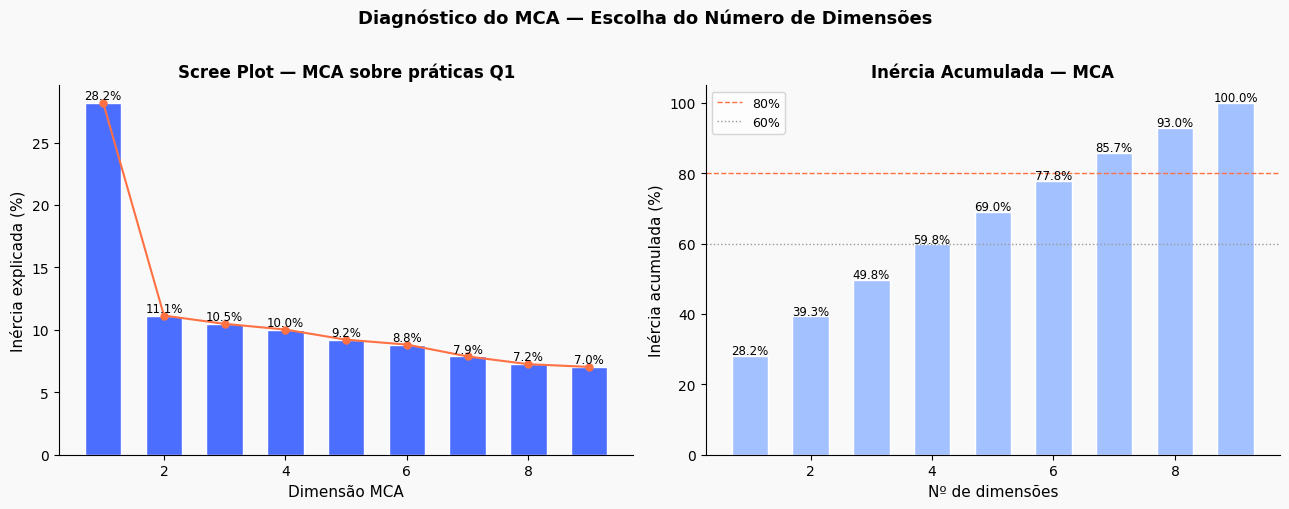


Regra de Kaiser (eigenvalue > média=0.1111): reter 2 dimensão(ões)
Inércia explicada com 2 dim.: 39.3%


In [75]:
# ── 3.8.3  Scree plot — quantas dimensões reter ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Inércia por dimensão
dims = range(1, len(eigenvalues) + 1)
axes[0].bar(dims, explained_pct.values, color=BLUE, edgecolor='white', width=0.6)
axes[0].plot(dims, explained_pct.values, 'o-', color=ORANGE, linewidth=1.5,
             markersize=5, label='Inércia (%)')
for i, val in enumerate(explained_pct.values):
    axes[0].text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8.5)
axes[0].set_xlabel('Dimensão MCA', fontsize=11)
axes[0].set_ylabel('Inércia explicada (%)', fontsize=11)
axes[0].set_title('Scree Plot — MCA sobre práticas Q1', fontsize=12, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Inércia acumulada
axes[1].bar(dims, cumulative.values, color=LIGHT_BLUE, edgecolor='white', width=0.6)
axes[1].axhline(80, color=ORANGE, linestyle='--', linewidth=1, label='80%')
axes[1].axhline(60, color='#999', linestyle=':', linewidth=1, label='60%')
for i, val in enumerate(cumulative.values):
    axes[1].text(i + 1, val + 0.5, f'{val:.1f}%', ha='center', fontsize=8.5)
axes[1].set_xlabel('Nº de dimensões', fontsize=11)
axes[1].set_ylabel('Inércia acumulada (%)', fontsize=11)
axes[1].set_title('Inércia Acumulada — MCA', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Diagnóstico do MCA — Escolha do Número de Dimensões',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Regra de retenção: eigenvalue > média (regra de Kaiser adaptada para MCA)
mean_eigenvalue = total_inertia / len(eigenvalues)
n_dims_kaiser   = (eigenvalues > mean_eigenvalue).sum()
print(f"\nRegra de Kaiser (eigenvalue > média={mean_eigenvalue:.4f}): reter {n_dims_kaiser} dimensão(ões)")
print(f"Inércia explicada com {n_dims_kaiser} dim.: {cumulative.iloc[n_dims_kaiser - 1]:.1f}%")
# Nota: usamos apenas a Dimensão 1 como mca_score.
# A Dim1 capta o eixo de "intensidade de adoção" — é a componente
# que mais distingue empresas com muitas vs. poucas práticas (28% inércia).
# As Dims 2+ capturam padrões de co-ocorrência entre práticas específicas
# (e.g., quais práticas tendem a ser adotadas juntas), o que é uma
# questão diferente da nossa variável dependente.


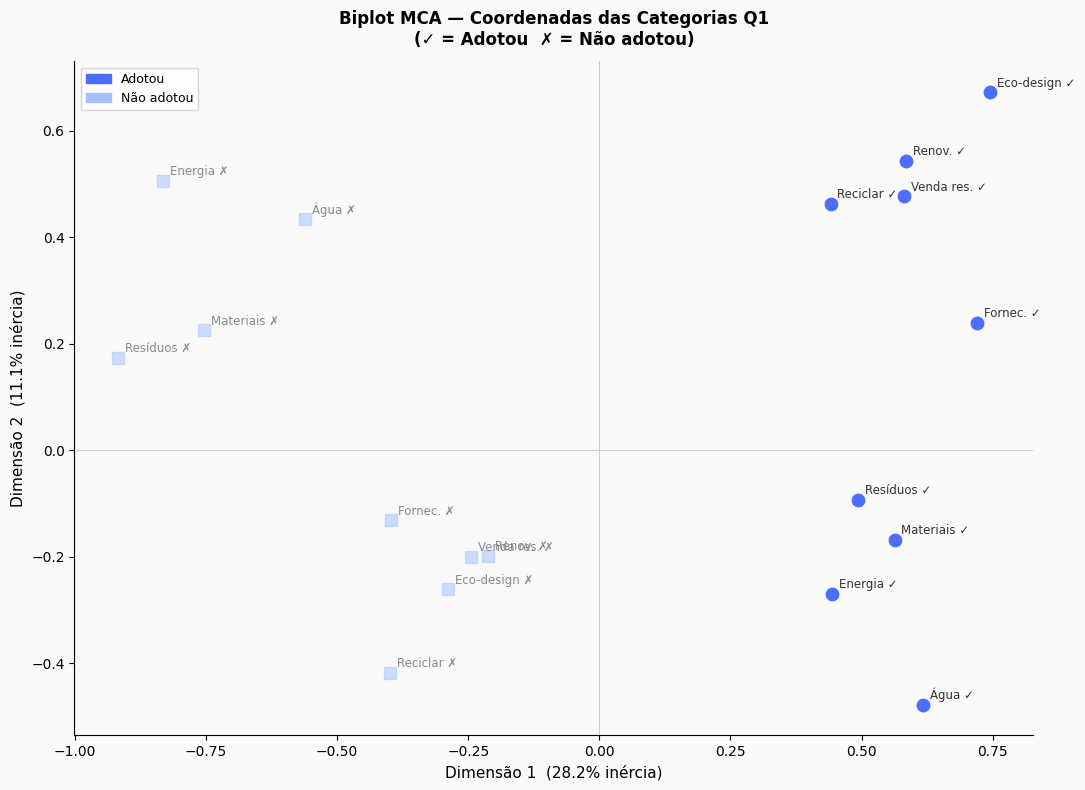

In [76]:
# ── 3.8.4  Biplot das categorias nas duas primeiras dimensões ─────────────────
#
# O biplot mostra onde cada categoria ("Adotou"/"Não adotou" de cada prática)
# se posiciona no espaço fatorial. Categorias próximas tendem a co-ocorrer
# nas mesmas empresas.

col_coords = mca.column_coordinates(df_q1_cat)

fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)

for idx, row in col_coords.iterrows():
    idx_str = str(idx)
    is_adotou = idx_str.endswith('__Adotou')
    cor    = BLUE       if is_adotou else LIGHT_BLUE
    alpha  = 1.0        if is_adotou else 0.5
    marker = 'o'        if is_adotou else 's'
    ax.scatter(row.iloc[0], row.iloc[1], color=cor, alpha=alpha,
               marker=marker, s=80, zorder=3)
    # label abreviado
    label_txt = idx_str.replace('__Adotou', ' ✓').replace('__Não adotou', ' ✗')
    short_map = {
        'Poupar água ✓': 'Água ✓', 'Poupar água ✗': 'Água ✗',
        'Poupar energia ✓': 'Energia ✓', 'Poupar energia ✗': 'Energia ✗',
        'Energia renovável ✓': 'Renov. ✓', 'Energia renovável ✗': 'Renov. ✗',
        'Poupar materiais ✓': 'Materiais ✓', 'Poupar materiais ✗': 'Materiais ✗',
        'Fornecedores mais verdes ✓': 'Fornec. ✓', 'Fornecedores mais verdes ✗': 'Fornec. ✗',
        'Minimizar resíduos ✓': 'Resíduos ✓', 'Minimizar resíduos ✗': 'Resíduos ✗',
        'Vender resíduos ✓': 'Venda res. ✓', 'Vender resíduos ✗': 'Venda res. ✗',
        'Reciclar internamente ✓': 'Reciclar ✓', 'Reciclar internamente ✗': 'Reciclar ✗',
        'Eco-design ✓': 'Eco-design ✓', 'Eco-design ✗': 'Eco-design ✗',
    }
    lbl = short_map.get(label_txt, label_txt)
    ax.annotate(lbl, (row.iloc[0], row.iloc[1]),
                textcoords='offset points', xytext=(5, 4), fontsize=8.5,
                color='#333' if is_adotou else '#888')

ax.axhline(0, color='#ccc', linewidth=0.7)
ax.axvline(0, color='#ccc', linewidth=0.7)
ax.set_xlabel(f'Dimensão 1  ({explained_pct.iloc[0]:.1f}% inércia)', fontsize=11)
ax.set_ylabel(f'Dimensão 2  ({explained_pct.iloc[1]:.1f}% inércia)', fontsize=11)
ax.set_title('Biplot MCA — Coordenadas das Categorias Q1\n(✓ = Adotou  ✗ = Não adotou)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,       label='Adotou'),
    mpatches.Patch(color=LIGHT_BLUE, label='Não adotou'),
], fontsize=9)
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [77]:
# ── 3.8.5  Coordenadas das empresas — extração do mca_score ──────────────────
#
# As coordenadas das empresas na Dimensão 1 são o nosso mca_score.
# A Dimensão 1 captura o eixo principal de variação nas práticas Q1:
#   → valores altos  = empresa com padrão de adoção mais incomum/intenso
#   → valores baixos = empresa com poucas ou nenhuma prática
#
# Nota sobre sinal: em MCA o sinal da dimensão é arbitrário.
# Verificamos a correlação com o intensity_index e invertemos se necessário
# para que mca_score e intensity_index apontem na mesma direção.

row_coords = mca.row_coordinates(df_q1_cat)

# Extrair dimensão 1
mca_dim1 = row_coords.iloc[:, 0].values

# Verificar correlação com intensity_index
corr_check = np.corrcoef(mca_dim1, df_model['intensity_index'].values)[0, 1]
print(f"\nCorrelação Dim1 MCA ↔ intensity_index: {corr_check:.4f}")

# Inverter sinal se correlação negativa (convenção: mais práticas = score maior)
if corr_check < 0:
    mca_dim1 = -mca_dim1
    corr_check = -corr_check
    print("→ Sinal invertido para alinhar com intensity_index (mais práticas = score maior)")
else:
    print("→ Sinal mantido")

df_model['mca_score'] = mca_dim1

print("\n=== mca_score — Estatísticas descritivas ===")
print(df_model['mca_score'].describe().round(4))


Correlação Dim1 MCA ↔ intensity_index: 0.9931
→ Sinal mantido

=== mca_score — Estatísticas descritivas ===
count    13559.0000
mean         0.0000
std          0.5308
min         -0.9640
25%         -0.4012
50%          0.0213
75%          0.4202
max          1.0862
Name: mca_score, dtype: float64


In [78]:
# ── 3.8.6  Pesos implícitos das práticas na Dimensão 1 ───────────────────────
#
# Os pesos implícitos indicam quanto cada prática contribui para o mca_score.
# Uma prática rara (baixa taxa de adoção) terá coordenadas mais afastadas
# da origem — ou seja, discrimina mais entre empresas.

from scipy.stats import spearmanr

# Coordenadas das categorias "Adotou" na Dimensão 1
# Formato do índice varia com a versão do prince:
#   v0.16.6: "label__Adotou" (duplo underscore)
#   versões mais antigas: "label_Adotou" ou (label, "Adotou") como tuplo
col_coords_dim1 = col_coords.iloc[:, 0]
pesos_adotou = {}
for label in labels_q1:
    found = False
    for key in [f'{label}__Adotou', f'{label}_Adotou', (label, 'Adotou')]:
        if key in col_coords_dim1.index:
            pesos_adotou[label] = abs(col_coords_dim1[key])
            found = True
            break
    if not found:
        # Fallback: procurar qualquer entrada que contenha o label e "Adotou"
        matches = [k for k in col_coords_dim1.index if label in str(k) and 'Adotou' in str(k)]
        if matches:
            pesos_adotou[label] = abs(col_coords_dim1[matches[0]])

pesos_df = (pd.DataFrame.from_dict(pesos_adotou, orient='index', columns=['Peso (|coord Dim1|)'])
            .sort_values('Peso (|coord Dim1|)', ascending=False))

# Taxas de adoção (para contextualizar)
taxa_adocao = {
    label: (df_model[col + '_bin'].mean() * 100)
    for col, label in q1_map.items()
}
pesos_df['Taxa adoção (%)'] = pesos_df.index.map(taxa_adocao).round(1)
pesos_df = pesos_df.sort_values('Peso (|coord Dim1|)', ascending=False)

print("\n=== PESOS IMPLÍCITOS DAS PRÁTICAS NO mca_score ===")
print(pesos_df.round(4).to_string())

# Spearman r entre peso e taxa de adoção
rho, pval = spearmanr(pesos_df['Peso (|coord Dim1|)'], pesos_df['Taxa adoção (%)'])
print(f"\nSpearman r (peso ↔ taxa adoção): {rho:.3f}  p={pval:.4f}")
print("→ Correlação negativa esperada: práticas mais raras discriminam mais")
print("  e recebem coordenadas mais afastadas da origem (peso maior).")



=== PESOS IMPLÍCITOS DAS PRÁTICAS NO mca_score ===
                          Peso (|coord Dim1|)  Taxa adoção (%)
Eco-design                             0.7447             28.0
Fornecedores mais verdes               0.7194             35.6
Poupar água                            0.6177             47.6
Energia renovável                      0.5847             26.7
Vender resíduos                        0.5804             29.6
Poupar materiais                       0.5630             57.2
Minimizar resíduos                     0.4942             65.0
Poupar energia                         0.4439             65.2
Reciclar internamente                  0.4409             47.5

Spearman r (peso ↔ taxa adoção): -0.617  p=0.0769
→ Correlação negativa esperada: práticas mais raras discriminam mais
  e recebem coordenadas mais afastadas da origem (peso maior).


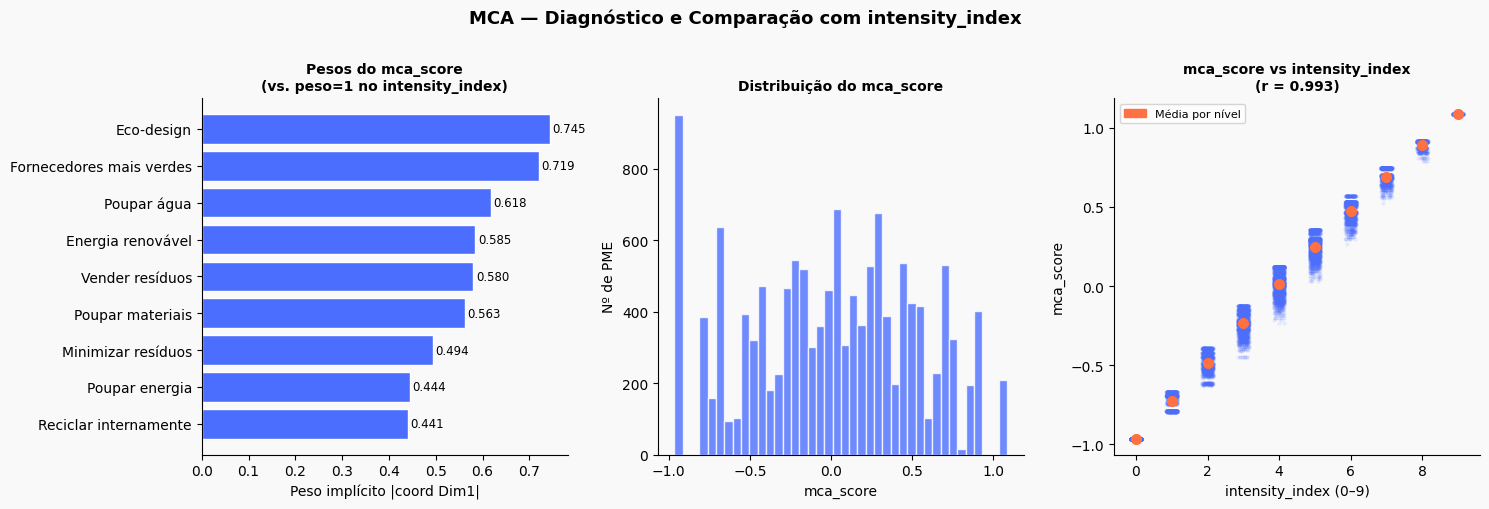


Correlação de Pearson  mca_score ↔ intensity_index: 0.9931
Correlação alta esperada — o mca_score é uma versão ponderada do mesmo conceito.
A diferença está nos pesos: práticas raras têm mais peso no mca_score.


In [79]:
# ── 3.8.7  Visualização — comparação intensity_index vs mca_score ────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)

# Pesos implícitos
sorted_pesos = pesos_df.sort_values('Peso (|coord Dim1|)')
bars = axes[0].barh(sorted_pesos.index, sorted_pesos['Peso (|coord Dim1|)'],
                    color=BLUE, edgecolor='white')
for bar, val in zip(bars, sorted_pesos['Peso (|coord Dim1|)']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Peso implícito |coord Dim1|', fontsize=10)
axes[0].set_title('Pesos do mca_score\n(vs. peso=1 no intensity_index)',
                  fontsize=10, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Distribuição do mca_score
axes[1].hist(df_model['mca_score'], bins=40, color=BLUE, edgecolor='white', alpha=0.8)
axes[1].set_xlabel('mca_score', fontsize=10)
axes[1].set_ylabel('Nº de PME', fontsize=10)
axes[1].set_title('Distribuição do mca_score', fontsize=10, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Scatter: mca_score vs intensity_index
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(df_model))
axes[2].scatter(df_model['intensity_index'] + jitter,
                df_model['mca_score'],
                alpha=0.07, s=5, color=BLUE)
# Médias por nível do índice
for idx_val in range(10):
    mask = df_model['intensity_index'] == idx_val
    if mask.sum() > 10:
        axes[2].plot(idx_val, df_model.loc[mask, 'mca_score'].mean(),
                     'o', color=ORANGE, markersize=7, zorder=4)
axes[2].set_xlabel('intensity_index (0–9)', fontsize=10)
axes[2].set_ylabel('mca_score', fontsize=10)
axes[2].set_title(f'mca_score vs intensity_index\n(r = {corr_check:.3f})',
                  fontsize=10, fontweight='bold')
axes[2].set_facecolor(BG)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].legend(handles=[
    mpatches.Patch(color=ORANGE, label='Média por nível'),
], fontsize=8, loc='upper left')

fig.patch.set_facecolor(BG)
fig.suptitle('MCA — Diagnóstico e Comparação com intensity_index',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCorrelação de Pearson  mca_score ↔ intensity_index: {corr_check:.4f}")
print("Correlação alta esperada — o mca_score é uma versão ponderada do mesmo conceito.")
print("A diferença está nos pesos: práticas raras têm mais peso no mca_score.")

In [80]:
# ── 3.8.8  Adição ao df_model e verificação final ────────────────────────────

print("\n=== df_model — novas variáveis ===")
print(f"  intensity_index  → VD original  (soma simples, 0–9)")
print(f"  mca_score        → VD alternativa (score contínuo ponderado por raridade)")
print(f"\nmca_score — NAs: {df_model['mca_score'].isnull().sum()} → deve ser 0")
print(f"Dimensão df_model após MCA: {df_model.shape}")

# Comparação descritiva por setor e dimensão
print("\n=== mca_score médio por setor ===")
mca_by_sector = (df_model.groupby('nace_b')['mca_score']
    .agg(['mean', 'std', 'count']).round(4)
    .sort_values('mean', ascending=False))
mca_by_sector.index = mca_by_sector.index.map(sector_map)
print(mca_by_sector)

print("\n=== mca_score médio por dimensão ===")
mca_by_size = (df_model[df_model['scr10'].isin(size_order)]
    .groupby('scr10')['mca_score']
    .agg(['mean', 'std', 'count'])
    .reindex(size_order).round(4))
mca_by_size.index = mca_by_size.index.map(size_map)
print(mca_by_size)


=== df_model — novas variáveis ===
  intensity_index  → VD original  (soma simples, 0–9)
  mca_score        → VD alternativa (score contínuo ponderado por raridade)

mca_score — NAs: 0 → deve ser 0
Dimensão df_model após MCA: (13559, 82)

=== mca_score médio por setor ===
                       mean     std  count
nace_b                                    
Manufatura (C)       0.1028  0.5217   2736
Retalho (G)         -0.0004  0.5289   4016
Indústria (B/D/E/F) -0.0021  0.5270   2671
Serviços (H–M)      -0.0663  0.5306   4136

=== mca_score médio por dimensão ===
                   mean     std  count
scr10                                 
Micro (1–9)     -0.0725  0.5309   5941
Pequena (10–49)  0.0232  0.5278   4992
Média (50–249)   0.1200  0.5106   2626


In [81]:
# ── 3.8.9  Estandardização do mca_score ──────────────────────────────────────
# Para consistência com os restantes preditores contínuos,
# criamos também uma versão estandardizada do mca_score.

df_model['mca_score_z'] = (
    (df_model['mca_score'] - df_model['mca_score'].mean())
    / df_model['mca_score'].std()
)

print("=== mca_score_z — verificação ===")
print(f"  Média:  {df_model['mca_score_z'].mean():.6f}  (≈0)")
print(f"  Desvio: {df_model['mca_score_z'].std():.6f}  (≈1)")
print(f"\ndf_model final: {df_model.shape[0]:,} linhas × {df_model.shape[1]} colunas")

=== mca_score_z — verificação ===
  Média:  -0.000000  (≈0)
  Desvio: 1.000000  (≈1)

df_model final: 13,559 linhas × 83 colunas


# 4. Modelação



## 4.1 Regressões Logísticas Individuais — Complemento Descritivo ao MCA



> Para complementar a ponderação por raridade do MCA (Secção 3.8), ajustamos uma regressão logística separada para cada prática Q1 como variável dependente, usando apenas preditores estruturais (sem barreiras Q7). O pseudo-R² de McFadden indica quanta variância na adoção de cada prática é explicada pelas características observáveis da empresa. Práticas com R² baixo refletem decisões idiossincráticas; práticas com R² alto são mais previsíveis a partir do perfil estrutural.

In [82]:
# ── 4.1.1  Regressões logísticas individuais (9 práticas Q1) ──────────────────
import statsmodels.api as sm

# Preditores estruturais — sem Q7 (outcomes), sem hired_bin (redundante c/ fin_difficulty)
struct_predictors = (
    ['d_industry', 'd_retail', 'd_services']
    + ['d_small', 'd_medium']
    + ['d_age_2016_18', 'd_age_2019_23', 'd_age_post2023', 'd_age_dkna']
    + ['d_turn_inc_lot', 'd_turn_inc_lit', 'd_turn_dec', 'd_turn_dkna']
    + ['d_q3_dec_lot', 'd_q3_dec_lit', 'd_q3_inc_lit', 'd_q3_inc_lot', 'd_q3_dkna']
    + ['d_q4_lt1', 'd_q4_1_5', 'd_q4_6_10', 'd_q4_11_30', 'd_q4_gt30', 'd_q4_dkna']
    + ['d_products', 'd_services_sc', 'd_scr16_dkna']
    + ['turnover_size', 'turnover_unknown']
    + ['fin_difficulty']
)

q1_bins = [f'{col}_bin' for col in q1_map.keys()]
X = sm.add_constant(df_model[struct_predictors])

results_logit = {}
summary_rows = []

for col, (q1_key, label) in zip(q1_bins, q1_map.items()):
    y = df_model[col]
    model = sm.Logit(y, X)
    fit = model.fit(disp=0)
    results_logit[q1_key] = fit
    summary_rows.append({
        'Prática': label,
        'q1_var': q1_key,
        'N': int(fit.nobs),
        'Taxa adoção (%)': round(y.mean() * 100, 1),
        'Pseudo-R² (McFadden)': fit.prsquared,
        'Log-Lik': fit.llf,
        'AIC': fit.aic,
    })

df_logit_summary = pd.DataFrame(summary_rows)
df_logit_summary = df_logit_summary.sort_values('Pseudo-R² (McFadden)', ascending=False)

print("=== REGRESSÕES LOGÍSTICAS INDIVIDUAIS — RESUMO ===\n")
print(f"Preditores estruturais: {len(struct_predictors)} variáveis")
print(f"Observações: {int(df_logit_summary['N'].iloc[0]):,}\n")
print(df_logit_summary[['Prática', 'Taxa adoção (%)', 'Pseudo-R² (McFadden)', 'AIC']]
      .round(4).to_string(index=False))

print("\n→ Pseudo-R² de McFadden mais alto = prática mais previsível pelo perfil estrutural.")
print("  Pseudo-R² mais baixo = adoção depende mais de decisões idiossincráticas da empresa.")

=== REGRESSÕES LOGÍSTICAS INDIVIDUAIS — RESUMO ===

Preditores estruturais: 30 variáveis
Observações: 13,559

                 Prática  Taxa adoção (%)  Pseudo-R² (McFadden)        AIC
         Vender resíduos             29.6                0.0949 14965.7973
          Poupar energia             65.2                0.0766 16239.8963
      Minimizar resíduos             65.0                0.0706 16379.7107
       Energia renovável             26.7                0.0687 14710.5432
        Poupar materiais             57.2                0.0577 17507.4109
              Eco-design             28.0                0.0533 15273.2641
Fornecedores mais verdes             35.6                0.0491 16844.5565
             Poupar água             47.6                0.0433 18013.8622
   Reciclar internamente             47.5                0.0390 18092.6338

→ Pseudo-R² de McFadden mais alto = prática mais previsível pelo perfil estrutural.
  Pseudo-R² mais baixo = adoção depende mais de decisõe

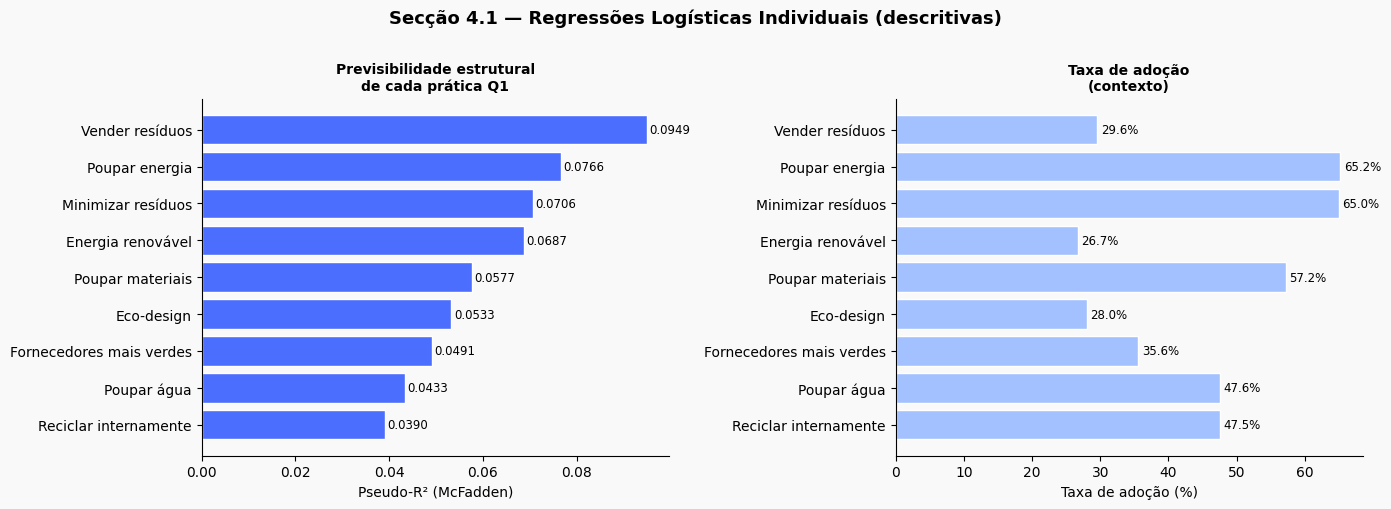

In [83]:
# ── 4.1.2  Visualização — pseudo-R² por prática ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

sorted_df = df_logit_summary.sort_values('Pseudo-R² (McFadden)')

# Painel 1: Pseudo-R²
bars = axes[0].barh(sorted_df['Prática'], sorted_df['Pseudo-R² (McFadden)'],
                    color=BLUE, edgecolor='white')
for bar, val in zip(bars, sorted_df['Pseudo-R² (McFadden)']):
    axes[0].text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Pseudo-R² (McFadden)', fontsize=10)
axes[0].set_title('Previsibilidade estrutural\nde cada prática Q1',
                  fontsize=10, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Painel 2: Taxa de adoção (contexto)
bars2 = axes[1].barh(sorted_df['Prática'], sorted_df['Taxa adoção (%)'],
                     color=LIGHT_BLUE, edgecolor='white')
for bar, val in zip(bars2, sorted_df['Taxa adoção (%)']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8.5)
axes[1].set_xlabel('Taxa de adoção (%)', fontsize=10)
axes[1].set_title('Taxa de adoção\n(contexto)', fontsize=10, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Secção 4.1 — Regressões Logísticas Individuais (descritivas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

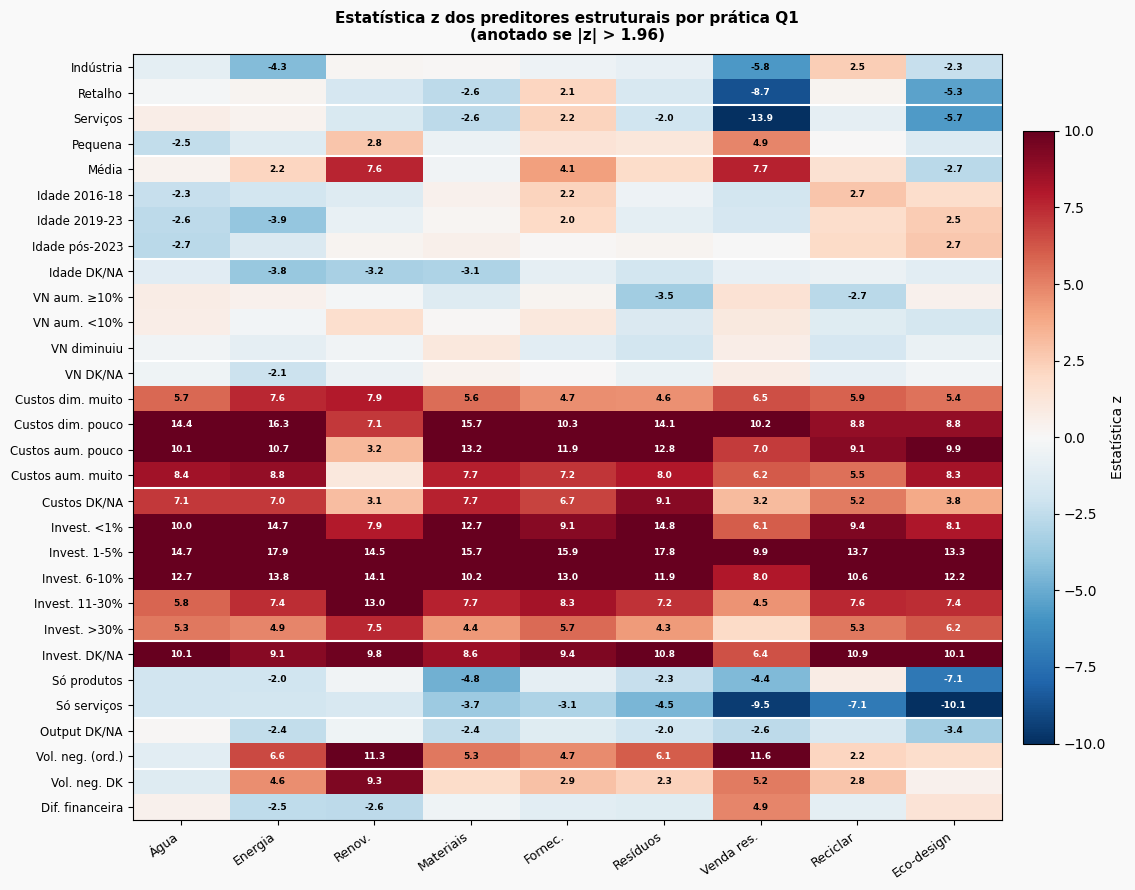

In [84]:
# ── 4.1.3  Heatmap de coeficientes — preditores × práticas ───────────────────
#
# Valores z (coef / erro padrão): indicam direção e significância.
# |z| > 1.96 ≈ significativo a 5%.

predictor_labels = {
    'd_industry': 'Indústria', 'd_retail': 'Retalho', 'd_services': 'Serviços',
    'd_small': 'Pequena', 'd_medium': 'Média',
    'd_age_2016_18': 'Idade 2016-18', 'd_age_2019_23': 'Idade 2019-23',
    'd_age_post2023': 'Idade pós-2023', 'd_age_dkna': 'Idade DK/NA',
    'd_turn_inc_lot': 'VN aum. ≥10%', 'd_turn_inc_lit': 'VN aum. <10%',
    'd_turn_dec': 'VN diminuiu', 'd_turn_dkna': 'VN DK/NA',
    'd_q3_dec_lot': 'Custos dim. muito', 'd_q3_dec_lit': 'Custos dim. pouco',
    'd_q3_inc_lit': 'Custos aum. pouco', 'd_q3_inc_lot': 'Custos aum. muito',
    'd_q3_dkna': 'Custos DK/NA',
    'd_q4_lt1': 'Invest. <1%', 'd_q4_1_5': 'Invest. 1-5%',
    'd_q4_6_10': 'Invest. 6-10%', 'd_q4_11_30': 'Invest. 11-30%',
    'd_q4_gt30': 'Invest. >30%', 'd_q4_dkna': 'Invest. DK/NA',
    'd_products': 'Só produtos', 'd_services_sc': 'Só serviços', 'd_scr16_dkna': 'Output DK/NA',
    'turnover_size': 'Vol. neg. (ord.)', 'turnover_unknown': 'Vol. neg. DK',
    'fin_difficulty': 'Dif. financeira',
}

# Construir matriz de z-values (sem const)
z_matrix = pd.DataFrame()
for q1_key, fit in results_logit.items():
    z_vals = fit.tvalues[1:]  # excluir constante
    z_matrix[q1_map[q1_key]] = z_vals.values

z_matrix.index = [predictor_labels.get(p, p) for p in struct_predictors]

# Abreviar nomes longos das práticas para caber no eixo x
short_practice = {
    'Poupar água': 'Água', 'Poupar energia': 'Energia',
    'Energia renovável': 'Renov.', 'Poupar materiais': 'Materiais',
    'Fornecedores mais verdes': 'Fornec.', 'Minimizar resíduos': 'Resíduos',
    'Vender resíduos': 'Venda res.', 'Reciclar internamente': 'Reciclar',
    'Eco-design': 'Eco-design',
}
z_display = z_matrix.rename(columns=short_practice)

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
vmax = 10
im = ax.imshow(z_display.values, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(z_display.columns)))
ax.set_xticklabels(z_display.columns, fontsize=9, rotation=35, ha='right')
ax.set_yticks(range(len(z_display.index)))
ax.set_yticklabels(z_display.index, fontsize=8.5)

# Anotar células com |z| > 1.96 (significativo a 5%)
for i in range(z_display.shape[0]):
    for j in range(z_display.shape[1]):
        val = z_display.iloc[i, j]
        if abs(val) > 1.96:
            color = 'white' if abs(val) > 6 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=6.5, fontweight='bold', color=color)

# Linhas horizontais entre grupos de preditores
group_ends = [2, 4, 8, 12, 17, 23, 26, 28]  # after sector, size, age, emp, Q3, Q4, rest
for ge in group_ends:
    ax.axhline(ge - 0.5, color='white', linewidth=1.5)

ax.set_title('Estatística z dos preditores estruturais por prática Q1\n(anotado se |z| > 1.96)',
             fontsize=11, fontweight='bold', pad=10)
cbar = plt.colorbar(im, ax=ax, label='Estatística z', shrink=0.8, pad=0.02)
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

In [85]:
# ── 4.1.4  Comparação com pesos MCA e síntese ────────────────────────────────

comparison = df_logit_summary[['Prática', 'q1_var', 'Taxa adoção (%)', 'Pseudo-R² (McFadden)']].copy()
comparison['Peso MCA'] = comparison['Prática'].map(
    pesos_df['Peso (|coord Dim1|)'].to_dict()
)
comparison = comparison.sort_values('Pseudo-R² (McFadden)', ascending=False)

print("=== COMPARAÇÃO: PSEUDO-R² vs PESOS MCA vs TAXA DE ADOÇÃO ===\n")
print(comparison[['Prática', 'Taxa adoção (%)', 'Pseudo-R² (McFadden)', 'Peso MCA']]
      .round(4).to_string(index=False))

# Spearman
rho1, p1 = spearmanr(comparison['Pseudo-R² (McFadden)'], comparison['Taxa adoção (%)'])
rho2, p2 = spearmanr(comparison['Pseudo-R² (McFadden)'], comparison['Peso MCA'])
rho3, p3 = spearmanr(comparison['Taxa adoção (%)'], comparison['Peso MCA'])

print(f"\nSpearman r (pseudo-R² ↔ taxa adoção):  {rho1:.3f}  p={p1:.4f}")
print(f"Spearman r (pseudo-R² ↔ peso MCA):     {rho2:.3f}  p={p2:.4f}")
print(f"Spearman r (taxa adoção ↔ peso MCA):   {rho3:.3f}  p={p3:.4f}")

print("\n→ Interpretação:")
print("  O pseudo-R² mede a previsibilidade estrutural de cada prática.")
print("  O peso MCA mede a capacidade discriminante (raridade × correlação).")
print("  Se ambos apontam na mesma direção, reforça-se a evidência de que")
print("  práticas raras e idiossincráticas são as mais informativas.")

=== COMPARAÇÃO: PSEUDO-R² vs PESOS MCA vs TAXA DE ADOÇÃO ===

                 Prática  Taxa adoção (%)  Pseudo-R² (McFadden)  Peso MCA
         Vender resíduos             29.6                0.0949    0.5804
          Poupar energia             65.2                0.0766    0.4439
      Minimizar resíduos             65.0                0.0706    0.4942
       Energia renovável             26.7                0.0687    0.5847
        Poupar materiais             57.2                0.0577    0.5630
              Eco-design             28.0                0.0533    0.7447
Fornecedores mais verdes             35.6                0.0491    0.7194
             Poupar água             47.6                0.0433    0.6177
   Reciclar internamente             47.5                0.0390    0.4409

Spearman r (pseudo-R² ↔ taxa adoção):  0.133  p=0.7324
Spearman r (pseudo-R² ↔ peso MCA):     -0.200  p=0.6059
Spearman r (taxa adoção ↔ peso MCA):   -0.617  p=0.0769

→ Interpretação:
  O pseudo-R

## 4.2 Regressão OLS — Índice de Intensidade

Três modelos OLS aninhados sobre o `intensity_index` (0–9), com efeitos fixos de país (ref: DE — Alemanha):

- **M1** — setor + dimensão + 27 efeitos fixos de país
- **M2** — M1 + características da empresa (antiguidade, evolução VN, custos Q3, investimento Q4, tipo de output, vol. negócios, dificuldade financeira)
- **M3** — M2 + barreiras Q7

O ΔR² entre blocos quantifica o contributo marginal de cada conjunto de variáveis.
Os resíduos médios por país em M2 identificam candidatos a efeitos aleatórios no modelo multinível.

In [86]:
# ── 4.2.1  Modelos OLS aninhados ─────────────────────────────────────────────
import statsmodels.api as sm

# Efeitos fixos de país (ref: DE — maior economia da UE)
countries_eu = sorted([c for c in df_model['isocntry'].unique() if c != 'DE'])
for c in countries_eu:
    df_model[f'd_{c}'] = (df_model['isocntry'] == c).astype(int)

# ── Especificação dos modelos ─────────────────────────────────────────────────
X_M1 = (
    ['d_industry', 'd_retail', 'd_services']
    + ['d_small', 'd_medium']
    + [f'd_{c}' for c in countries_eu]
)
X_M2 = X_M1 + [
    'd_age_2016_18', 'd_age_2019_23', 'd_age_post2023', 'd_age_dkna',
    'd_turn_inc_lot', 'd_turn_inc_lit', 'd_turn_dec', 'd_turn_dkna',
    'd_q3_dec_lot', 'd_q3_dec_lit', 'd_q3_inc_lit', 'd_q3_inc_lot', 'd_q3_dkna',
    'd_q4_lt1', 'd_q4_1_5', 'd_q4_6_10', 'd_q4_11_30', 'd_q4_gt30', 'd_q4_dkna',
    'd_products', 'd_services_sc', 'd_scr16_dkna',
    'turnover_size', 'turnover_unknown', 'fin_difficulty',
]
X_M3 = X_M2 + list(q7_map.keys()) + ['no_barriers']

# Amostra completa (dummies absorvem todos os DK/NA)
df_ols = df_model[X_M3 + ['intensity_index', 'isocntry']].dropna().copy()
y_ols  = df_ols['intensity_index'].astype(float)

M = {}
for name, cols in [('M1', X_M1), ('M2', X_M2), ('M3', X_M3)]:
    M[name] = sm.OLS(y_ols, sm.add_constant(df_ols[cols].astype(float))).fit()

print("=== OLS — AJUSTE DOS MODELOS ===\n")
print(f"{'Modelo':<8} {'R²':>8} {'R²adj':>8} {'AIC':>12} {'BIC':>12} {'N':>7} {'K':>5}")
print(f"{'─'*60}")
for name, m in M.items():
    print(f"{name:<8} {m.rsquared:>8.4f} {m.rsquared_adj:>8.4f} "
          f"{m.aic:>12.1f} {m.bic:>12.1f} {int(m.nobs):>7,} {int(m.df_model):>5}")
print()
print(f"ΔR² M2−M1: {M['M2'].rsquared - M['M1'].rsquared:.4f}  "
      f"(contributo das variáveis de empresa)")
print(f"ΔR² M3−M2: {M['M3'].rsquared - M['M2'].rsquared:.4f}  "
      f"(contributo das barreiras Q7)")
print()
print("→ M1 já captura variação entre países via efeitos fixos.")
print("  O modelo multinível substituirá estes efeitos fixos por efeitos aleatórios,")
print("  permitindo modelar a variância de nível país e adicionar preditores de nível 2.")

=== OLS — AJUSTE DOS MODELOS ===

Modelo         R²    R²adj          AIC          BIC       N     K
────────────────────────────────────────────────────────────
M1         0.1666   0.1647      57981.3      58229.2  13,559    32
M2         0.3337   0.3309      54996.7      55432.6  13,559    57
M3         0.4217   0.4187      53103.9      53637.5  13,559    70

ΔR² M2−M1: 0.1671  (contributo das variáveis de empresa)
ΔR² M3−M2: 0.0879  (contributo das barreiras Q7)

→ M1 já captura variação entre países via efeitos fixos.
  O modelo multinível substituirá estes efeitos fixos por efeitos aleatórios,
  permitindo modelar a variância de nível país e adicionar preditores de nível 2.


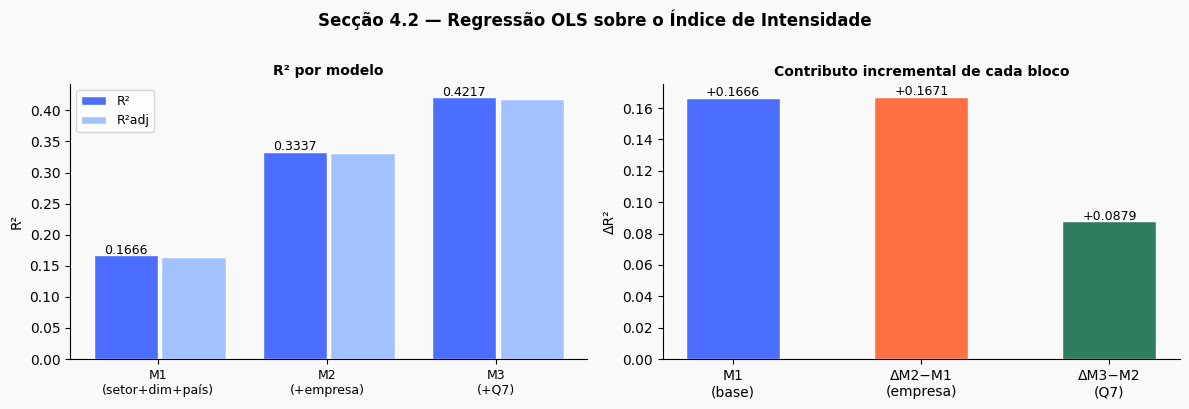

In [87]:
# ── 4.2.2  Visualização — R² incremental por bloco ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)

# Painel 1: R² e R²adj por modelo
model_labels = ['M1\n(setor+dim+país)', 'M2\n(+empresa)', 'M3\n(+Q7)']
r2_vals = [M[m].rsquared     for m in ['M1','M2','M3']]
r2_adj  = [M[m].rsquared_adj for m in ['M1','M2','M3']]
x = range(len(model_labels))
bars1 = axes[0].bar(x, r2_vals, color=BLUE, width=0.38, label='R²', edgecolor='white')
axes[0].bar([i+0.4 for i in x], r2_adj, color=LIGHT_BLUE, width=0.38, label='R²adj', edgecolor='white')
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.002, f'{val:.4f}', ha='center', fontsize=9)
axes[0].set_xticks([i+0.19 for i in x])
axes[0].set_xticklabels(model_labels, fontsize=9)
axes[0].set_ylabel('R²', fontsize=10)
axes[0].set_title('R² por modelo', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Painel 2: ΔR² incremental por bloco
delta_labels = ['M1\n(base)', 'ΔM2−M1\n(empresa)', 'ΔM3−M2\n(Q7)']
delta_vals   = [M['M1'].rsquared,
                M['M2'].rsquared - M['M1'].rsquared,
                M['M3'].rsquared - M['M2'].rsquared]
delta_colors = [BLUE, ORANGE, GREEN]
bars2 = axes[1].bar(delta_labels, delta_vals, color=delta_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, delta_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.001,
                 f'+{val:.4f}', ha='center', fontsize=9)
axes[1].set_ylabel('ΔR²', fontsize=10)
axes[1].set_title('Contributo incremental de cada bloco', fontsize=10, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.suptitle('Secção 4.2 — Regressão OLS sobre o Índice de Intensidade',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Preditores no modelo: 30  (sem dummies de país)
R² com efeitos fixos de país (M2):      0.3337
R² sem efeitos fixos de país (M2_nofe): 0.2271
→ A diferença (0.1067) é a variância explicada
  apenas por saber em que país está a empresa.

=== RESÍDUOS MÉDIOS POR PAÍS — M2 sem efeitos fixos de país ===

          Resíduo médio     DP    N
isocntry                           
IE               -1.444  1.248  476
PT               -1.439  1.361  544
HR               -1.083  1.963  493
MT               -0.689  1.431  249
CY               -0.657  1.697  248
LV               -0.596  1.857  502
EE               -0.584  2.024  497
PL               -0.509  1.822  553
BG               -0.447  2.014  475
SI               -0.363  1.989  459
HU               -0.278  1.977  468
RO               -0.092  2.124  595
AT               -0.091  1.609  455
IT               -0.074  1.580  545
GR                0.100  1.940  566
LU                0.111  1.589  250
NL                0.150  1.638  550
DE            

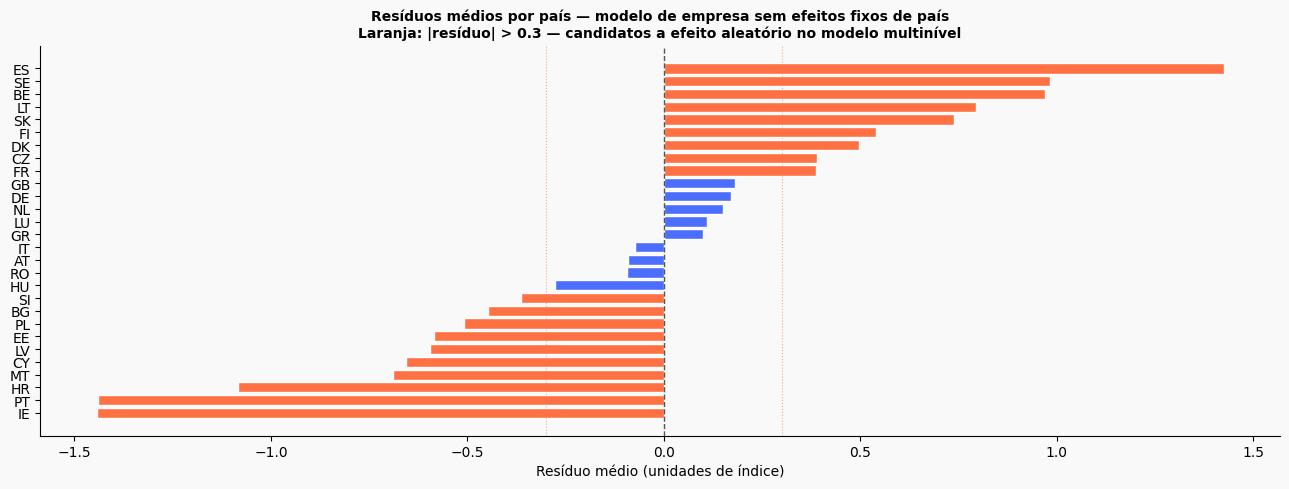


→ Países com resíduos sistemáticos elevados indicam que fatores contextuais
  (legislação, incentivos, cultura) explicam variação não captada pelas
  características da empresa → motivação directa para o modelo multinível.


In [88]:
# ── 4.2.3  Resíduos médios por país — modelo sem efeitos fixos de país ──────
#
# PORQUÊ sem efeitos fixos?
# M1/M2/M3 já incluem dummies de país, logo os resíduos médios por país
# são ~0 por construção (propriedade das condições de primeira ordem do OLS).
# Para diagnosticar variação de nível-país não explicada, corremos um modelo
# apenas com as variáveis de empresa (sem dummies de país) e vemos o que sobra
# ao nível do país — esses resíduos motivam o modelo multinível.

# Preditores de empresa (definidos explicitamente — sem dummies de país)
firm_vars = [
    'd_industry', 'd_retail', 'd_services',          # setor (ref: Manufatura)
    'd_small', 'd_medium',                            # dimensão (ref: Micro)
    'd_age_2016_18', 'd_age_2019_23',                 # antiguidade
    'd_age_post2023', 'd_age_dkna',
    'd_turn_inc_lot', 'd_turn_inc_lit',               # evolução VN
    'd_turn_dec', 'd_turn_dkna',
    'd_q3_dec_lot', 'd_q3_dec_lit',                  # impacto custos
    'd_q3_inc_lit', 'd_q3_inc_lot', 'd_q3_dkna',
    'd_q4_lt1', 'd_q4_1_5', 'd_q4_6_10',            # investimento Q4
    'd_q4_11_30', 'd_q4_gt30', 'd_q4_dkna',
    'd_products', 'd_services_sc', 'd_scr16_dkna',   # tipo de output
    'turnover_size', 'turnover_unknown',              # volume de negócios
    'fin_difficulty',                                 # dificuldade financeira
]  # 30 preditores — sem qualquer dummy de país

# Amostra: reutiliza df_ols (definido em 4.2.1) para consistência
df_ols_nofe = df_model[firm_vars + ['intensity_index', 'isocntry']].dropna().copy()
y_ols_nofe  = df_ols_nofe['intensity_index'].astype(float)

M2_nofe = sm.OLS(
    y_ols_nofe,
    sm.add_constant(df_ols_nofe[firm_vars].astype(float))
).fit()

print(f"Preditores no modelo: {len(firm_vars)}  (sem dummies de país)")
print(f"R² com efeitos fixos de país (M2):      {M['M2'].rsquared:.4f}")
print(f"R² sem efeitos fixos de país (M2_nofe): {M2_nofe.rsquared:.4f}")
print(f"→ A diferença ({M['M2'].rsquared - M2_nofe.rsquared:.4f}) é a variância explicada")
print(f"  apenas por saber em que país está a empresa.\n")

resid_by_country = (
    pd.DataFrame({
        'resid':    M2_nofe.resid.values,
        'isocntry': df_ols_nofe['isocntry'].values,
    })
    .groupby('isocntry')['resid']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'Resíduo médio', 'std': 'DP', 'count': 'N'})
    .sort_values('Resíduo médio')
)

print("=== RESÍDUOS MÉDIOS POR PAÍS — M2 sem efeitos fixos de país ===\n")
print(resid_by_country.round(3).to_string())
print(f"\n→ {(resid_by_country['Resíduo médio'].abs() > 0.3).sum()} países com |resíduo| > 0.3")

fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
colors_r = [ORANGE if abs(v) > 0.3 else BLUE
            for v in resid_by_country['Resíduo médio']]
ax.barh(resid_by_country.index, resid_by_country['Resíduo médio'],
        color=colors_r, edgecolor='white')
ax.axvline(0, color='#555', linewidth=1, linestyle='--')
ax.axvline( 0.3, color=ORANGE, linewidth=0.8, linestyle=':', alpha=0.6)
ax.axvline(-0.3, color=ORANGE, linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_xlabel('Resíduo médio (unidades de índice)', fontsize=10)
ax.set_title(
    'Resíduos médios por país — modelo de empresa sem efeitos fixos de país\n'
    'Laranja: |resíduo| > 0.3 — candidatos a efeito aleatório no modelo multinível',
    fontsize=10, fontweight='bold'
)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\n→ Países com resíduos sistemáticos elevados indicam que fatores contextuais")
print("  (legislação, incentivos, cultura) explicam variação não captada pelas")
print("  características da empresa → motivação directa para o modelo multinível.")

## 4.3 Regressão OLS — Score MCA

Repetição da estrutura de 4.2 com `mca_score` como variável dependente.

- **M1_mca** — setor + dimensão + 27 efeitos fixos de país
- **M2_mca** — M1_mca + características da empresa
- **M3_mca** — M2_mca + barreiras Q7

**Racional:** A correlação entre `mca_score` e `intensity_index` é r = 0.993, por isso os resultados serão substantivamente semelhantes. As divergências nos R² e padrões de coeficientes identificam onde a ponderação MCA introduz diferenças reais. Ao contrário do `intensity_index` (inteiro discreto 0–9), o `mca_score` é contínuo e sem limites rígidos, o que torna os pressupostos OLS marginalmente mais adequados.

Os resíduos médios por país em M2_mca são comparados directamente com os de M2 (secção 4.2) — países onde a ordenação se mantém confirmam a robustez do sinal; países onde diverge indicam que a ponderação MCA captura algo diferente da simples contagem.

In [89]:
# ── 4.3.1  Modelos OLS aninhados sobre mca_score ─────────────────────────────
#
# Mesma especificação de 4.2 — M1/M2/M3 aninhados com efeitos fixos de país.
# Usamos prefixo M_mca para não sobreescrever os objetos de 4.2.

df_ols_mca = df_model[X_M3 + ['mca_score', 'isocntry']].dropna().copy()
y_mca      = df_ols_mca['mca_score'].astype(float)

M_mca = {}
for name, cols in [('M1', X_M1), ('M2', X_M2), ('M3', X_M3)]:
    M_mca[name] = sm.OLS(y_mca, sm.add_constant(df_ols_mca[cols].astype(float))).fit()

print("=== OLS (mca_score) — AJUSTE DOS MODELOS ===\n")
print(f"{'Modelo':<8} {'R²':>8} {'R²adj':>8} {'AIC':>12} {'BIC':>12} {'N':>7} {'K':>5}")
print(f"{'─'*60}")
for name, m in M_mca.items():
    print(f"{name:<8} {m.rsquared:>8.4f} {m.rsquared_adj:>8.4f} "
          f"{m.aic:>12.1f} {m.bic:>12.1f} {int(m.nobs):>7,} {int(m.df_model):>5}")
print()
print(f"ΔR² M2−M1: {M_mca['M2'].rsquared - M_mca['M1'].rsquared:.4f}  "
      f"(contributo das variáveis de empresa)")
print(f"ΔR² M3−M2: {M_mca['M3'].rsquared - M_mca['M2'].rsquared:.4f}  "
      f"(contributo das barreiras Q7)")
print()

# Comparação directa com 4.2
print("=== COMPARAÇÃO 4.2 vs 4.3 ===\n")
print(f"{'Modelo':<8} {'R²  intensity':>16} {'R²  mca_score':>16} {'Δ':>8}")
print(f"{'─'*52}")
for name in ['M1', 'M2', 'M3']:
    r2_int = M[name].rsquared
    r2_mca = M_mca[name].rsquared
    print(f"{name:<8} {r2_int:>16.4f} {r2_mca:>16.4f} {r2_mca - r2_int:>+8.4f}")
print()
print("→ R² próximos confirmam robustez: os preditores estruturais têm")
print("  poder explicativo semelhante independentemente da ponderação do DV.")

=== OLS (mca_score) — AJUSTE DOS MODELOS ===

Modelo         R²    R²adj          AIC          BIC       N     K
────────────────────────────────────────────────────────────
M1         0.1641   0.1621      18938.3      19186.3  13,559    32
M2         0.3295   0.3267      15997.6      16433.5  13,559    57
M3         0.4216   0.4186      14020.8      14554.4  13,559    70

ΔR² M2−M1: 0.1655  (contributo das variáveis de empresa)
ΔR² M3−M2: 0.0921  (contributo das barreiras Q7)

=== COMPARAÇÃO 4.2 vs 4.3 ===

Modelo      R²  intensity    R²  mca_score        Δ
────────────────────────────────────────────────────
M1                 0.1666           0.1641  -0.0025
M2                 0.3337           0.3295  -0.0042
M3                 0.4217           0.4216  -0.0001

→ R² próximos confirmam robustez: os preditores estruturais têm
  poder explicativo semelhante independentemente da ponderação do DV.


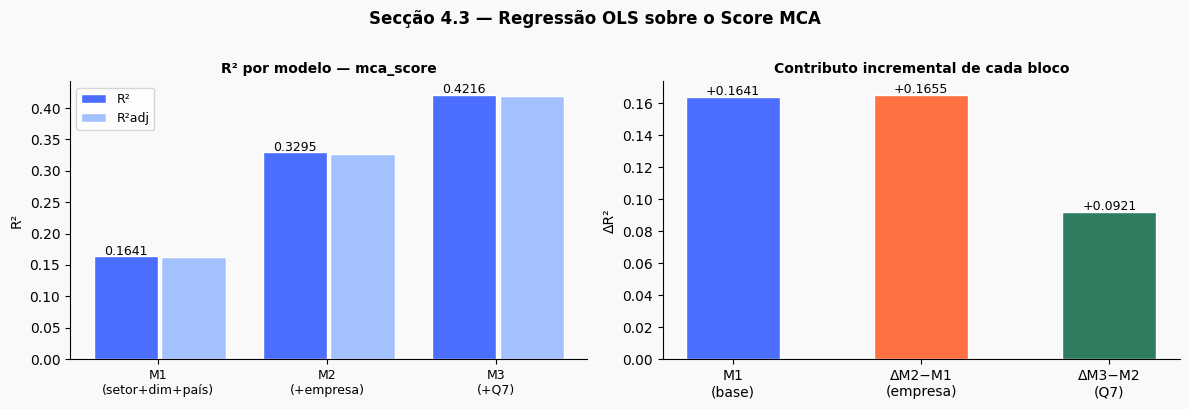

In [90]:
# ── 4.3.2  Visualização — R² incremental por bloco (mca_score) ──────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=BG)

# Painel 1: R² e R²adj por modelo
model_labels = ['M1\n(setor+dim+país)', 'M2\n(+empresa)', 'M3\n(+Q7)']
r2_vals = [M_mca[m].rsquared     for m in ['M1','M2','M3']]
r2_adj  = [M_mca[m].rsquared_adj for m in ['M1','M2','M3']]
x = range(len(model_labels))
bars1 = axes[0].bar(x, r2_vals, color=BLUE, width=0.38, label='R²', edgecolor='white')
axes[0].bar([i+0.4 for i in x], r2_adj, color=LIGHT_BLUE, width=0.38,
            label='R²adj', edgecolor='white')
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.002,
                 f'{val:.4f}', ha='center', fontsize=9)
axes[0].set_xticks([i+0.19 for i in x])
axes[0].set_xticklabels(model_labels, fontsize=9)
axes[0].set_ylabel('R²', fontsize=10)
axes[0].set_title('R² por modelo — mca_score', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Painel 2: ΔR² incremental por bloco
delta_labels = ['M1\n(base)', 'ΔM2−M1\n(empresa)', 'ΔM3−M2\n(Q7)']
delta_vals   = [M_mca['M1'].rsquared,
                M_mca['M2'].rsquared - M_mca['M1'].rsquared,
                M_mca['M3'].rsquared - M_mca['M2'].rsquared]
delta_colors = [BLUE, ORANGE, GREEN]
bars2 = axes[1].bar(delta_labels, delta_vals, color=delta_colors,
                    edgecolor='white', width=0.5)
for bar, val in zip(bars2, delta_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.001,
                 f'+{val:.4f}', ha='center', fontsize=9)
axes[1].set_ylabel('ΔR²', fontsize=10)
axes[1].set_title('Contributo incremental de cada bloco', fontsize=10, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.suptitle('Secção 4.3 — Regressão OLS sobre o Score MCA',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== RESÍDUOS MÉDIOS POR PAÍS — M2_mca sem efeitos fixos ===

          Resíduo MCA  DP_mca    N
isocntry                          
PT             -0.364   0.325  544
IE             -0.354   0.303  476
HR             -0.256   0.478  493
MT             -0.180   0.339  249
CY             -0.165   0.416  248
EE             -0.137   0.485  497
LV             -0.119   0.454  502
PL             -0.116   0.442  553
BG             -0.096   0.485  475
SI             -0.095   0.476  459
HU             -0.059   0.470  468
AT             -0.023   0.378  455
RO             -0.023   0.508  595
IT             -0.013   0.369  545
LU              0.017   0.375  250
NL              0.019   0.383  550
GR              0.031   0.468  566
DE              0.032   0.480  571
GB              0.039   0.365  435
FR              0.100   0.488  544
CZ              0.101   0.448  544
DK              0.120   0.481  442
FI              0.121   0.473  473
SK              0.201   0.443  491
LT              0.207   0.445

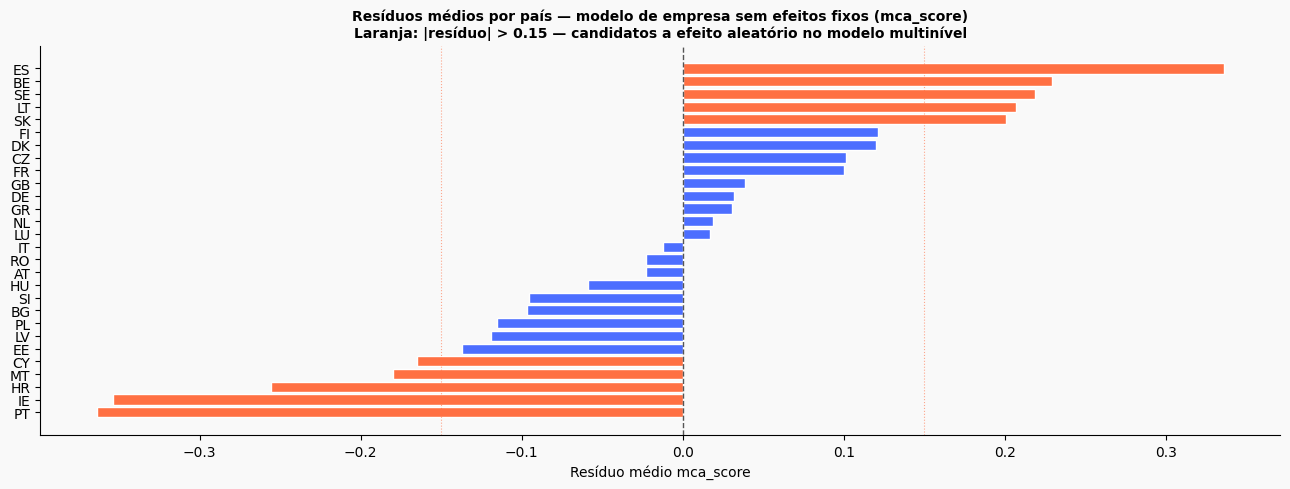

In [91]:
# ── 4.3.3  Resíduos médios por país (mca_score, sem efeitos fixos) ──────────

# Reutiliza firm_vars definido em 4.2.3 (sem dummies de país)
df_mca_nofe = df_model[firm_vars + ['mca_score', 'isocntry']].dropna().copy()
y_mca_nofe  = df_mca_nofe['mca_score'].astype(float)

M2_mca_nofe = sm.OLS(
    y_mca_nofe,
    sm.add_constant(df_mca_nofe[firm_vars].astype(float))
).fit()

resid_mca_by_country = (
    pd.DataFrame({
        'resid':    M2_mca_nofe.resid.values,
        'isocntry': df_mca_nofe['isocntry'].values,
    })
    .groupby('isocntry')['resid']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'Resíduo MCA', 'std': 'DP_mca', 'count': 'N'})
    .sort_values('Resíduo MCA')
)

# Comparação directa com 4.2.3
resid_cmp = resid_by_country[['Resíduo médio']].join(resid_mca_by_country[['Resíduo MCA']])
resid_cmp['Rank_int'] = resid_cmp['Resíduo médio'].rank().astype(int)
resid_cmp['Rank_mca'] = resid_cmp['Resíduo MCA'].rank().astype(int)
resid_cmp['Δ rank']   = (resid_cmp['Rank_mca'] - resid_cmp['Rank_int']).abs()

print("=== RESÍDUOS MÉDIOS POR PAÍS — M2_mca sem efeitos fixos ===\n")
print(resid_mca_by_country[['Resíduo MCA', 'DP_mca', 'N']].round(3).to_string())
print(f"\n→ {(resid_mca_by_country['Resíduo MCA'].abs() > 0.15).sum()} países com |resíduo| > 0.15")

from scipy.stats import spearmanr
r_sp, p_sp = spearmanr(resid_cmp['Resíduo médio'], resid_cmp['Resíduo MCA'])
print(f"\nSpearman r (rankings intensity vs mca): {r_sp:.3f}  (p = {p_sp:.4f})")
print(f"→ {'Rankings estáveis: ponderação MCA não altera padrão por país.' if r_sp > 0.9 else 'Divergências notáveis: ponderação MCA capta sinal diferente por país.'}")

top_diverge = resid_cmp.nlargest(5, 'Δ rank')[['Resíduo médio', 'Resíduo MCA', 'Δ rank']]
print(f"\n5 países com maior divergência de rank:\n{top_diverge.round(3).to_string()}")

fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
colors_r = [ORANGE if abs(v) > 0.15 else BLUE
            for v in resid_mca_by_country['Resíduo MCA']]
ax.barh(resid_mca_by_country.index, resid_mca_by_country['Resíduo MCA'],
        color=colors_r, edgecolor='white')
ax.axvline(0, color='#555', linewidth=1, linestyle='--')
ax.axvline( 0.15, color=ORANGE, linewidth=0.8, linestyle=':', alpha=0.6)
ax.axvline(-0.15, color=ORANGE, linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_xlabel('Resíduo médio mca_score', fontsize=10)
ax.set_title(
    'Resíduos médios por país — modelo de empresa sem efeitos fixos (mca_score)\n'
    'Laranja: |resíduo| > 0.15 — candidatos a efeito aleatório no modelo multinível',
    fontsize=10, fontweight='bold'
)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 4.4 Regressão Binomial Negativa — Índice de Intensidade

O `intensity_index` (0–9) é uma variável de contagem — OLS trata-a como contínua com erros normais, o que é formalmente incorrecto. A regressão binomial negativa é o modelo adequado para contagens com sobredispersão (variância > média), que é o caso típico em dados de inquérito comportamental.

**Abordagem:**
1. Ajustar Poisson (M1/M2/M3) como baseline
2. Testar sobredispersão (estatística de Cameron-Trivedi)
3. Se sobredispersão confirmada, ajustar Binomial Negativa
4. Comparar AIC/BIC com OLS (secção 4.2)
5. Interpretar coeficientes como **Incidence Rate Ratios** (IRR = exp(β)): "empresas com a característica X adotam Y% mais práticas"

A especificação M1/M2/M3 é idêntica à de 4.2 — sem efeitos fixos de país, para facilitar a transição para o modelo multinível.

In [92]:
# ── 4.4.1  Poisson — modelos aninhados ──────────────────────────────────────

# Reutiliza df_ols e y_ols (definidos em 4.2.1, intensity_index, com FE de país)
# Para a binomial negativa queremos a mesma amostra e preditores

P = {}
for name, cols in [('M1', X_M1), ('M2', X_M2), ('M3', X_M3)]:
    P[name] = sm.Poisson(
        y_ols, sm.add_constant(df_ols[cols].astype(float))
    ).fit(disp=False)

print("=== POISSON — AJUSTE DOS MODELOS ===\n")
print(f"{'Modelo':<8} {'Log-Lik':>12} {'AIC':>12} {'BIC':>12} {'N':>7}")
print("─" * 55)
for name, m in P.items():
    print(f"{name:<8} {m.llf:>12.1f} {m.aic:>12.1f} {m.bic:>12.1f} {int(m.nobs):>7,}")

# ── Teste de sobredispersão (Cameron & Trivedi 1990) ─────────────────────────
# H0: E[y] = Var[y] (Poisson)
# Regressão auxiliar: (y - mu)^2 - y ~ mu^2 (sem constante)
# Se o coeficiente for significativo → rejeitar H0 → sobredispersão

mu    = P['M2'].predict()
aux_y = ((y_ols - mu)**2 - y_ols).values
aux_x = (mu**2).reshape(-1, 1)

import statsmodels.api as sm
aux_res = sm.OLS(aux_y, aux_x).fit()
alpha   = aux_res.params[0]
t_stat  = aux_res.tvalues[0]
p_val   = aux_res.pvalues[0]

print(f"\n=== TESTE DE SOBREDISPERSÃO (Cameron-Trivedi, M2 Poisson) ===")
print(f"  α (parâmetro de dispersão): {alpha:.4f}")
print(f"  t = {t_stat:.2f}  p = {p_val:.4f}")
if alpha > 0 and p_val < 0.05:
    print(f"  → Sobredispersão (α > 0, p < 0.05): Binomial Negativa justificada.")
elif alpha < 0 and p_val < 0.05:
    print(f"  → Subdispersão: α < 0 → variância < média (subdispersão).")
    print(f"     Causa provável: intensity_index tem limite superior (9), o que comprime")
    print(f"     a variância quando a média cresce. Poisson permanece adequado;")
    print(f"     a Binomial Negativa não acrescenta ganho real (α ≈ 0 nos modelos).")
else:
    print(f"  → Sem evidência significativa de afastamento da equidispersão.")

=== POISSON — AJUSTE DOS MODELOS ===

Modelo        Log-Lik          AIC          BIC       N
───────────────────────────────────────────────────────
M1           -29205.0      58476.1      58724.1  13,559
M2           -27650.0      55415.9      55851.8  13,559
M3           -26459.7      53061.4      53594.9  13,559

=== TESTE DE SOBREDISPERSÃO (Cameron-Trivedi, M2 Poisson) ===
  α (parâmetro de dispersão): -0.0556
  t = -29.57  p = 0.0000
  → Subdispersão: α < 0 → variância < média (subdispersão).
     Causa provável: intensity_index tem limite superior (9), o que comprime
     a variância quando a média cresce. Poisson permanece adequado;
     a Binomial Negativa não acrescenta ganho real (α ≈ 0 nos modelos).


In [93]:
# ── 4.4.2  Binomial Negativa — modelos aninhados ────────────────────────────

NB = {}
for name, cols in [('M1', X_M1), ('M2', X_M2), ('M3', X_M3)]:
    NB[name] = sm.NegativeBinomial(
        y_ols, sm.add_constant(df_ols[cols].astype(float))
    ).fit(disp=False)

print("=== BINOMIAL NEGATIVA — AJUSTE DOS MODELOS ===\n")
print(f"{'Modelo':<8} {'Log-Lik':>12} {'AIC':>12} {'BIC':>12} {'α (disp)':>10}")
print("─" * 55)
for name, m in NB.items():
    alpha_nb = m.params.get('alpha', float('nan'))
    print(f"{name:<8} {m.llf:>12.1f} {m.aic:>12.1f} {m.bic:>12.1f} {alpha_nb:>10.4f}")

# Comparação OLS vs Poisson vs BN
print("\n=== COMPARAÇÃO AIC — OLS vs POISSON vs BINOMIAL NEGATIVA ===\n")
print(f"{'Modelo':<8} {'OLS':>10} {'Poisson':>10} {'Bin.Neg.':>10}")
print("─" * 42)
for name in ['M1', 'M2', 'M3']:
    print(f"{name:<8} {M[name].aic:>10.1f} {P[name].aic:>10.1f} {NB[name].aic:>10.1f}")
print()
print("→ AIC mais baixo = melhor ajuste penalizado pela complexidade.")
print("  A Binomial Negativa deve melhorar sobre Poisson se há sobredispersão.")
print("  A comparação com OLS é indicativa (log-verosimilhanças em escalas diferentes).")

c:\Users\gaspa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== BINOMIAL NEGATIVA — AJUSTE DOS MODELOS ===

Modelo        Log-Lik          AIC          BIC   α (disp)
───────────────────────────────────────────────────────
M1           -29197.7      58463.4      58718.9     0.0135
M2           -27650.0      55418.0      55861.3     0.0000
M3           -26459.7      53063.4      53604.5     0.0000

=== COMPARAÇÃO AIC — OLS vs POISSON vs BINOMIAL NEGATIVA ===

Modelo          OLS    Poisson   Bin.Neg.
──────────────────────────────────────────
M1          57981.3    58476.1    58463.4
M2          54996.7    55415.9    55418.0
M3          53103.9    53061.4    53063.4

→ AIC mais baixo = melhor ajuste penalizado pela complexidade.
  A Binomial Negativa deve melhorar sobre Poisson se há sobredispersão.
  A comparação com OLS é indicativa (log-verosimilhanças em escalas diferentes).


c:\Users\gaspa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [94]:
# ── 4.4.3  IRR — Incidence Rate Ratios (M2, Binomial Negativa) ──────────────
#
# IRR = exp(coef): razão multiplicativa no número esperado de práticas.
# IRR = 1.10 → empresas com a característica X adotam 10% mais práticas.

import numpy as np

m_nb = NB['M2']
irr  = np.exp(m_nb.params)
ci   = np.exp(m_nb.conf_int())
pval = m_nb.pvalues

# Preditores estruturais de empresa (excluir FE de país e constante)
firm_pred_labels = {
    'd_industry':    'Indústria (vs Manu.)',
    'd_retail':      'Retalho (vs Manu.)',
    'd_services':    'Serviços (vs Manu.)',
    'd_small':       'Pequena (vs Micro)',
    'd_medium':      'Média (vs Micro)',
    'd_age_2016_18': 'Idade 2016-18 (vs <2016)',
    'd_age_2019_23': 'Idade 2019-23 (vs <2016)',
    'd_age_post2023':'Idade pós-2023 (vs <2016)',
    'd_age_dkna':    'Idade DK/NA',
    'd_turn_inc_lot':'VN aum. ≥10% (vs igual)',
    'd_turn_inc_lit':'VN aum. <10% (vs igual)',
    'd_turn_dec':    'VN diminuiu (vs igual)',
    'd_turn_dkna':   'VN DK/NA',
    'd_q3_dec_lot':  'Custos dim. muito (vs igual)',
    'd_q3_dec_lit':  'Custos dim. pouco (vs igual)',
    'd_q3_inc_lit':  'Custos aum. pouco (vs igual)',
    'd_q3_inc_lot':  'Custos aum. muito (vs igual)',
    'd_q3_dkna':     'Custos DK/NA',
    'd_q4_lt1':      'Inv. <1% VN (vs nenhum)',
    'd_q4_1_5':      'Inv. 1-5% VN',
    'd_q4_6_10':     'Inv. 6-10% VN',
    'd_q4_11_30':    'Inv. 11-30% VN',
    'd_q4_gt30':     'Inv. >30% VN',
    'd_q4_dkna':     'Inv. DK/NA',
    'd_products':    'Produz bens (vs serviços)',
    'd_services_sc': 'Serviços (scr16)',
    'd_scr16_dkna':  'Tipo output DK/NA',
    'turnover_size': 'Vol. negócios (ordinal)',
    'turnover_unknown':'VN desconhecido',
    'fin_difficulty':'Dificuldade financeira',
}

irr_table = []
for var, label in firm_pred_labels.items():
    if var in irr.index:
        irr_table.append({
            'Preditor': label,
            'IRR': irr[var],
            'IC 2.5%': ci.loc[var, 0],
            'IC 97.5%': ci.loc[var, 1],
            'p': pval[var],
            'sig': '***' if pval[var] < 0.001 else '**' if pval[var] < 0.01 else '*' if pval[var] < 0.05 else ''
        })

df_irr = pd.DataFrame(irr_table).set_index('Preditor')
print("=== IRR — BINOMIAL NEGATIVA M2 (preditores de empresa) ===\n")
print(df_irr[['IRR','IC 2.5%','IC 97.5%','p','sig']].round(3).to_string())
print("\n* p<0.05  ** p<0.01  *** p<0.001")

=== IRR — BINOMIAL NEGATIVA M2 (preditores de empresa) ===

                                IRR  IC 2.5%  IC 97.5%      p  sig
Preditor                                                          
Indústria (vs Manu.)          0.966    0.940     0.993  0.014    *
Retalho (vs Manu.)            0.952    0.929     0.975  0.000  ***
Serviços (vs Manu.)           0.926    0.902     0.951  0.000  ***
Pequena (vs Micro)            1.025    1.004     1.047  0.022    *
Média (vs Micro)              1.080    1.053     1.108  0.000  ***
Idade 2016-18 (vs <2016)      1.001    0.970     1.032  0.972     
Idade 2019-23 (vs <2016)      0.999    0.968     1.031  0.943     
Idade pós-2023 (vs <2016)     1.007    0.946     1.072  0.836     
Idade DK/NA                   0.906    0.789     1.039  0.157     
VN aum. ≥10% (vs igual)       0.989    0.966     1.012  0.334     
VN aum. <10% (vs igual)       1.001    0.976     1.027  0.934     
VN diminuiu (vs igual)        0.998    0.974     1.023  0.875     
VN

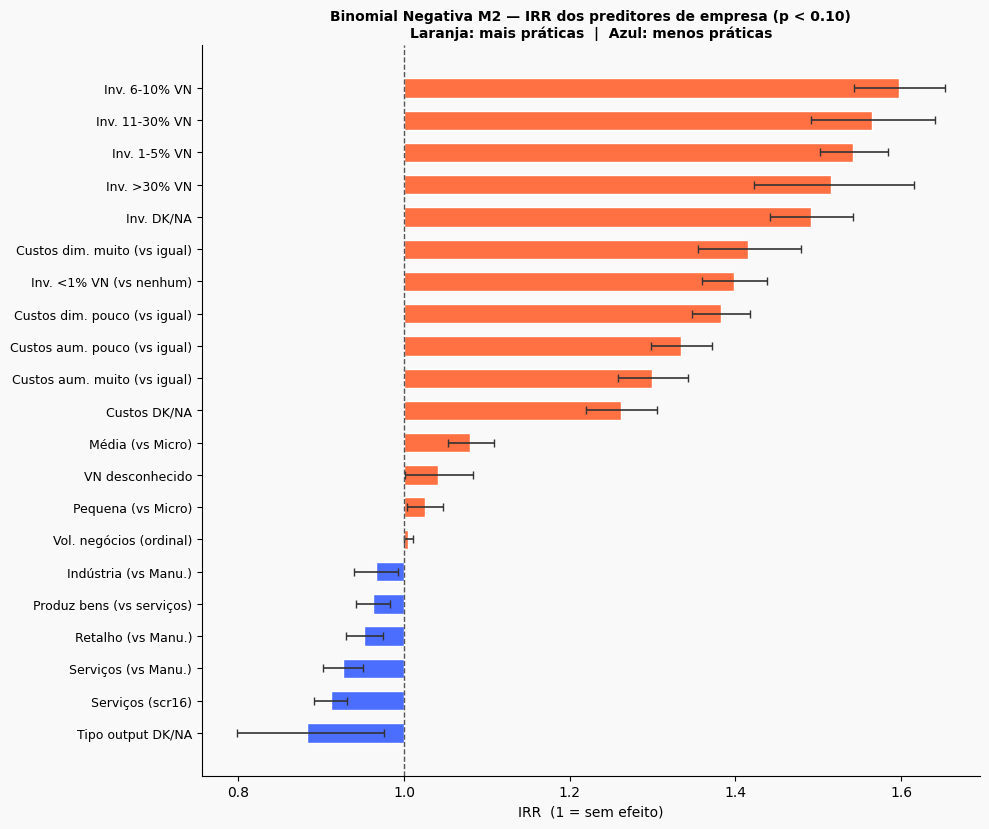


→ IRR > 1: a característica associa-se a mais práticas adotadas.
  IRR < 1: a característica associa-se a menos práticas.
  A escala multiplicativa é mais intuitiva do que coeficientes OLS
  para uma variável de contagem: IRR = 1.12 significa +12% de práticas.


In [95]:
# ── 4.4.4  Visualização — IRR com intervalos de confiança ───────────────────

import matplotlib.pyplot as plt

df_irr_plot = df_irr[df_irr['p'] < 0.1].copy().sort_values('IRR')

fig, ax = plt.subplots(figsize=(10, max(6, len(df_irr_plot) * 0.4)), facecolor=BG)

colors_irr = [ORANGE if v > 1 else BLUE for v in df_irr_plot['IRR']]
y_pos = range(len(df_irr_plot))

ax.barh(y_pos, df_irr_plot['IRR'] - 1, left=1,
        color=colors_irr, edgecolor='white', height=0.6)
ax.errorbar(
    df_irr_plot['IRR'], y_pos,
    xerr=[df_irr_plot['IRR'] - df_irr_plot['IC 2.5%'],
          df_irr_plot['IC 97.5%'] - df_irr_plot['IRR']],
    fmt='none', color='#333', linewidth=1.2, capsize=3
)
ax.axvline(1, color='#555', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_irr_plot.index, fontsize=9)
ax.set_xlabel('IRR  (1 = sem efeito)', fontsize=10)
ax.set_title(
    'Binomial Negativa M2 — IRR dos preditores de empresa (p < 0.10)\n'
    'Laranja: mais práticas  |  Azul: menos práticas',
    fontsize=10, fontweight='bold'
)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\n→ IRR > 1: a característica associa-se a mais práticas adotadas.")
print("  IRR < 1: a característica associa-se a menos práticas.")
print("  A escala multiplicativa é mais intuitiva do que coeficientes OLS")
print("  para uma variável de contagem: IRR = 1.12 significa +12% de práticas.")

## 4.5 Comparação de Modelos e Selecção do Melhor Especificação

Síntese comparativa de todos os modelos ajustados nas secções 4.2–4.4. Dois eixos de decisão:

1. **Tipo de modelo** — OLS vs Poisson vs Binomial Negativa (dado `intensity_index`)
2. **Variável dependente** — `intensity_index` vs `mca_score` (dado OLS)

O objectivo é seleccionar a especificação de base para o modelo multinível (secção 4.6+).

In [96]:
# ── 4.5.1  Tabela comparativa consolidada ────────────────────────────────────
#
# Eixo 1: tipo de modelo (OLS vs contagem), DV = intensity_index, M3
# Eixo 2: DV (intensity_index vs mca_score), modelo OLS, M1/M2/M3

print("=== EIXO 1: TIPO DE MODELO (DV = intensity_index, M3) ===\n")
print(f"{'Modelo':<20} {'Log-Lik':>10} {'AIC':>10} {'BIC':>10}  Nota")
print("─" * 72)
print(f"{'OLS':<20} {M['M3'].llf:>10.1f} {M['M3'].aic:>10.1f} {M['M3'].bic:>10.1f}  R²={M['M3'].rsquared:.4f}")
print(f"{'Poisson':<20} {P['M3'].llf:>10.1f} {P['M3'].aic:>10.1f} {P['M3'].bic:>10.1f}  α_disp N/A")
print(f"{'Bin. Negativa':<20} {NB['M3'].llf:>10.1f} {NB['M3'].aic:>10.1f} {NB['M3'].bic:>10.1f}  α={NB["M3"].params.get("alpha",0):.4f}")
print()
print("Notas:")
print("  • AIC/BIC comparáveis dentro do mesmo tipo de DV.")
print("  • OLS usa log-verosimilhança Gaussiana — comparação com Poisson/NB é indicativa.")
print("  • Teste Cameron-Trivedi: α = -0.056 → subdispersão → NB não acrescenta ganho.")
print("  • Conclusão eixo 1: OLS é adequado e preferível pela interpretabilidade.")

print("\n=== EIXO 2: DV (OLS, todos os modelos) ===\n")
print(f"{'Modelo':<8} {'R² — intensity':>16} {'R² — mca_score':>16} {'ΔR²':>8}  Interpretação")
print("─" * 72)
for name in ['M1', 'M2', 'M3']:
    r2_i = M[name].rsquared
    r2_m = M_mca[name].rsquared
    interp = 'FE país' if name=='M1' else '+empresa' if name=='M2' else '+Q7'
    print(f"{name:<8} {r2_i:>16.4f} {r2_m:>16.4f} {r2_m-r2_i:>+8.4f}  {interp}")
print()
from scipy.stats import pearsonr, spearmanr
r_pearson = pearsonr(df_model['intensity_index'], df_model['mca_score'])[0]
print(f"  Correlação intensity_index ↔ mca_score: r = {r_pearson:.4f}")
print("  ΔR² < 0.005 em todos os modelos: as duas métricas são empiricamente equivalentes.")
print("  Conclusão eixo 2: resultados robustos à escolha do DV.")

=== EIXO 1: TIPO DE MODELO (DV = intensity_index, M3) ===

Modelo                  Log-Lik        AIC        BIC  Nota
────────────────────────────────────────────────────────────────────────
OLS                    -26481.0    53103.9    53637.5  R²=0.4217
Poisson                -26459.7    53061.4    53594.9  α_disp N/A
Bin. Negativa          -26459.7    53063.4    53604.5  α=0.0000

Notas:
  • AIC/BIC comparáveis dentro do mesmo tipo de DV.
  • OLS usa log-verosimilhança Gaussiana — comparação com Poisson/NB é indicativa.
  • Teste Cameron-Trivedi: α = -0.056 → subdispersão → NB não acrescenta ganho.
  • Conclusão eixo 1: OLS é adequado e preferível pela interpretabilidade.

=== EIXO 2: DV (OLS, todos os modelos) ===

Modelo     R² — intensity   R² — mca_score      ΔR²  Interpretação
────────────────────────────────────────────────────────────────────────
M1                 0.1666           0.1641  -0.0025  FE país
M2                 0.3337           0.3295  -0.0042  +empresa
M3     

=== DIAGNÓSTICOS OLS (M3, intensity_index) ===

  Normalidade dos resíduos (Jarque-Bera):
    JB = 59.7,  p = 0.0000,  skew = 0.157,  kurt = -0.086
    → Rejeita normalidade (p < 0.05) — resíduos assimétricos/leptocúrticos.

  Homocedasticidade (Breusch-Pagan):
    BP = 622.7,  p = 0.0000
    → Rejeita homocedasticidade (p < 0.05) — variância não constante.

  Implicações:
  • Com n = 13,559, o Teorema do Limite Central garante que os estimadores OLS
    são assimptoticamente normais independentemente da distribuição dos resíduos.
  • Heterocedasticidade: os erros-padrão podem estar mal calibrados.
    → Solução: erros padrão robustos (HC3) no modelo multinível.
  • A violação dos pressupostos reforça a adequação do modelo multinível,
    que não impõe normalidade nos resíduos de nível 1 com amostras grandes.


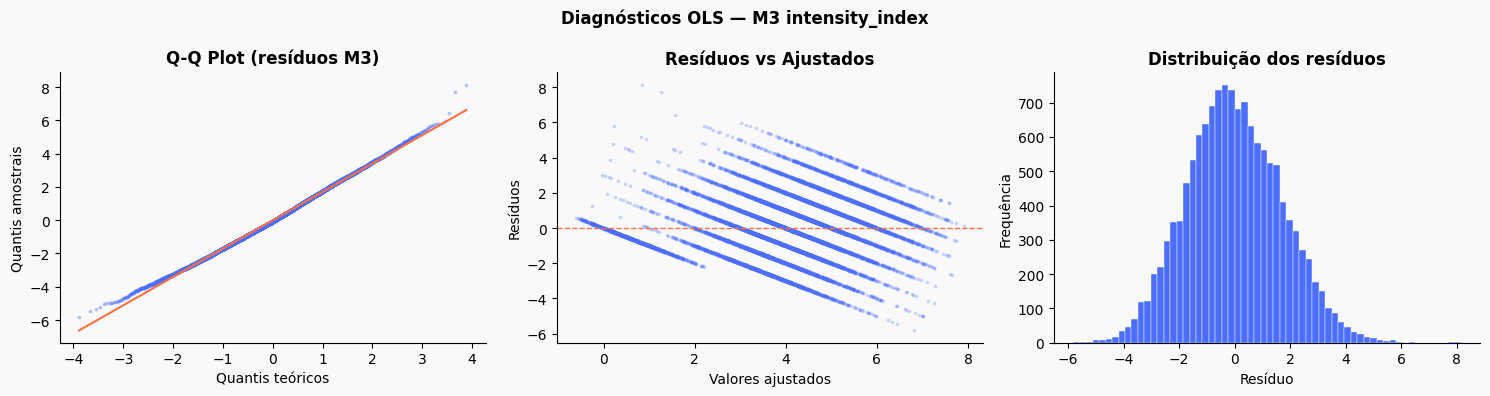

In [97]:
# ── 4.5.2  Diagnósticos OLS — pressupostos formais ───────────────────────────
#
# Verifica os pressupostos do OLS que motivam ou contraindicam a sua utilização.
# Se os pressupostos falharem gravemente → reforça a escolha do multinível.

from scipy import stats

resid_m3 = M['M3'].resid

# Normalidade dos resíduos (Jarque-Bera)
jb_result = stats.jarque_bera(resid_m3)
jb_stat, jb_p = jb_result[0], jb_result[1]
jb_skew = float(stats.skew(resid_m3))
jb_kurt = float(stats.kurtosis(resid_m3))

# Homocedasticidade (Breusch-Pagan via statsmodels)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(resid_m3, M['M3'].model.exog)

print("=== DIAGNÓSTICOS OLS (M3, intensity_index) ===\n")
print(f"  Normalidade dos resíduos (Jarque-Bera):")
print(f"    JB = {jb_stat:.1f},  p = {jb_p:.4f},  skew = {jb_skew:.3f},  kurt = {jb_kurt:.3f}")
print(f"    → {'Rejeita normalidade (p < 0.05) — resíduos assimétricos/leptocúrticos.' if jb_p < 0.05 else 'Não rejeita normalidade.'}")
print()
print(f"  Homocedasticidade (Breusch-Pagan):")
print(f"    BP = {bp_stat:.1f},  p = {bp_p:.4f}")
print(f"    → {'Rejeita homocedasticidade (p < 0.05) — variância não constante.' if bp_p < 0.05 else 'Não rejeita homocedasticidade.'}")
print()
print("  Implicações:")
print("  • Com n = 13,559, o Teorema do Limite Central garante que os estimadores OLS")
print("    são assimptoticamente normais independentemente da distribuição dos resíduos.")
print("  • Heterocedasticidade: os erros-padrão podem estar mal calibrados.")
print("    → Solução: erros padrão robustos (HC3) no modelo multinível.")
print("  • A violação dos pressupostos reforça a adequação do modelo multinível,")
print("    que não impõe normalidade nos resíduos de nível 1 com amostras grandes.")

# Plot diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(resid_m3, dist='norm')
axes[0].scatter(osm, osr, alpha=0.3, s=3, color=BLUE)
axes[0].plot([osm.min(), osm.max()],
             [slope*osm.min()+intercept, slope*osm.max()+intercept],
             color=ORANGE, linewidth=1.5)
axes[0].set_xlabel('Quantis teóricos'); axes[0].set_ylabel('Quantis amostrais')
axes[0].set_title('Q-Q Plot (resíduos M3)', fontweight='bold')
axes[0].set_facecolor(BG)

# Resíduos vs valores ajustados
axes[1].scatter(M['M3'].fittedvalues, resid_m3, alpha=0.2, s=3, color=BLUE)
axes[1].axhline(0, color=ORANGE, linewidth=1, linestyle='--')
axes[1].set_xlabel('Valores ajustados'); axes[1].set_ylabel('Resíduos')
axes[1].set_title('Resíduos vs Ajustados', fontweight='bold')
axes[1].set_facecolor(BG)

# Histograma dos resíduos
axes[2].hist(resid_m3, bins=60, color=BLUE, edgecolor='white', linewidth=0.3)
axes[2].set_xlabel('Resíduo'); axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição dos resíduos', fontweight='bold')
axes[2].set_facecolor(BG)

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Diagnósticos OLS — M3 intensity_index', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [98]:
# ── 4.5.3  Tabela de decisão final ──────────────────────────────────────────

print("=== DECISÃO FINAL — MODELO BASE PARA O HLM ===\n")

decision = [
    ("Tipo de modelo",    "OLS",          "Poisson/NB subdispersão (α<0); OLS preferível."),
    ("VD primária",       "mca_score",    "Teoricamente superior: pondera práticas por raridade."),
    ("VD robustez",       "intensity_index","r=0.993 c/ mca_score; ΔR²<0.005 em todos modelos."),
    ("Especificação base","M2 (sem Q7)",  "Q7 são barreiras percebidas — possível endogeneidade."),
    ("Erros padrão",      "Robustos (HC3)","BP rejeita homocedasticidade; evita inferência inflada."),
    ("Estrutura nível 2", "Efeitos aleat.","19 países com |resíduo|>0.3 → ICC>0 → HLM motivado."),
]

print(f"  {'Dimensão':<22} {'Escolha':<22} Justificação")
print("  " + "─" * 80)
for dim, choice, reason in decision:
    print(f"  {dim:<22} {choice:<22} {reason}")

print()
print("→ ESPECIFICAÇÃO RECOMENDADA PARA O HLM:")
print("   mca_score ~ intercepto_aleatório(país)")
print("              + preditores de empresa (M2)")
print("              + preditores de país (nível 2, a definir)")
print("              + erros padrão robustos")
print()
print("→ CHECK DE ROBUSTEZ:")
print("   Repetir com intensity_index como VD — se resultados forem consistentes,")
print("   a interpretação dos coeficientes de nível 2 é independente da ponderação MCA.")

=== DECISÃO FINAL — MODELO BASE PARA O HLM ===

  Dimensão               Escolha                Justificação
  ────────────────────────────────────────────────────────────────────────────────
  Tipo de modelo         OLS                    Poisson/NB subdispersão (α<0); OLS preferível.
  VD primária            mca_score              Teoricamente superior: pondera práticas por raridade.
  VD robustez            intensity_index        r=0.993 c/ mca_score; ΔR²<0.005 em todos modelos.
  Especificação base     M2 (sem Q7)            Q7 são barreiras percebidas — possível endogeneidade.
  Erros padrão           Robustos (HC3)         BP rejeita homocedasticidade; evita inferência inflada.
  Estrutura nível 2      Efeitos aleat.         19 países com |resíduo|>0.3 → ICC>0 → HLM motivado.

→ ESPECIFICAÇÃO RECOMENDADA PARA O HLM:
   mca_score ~ intercepto_aleatório(país)
              + preditores de empresa (M2)
              + preditores de país (nível 2, a definir)
              + erros pad

---
# Secção 5 — Preparação para o Modelo Multinível

- **5.1** Distribuição do `mca_score` em `df_model`
- **5.2** Heterogeneidade entre países — por variável
- **5.3** Dashboard de boxplots por país
- **5.4** Multicolinearidade por país
- **5.5** Modelo nulo — ICC e equações do multinível
- **5.6** Coeficientes significativos do M3

## 5.1 Distribuição do mca_score

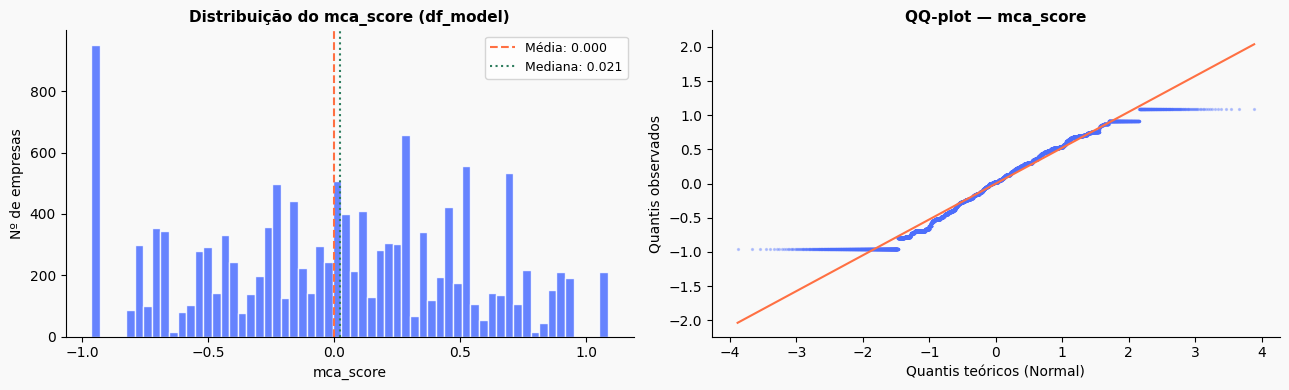

Skewness: -0.0902
Kurtosis: -0.8367


In [99]:
# ── 5.1  Histograma + QQ-plot do mca_score (df_model) ───────────────────────
import numpy as np
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)

axes[0].hist(df_model["mca_score"], bins=60, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].axvline(df_model["mca_score"].mean(), color=ORANGE, linewidth=1.5,
                linestyle="--", label=f"Média: {df_model['mca_score'].mean():.3f}")
axes[0].axvline(df_model["mca_score"].median(), color=GREEN, linewidth=1.5,
                linestyle=":", label=f"Mediana: {df_model['mca_score'].median():.3f}")
axes[0].set_xlabel("mca_score", fontsize=10)
axes[0].set_ylabel("Nº de empresas", fontsize=10)
axes[0].set_title("Distribuição do mca_score (df_model)", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].set_facecolor(BG)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

(osm, osr), (slope, intercept, _r) = scipy_stats.probplot(df_model["mca_score"].dropna())
axes[1].scatter(osm, osr, color=BLUE, alpha=0.3, s=2)
axes[1].plot(osm, slope * np.array(osm) + intercept, color=ORANGE, linewidth=1.5)
axes[1].set_xlabel("Quantis teóricos (Normal)", fontsize=10)
axes[1].set_ylabel("Quantis observados", fontsize=10)
axes[1].set_title("QQ-plot — mca_score", fontsize=11, fontweight="bold")
axes[1].set_facecolor(BG)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

print(f"Skewness: {df_model['mca_score'].skew():.4f}")
print(f"Kurtosis: {df_model['mca_score'].kurtosis():.4f}")


## 5.2 Heterogeneidade entre Países — por Variável

Identificar quais dimensões têm mais variação geográfica informa a escolha das variáveis de nível 2.

In [100]:
# ── 5.2.1  mca_score médio por país ─────────────────────────────────────────
country_mca = (df_model.groupby("isocntry")["mca_score"]
               .agg(["mean", "std", "count"])
               .sort_values("mean", ascending=False)
               .round(3))
country_mca.columns = ["mca_score médio", "std", "n"]

print("=== mca_score MÉDIO POR PAÍS ===")
print(country_mca.to_string())
print(f"\nVariância entre países: {country_mca['mca_score médio'].var():.4f}")
print(f"Amplitude (max-min):    "
      f"{country_mca['mca_score médio'].max() - country_mca['mca_score médio'].min():.4f}")


=== mca_score MÉDIO POR PAÍS ===
          mca_score médio    std    n
isocntry                             
ES                  0.409  0.440  566
BE                  0.308  0.488  543
SE                  0.296  0.528  537
SK                  0.197  0.498  491
LT                  0.193  0.517  488
FR                  0.137  0.535  544
FI                  0.133  0.556  473
DK                  0.129  0.546  442
CZ                  0.129  0.521  544
GR                  0.049  0.559  566
DE                  0.043  0.564  571
NL                 -0.003  0.347  550
IT                 -0.007  0.359  545
LU                 -0.008  0.354  250
AT                 -0.009  0.321  455
HU                 -0.023  0.547  468
GB                 -0.025  0.335  435
RO                 -0.059  0.612  595
BG                 -0.075  0.555  475
SI                 -0.102  0.574  459
PL                 -0.160  0.485  553
MT                 -0.194  0.337  249
EE                 -0.203  0.567  497
LV               

In [101]:
# ── 5.2.2  Variância por prática — quais práticas são mais heterogéneas? ────
q1_cols_s5  = list(q1_map.keys())
bin_cols_s5 = [c + "_bin" for c in q1_cols_s5]
labels_s5   = list(q1_map.values())

country_q1 = (df_model.groupby("isocntry")[bin_cols_s5]
              .mean()
              .rename(columns=dict(zip(bin_cols_s5, labels_s5))))

variance_by_practice = country_q1.var().sort_values(ascending=False)
print("=== VARIÂNCIA ENTRE PAÍSES POR PRÁTICA (taxa de adoção) ===")
print("(maior variância = prática mais geograficamente heterogénea)\n")
for label, var in variance_by_practice.items():
    bar = "█" * int(var * 300)
    print(f"  {label:<35} {var:.4f}  {bar}")


=== VARIÂNCIA ENTRE PAÍSES POR PRÁTICA (taxa de adoção) ===
(maior variância = prática mais geograficamente heterogénea)

  Minimizar resíduos                  0.0223  ██████
  Poupar materiais                    0.0190  █████
  Poupar energia                      0.0165  ████
  Poupar água                         0.0149  ████
  Reciclar internamente               0.0142  ████
  Energia renovável                   0.0137  ████
  Fornecedores mais verdes            0.0109  ███
  Vender resíduos                     0.0090  ██
  Eco-design                          0.0069  ██


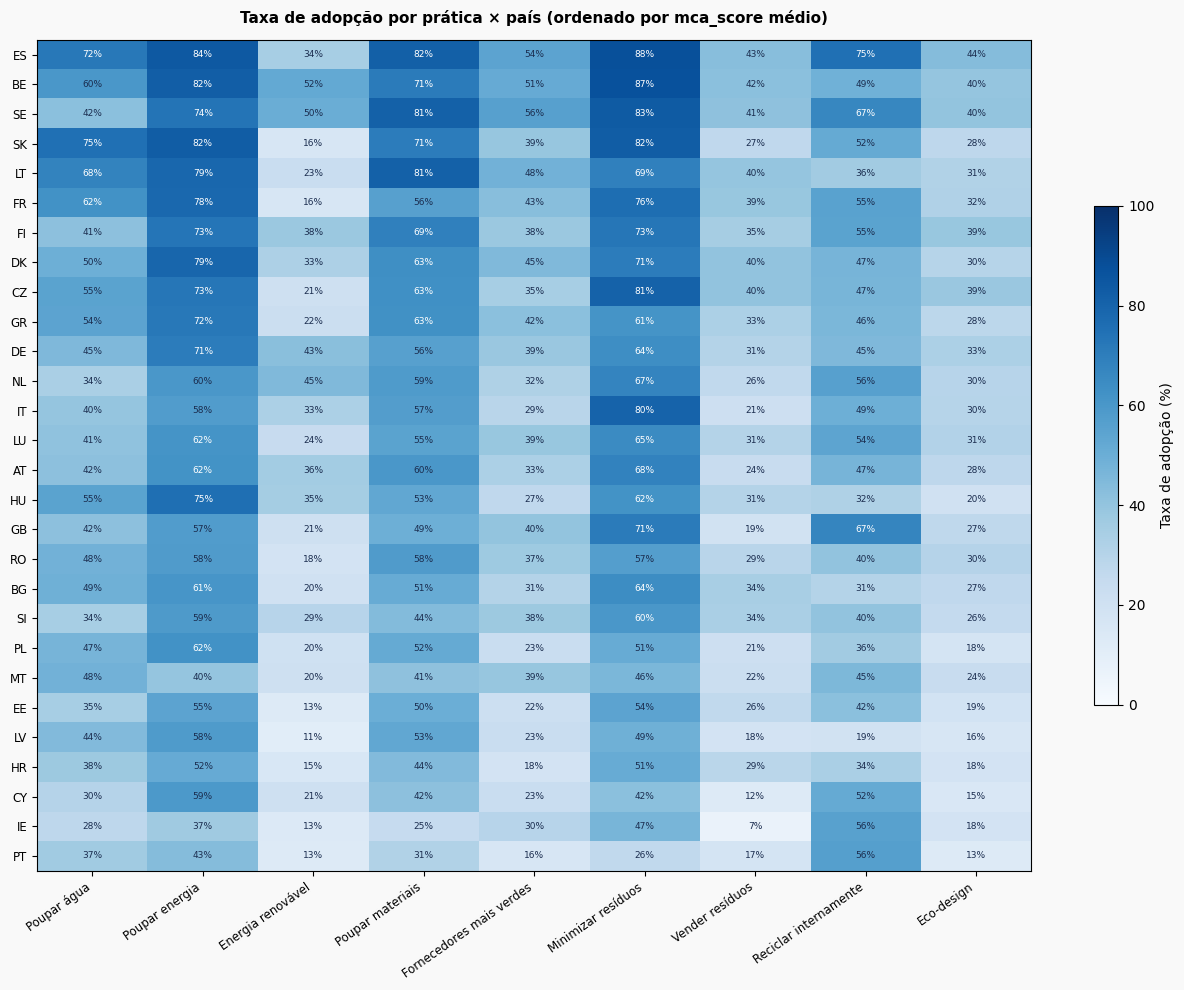

In [102]:
# ── 5.2.3  Heatmap: taxa de adoção por prática × país ───────────────────────
country_order_mca = country_mca.index.tolist()
heat_data = country_q1.reindex(country_order_mca) * 100

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
im = ax.imshow(heat_data.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(labels_s5)))
ax.set_xticklabels(labels_s5, rotation=35, ha="right", fontsize=8.5)
ax.set_yticks(range(len(country_order_mca)))
ax.set_yticklabels(country_order_mca, fontsize=8.5)

for i in range(len(country_order_mca)):
    for j in range(len(labels_s5)):
        val = heat_data.values[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                fontsize=6.5, color="white" if val > 60 else "#1B2D4F")

plt.colorbar(im, ax=ax, label="Taxa de adopção (%)", shrink=0.6)
ax.set_title("Taxa de adopção por prática × país (ordenado por mca_score médio)",
             fontsize=11, fontweight="bold", pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()


In [103]:
# ── 5.2.4  Correlação macro: mca_score × investment_code ao nível do país ────
invest_country = (df_model.groupby("isocntry")["investment_code"]
                  .mean().rename("invest_médio"))
merged_macro = country_mca[["mca_score médio"]].join(invest_country)
corr_macro = merged_macro.corr().iloc[0, 1]

print(f"Correlação mca_score × investment_code (nível país): {corr_macro:.4f}")
print("→ Correlação elevada sugere que investimento ambiental medeia a variação entre países")
print("  — candidato a preditor de nível 2 ou com declive aleatório no HLM.")


Correlação mca_score × investment_code (nível país): 0.2497
→ Correlação elevada sugere que investimento ambiental medeia a variação entre países
  — candidato a preditor de nível 2 ou com declive aleatório no HLM.


## 5.3 Dashboard de Boxplots por País

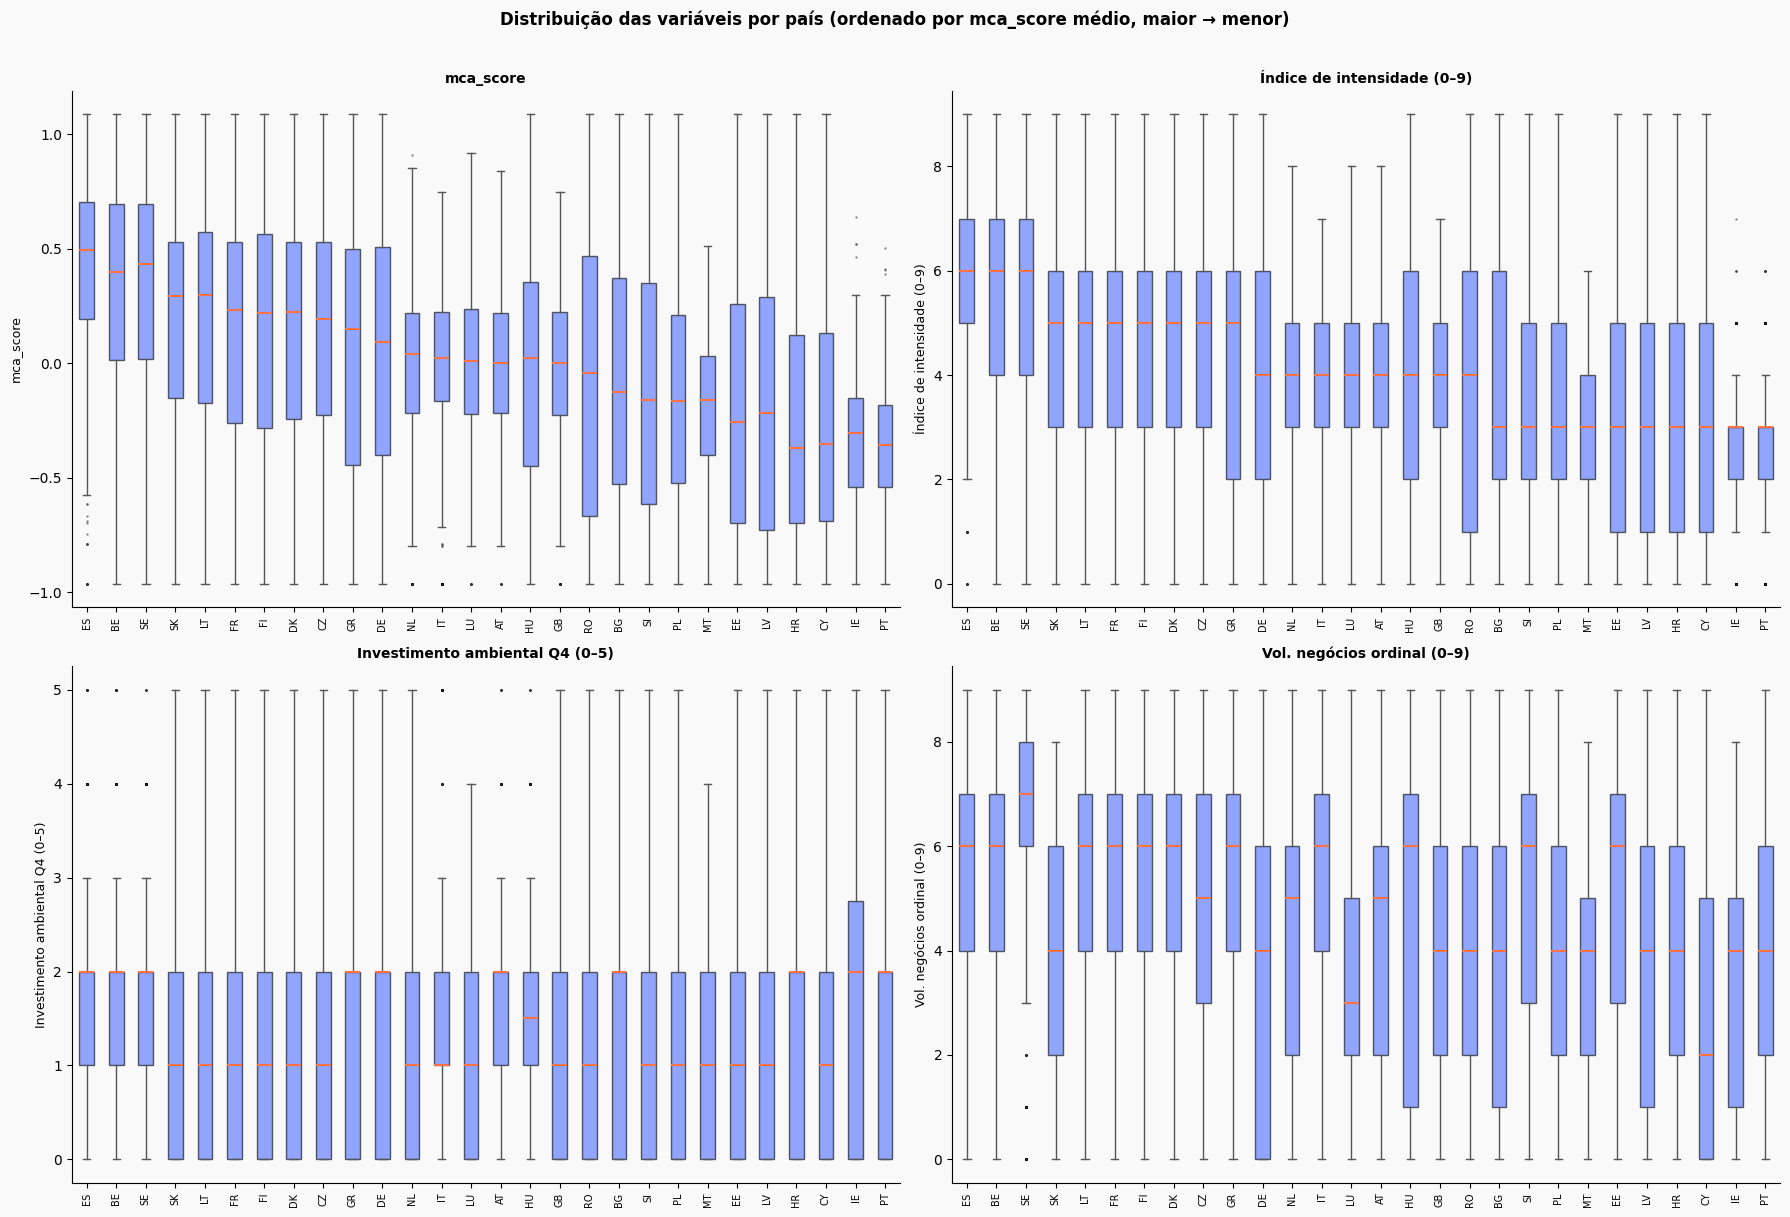

In [104]:
# ── 5.3  Boxplots das variáveis principais × país ───────────────────────────
vars_plot_s5 = [
    ("mca_score",       "mca_score"),
    ("intensity_index", "Índice de intensidade (0–9)"),
    ("investment_code", "Investimento ambiental Q4 (0–5)"),
    ("turnover_size",   "Vol. negócios ordinal (0–9)"),
]

country_order_box = (df_model.groupby("isocntry")["mca_score"]
                     .mean().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor=BG)
axes = axes.flatten()

for ax, (col, label) in zip(axes, vars_plot_s5):
    data_by_country = [
        df_model.loc[df_model["isocntry"] == c, col].dropna().values
        for c in country_order_box
    ]
    ax.boxplot(data_by_country, vert=True, patch_artist=True,
               medianprops=dict(color=ORANGE, linewidth=1.5),
               flierprops=dict(marker=".", markersize=1.5, alpha=0.4,
                               markerfacecolor=LIGHT_BLUE),
               boxprops=dict(facecolor=BLUE, alpha=0.6),
               whiskerprops=dict(color="#555"),
               capprops=dict(color="#555"))
    ax.set_xticks(range(1, len(country_order_box) + 1))
    ax.set_xticklabels(country_order_box, rotation=90, fontsize=7)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

fig.suptitle("Distribuição das variáveis por país (ordenado por mca_score médio, maior → menor)",
             fontsize=12, fontweight="bold", y=1.01)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()


## 5.4 Multicolinearidade por País

O VIF global pode mascarar problemas em países pequenos onde algumas dummies têm variância quase-nula.

In [105]:
# ── 5.4.1  VIF máximo por país ──────────────────────────────────────────────
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings("ignore")

vif_cols_s5 = [
    "d_industry", "d_retail", "d_services",
    "d_small", "d_medium",
    "d_q4_lt1", "d_q4_1_5", "d_q4_6_10", "d_q4_11_30", "d_q4_gt30",
    "no_barriers",
]
vif_cols_s5 = [c for c in vif_cols_s5 if c in df_model.columns]

vif_results = {}
for country in sorted(df_model["isocntry"].unique()):
    df_c = df_model[df_model["isocntry"] == country][vif_cols_s5].dropna()
    if len(df_c) < len(vif_cols_s5) + 5:
        continue
    ok_cols = [c for c in vif_cols_s5 if df_c[c].std() > 0]
    if len(ok_cols) < 3:
        continue
    X_vif = sm.add_constant(df_c[ok_cols].astype(float))
    try:
        vifs = {ok_cols[i]: round(variance_inflation_factor(X_vif.values, i + 1), 2)
                for i in range(len(ok_cols))}
        vif_results[country] = vifs
    except Exception:
        pass

vif_max = {c: max(v.values()) for c, v in vif_results.items()}
vif_max_s = sorted(vif_max.items(), key=lambda x: x[1], reverse=True)

print("=== VIF MÁXIMO POR PAÍS (top 15) ===")
print("(VIF > 5 → possível colinearidade; > 10 → problemático)\n")
for country, maxvif in vif_max_s[:15]:
    flag = "⚠" if maxvif > 5 else "✓"
    print(f"  {country}  {maxvif:>6.2f}  {flag}")


=== VIF MÁXIMO POR PAÍS (top 15) ===
(VIF > 5 → possível colinearidade; > 10 → problemático)

  FI    2.36  ✓
  AT    2.17  ✓
  LV    2.16  ✓
  HU    2.14  ✓
  DK    2.13  ✓
  LT    2.06  ✓
  SI    2.04  ✓
  IE    1.98  ✓
  CZ    1.94  ✓
  PL    1.94  ✓
  FR    1.92  ✓
  CY    1.88  ✓
  IT    1.88  ✓
  BE    1.86  ✓
  ES    1.86  ✓


In [106]:
# ── 5.4.2  VIF médio e máximo por variável (média entre países) ─────────────
vif_df = pd.DataFrame(vif_results).T
print("=== VIF MÉDIO POR VARIÁVEL ===")
print(vif_df.mean().sort_values(ascending=False).round(2).to_string())
print("\n=== VIF MÁX POR VARIÁVEL (pior caso) ===")
print(vif_df.max().sort_values(ascending=False).round(2).to_string())


=== VIF MÉDIO POR VARIÁVEL ===
d_retail       1.86
d_services     1.85
d_industry     1.66
d_q4_1_5       1.44
d_q4_lt1       1.37
d_medium       1.27
d_small        1.24
d_q4_6_10      1.20
no_barriers    1.16
d_q4_11_30     1.10
d_q4_gt30      1.06

=== VIF MÁX POR VARIÁVEL (pior caso) ===
d_retail       2.36
d_services     2.23
d_industry     1.96
d_q4_1_5       1.86
d_q4_lt1       1.79
no_barriers    1.55
d_medium       1.51
d_small        1.41
d_q4_6_10      1.40
d_q4_11_30     1.19
d_q4_gt30      1.18


## 5.5 Modelo Nulo — ICC e Equações do Multinível

**Nível 1 — Empresa $i$ no país $j$:**

$$\text{mca\_score}_{ij} = \beta_{0j} + \beta_{1j}\,\text{setor}_{ij} + \beta_{2j}\,\text{dimensão}_{ij} + \beta_{3j}\,Q4_{ij} + \epsilon_{ij}$$

**Nível 2 — País $j$:**

$$\beta_{0j} = \gamma_{00} + \gamma_{01}\,\text{PIB}_{j} + \gamma_{02}\,\text{PolíticaAmbiental}_{j} + u_{0j}$$

$$\text{ICC} = \frac{\tau_{00}}{\tau_{00} + \sigma^2}$$

In [107]:
# ── 5.5.1  Modelo nulo — ICC formal via mixedlm ─────────────────────────────
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

df_null = df_model.dropna(subset=["mca_score", "isocntry"])

model_null = smf.mixedlm(
    "mca_score ~ 1",
    data=df_null,
    groups=df_null["isocntry"]
).fit(reml=True, disp=False)

tau00  = float(model_null.cov_re.iloc[0, 0])
sigma2 = float(model_null.scale)
icc    = tau00 / (tau00 + sigma2)

print("=== MODELO NULO — INTERCEPT ALEATÓRIO POR PAÍS ===")
print(f"  Variância entre países (τ₀₀):  {tau00:.4f}")
print(f"  Variância residual (σ²):       {sigma2:.4f}")
print(f"  ICC:                           {icc:.4f}  ({icc*100:.1f}%)")
print()
if icc > 0.05:
    print(f"  → {icc*100:.1f}% da variação no mca_score é atribuível ao país.")
    print("    ICC > 5% justifica formalmente o modelo multinível.")
else:
    print("  → ICC baixo — a variação entre países é limitada.")


=== MODELO NULO — INTERCEPT ALEATÓRIO POR PAÍS ===
  Variância entre países (τ₀₀):  0.0392
  Variância residual (σ²):       0.2429
  ICC:                           0.1388  (13.9%)

  → 13.9% da variação no mca_score é atribuível ao país.
    ICC > 5% justifica formalmente o modelo multinível.


## 5.6 Coeficientes Significativos do M3 (mca_score)

In [108]:
# ── 5.6  Coeficientes significativos do M3 sobre mca_score ──────────────────
country_set_s6 = {f"d_{c}" for c in countries_eu}
m3_mca = M_mca["M3"]

sig_idx = m3_mca.pvalues[
    (m3_mca.pvalues < 0.05)
    & (~m3_mca.pvalues.index.isin(country_set_s6))
    & (m3_mca.pvalues.index != "const")
].sort_values().index

coef_df = pd.DataFrame({
    "Coef.":     m3_mca.params[sig_idx].round(4),
    "Std. Err.": m3_mca.bse[sig_idx].round(4),
    "p-value":   m3_mca.pvalues[sig_idx].round(4),
})
print("=== M3 (mca_score) — COEFICIENTES SIGNIFICATIVOS (p < 0.05) ===")
print(coef_df.to_string())

from scipy.stats import pearsonr
corr_vd = pearsonr(df_model["mca_score"], df_model["intensity_index"])[0]
print(f"\nCorrelação mca_score ↔ intensity_index: r = {corr_vd:.4f}")
print("→ Confirma que coeficientes do M3 são robustos à escolha do DV.")


=== M3 (mca_score) — COEFICIENTES SIGNIFICATIVOS (p < 0.05) ===
                   Coef.  Std. Err.  p-value
no_barriers      -0.3853     0.0150   0.0000
d_q4_1_5          0.2401     0.0105   0.0000
d_q4_6_10         0.2666     0.0145   0.0000
d_q4_dkna         0.2361     0.0134   0.0000
d_q3_dec_lit      0.1697     0.0102   0.0000
d_q4_lt1          0.1412     0.0110   0.0000
d_q4_11_30        0.2410     0.0208   0.0000
d_q3_inc_lit      0.1281     0.0112   0.0000
d_q3_dec_lot      0.2036     0.0189   0.0000
q7.5              0.0831     0.0093   0.0000
d_q4_gt30         0.2162     0.0270   0.0000
d_q3_dkna         0.1028     0.0137   0.0000
q7.10             0.0736     0.0098   0.0000
q7.12             0.0794     0.0108   0.0000
d_medium          0.0716     0.0107   0.0000
d_services_sc    -0.0584     0.0089   0.0000
q7.7              0.0634     0.0097   0.0000
d_q3_inc_lot      0.0812     0.0134   0.0000
q7.3              0.0601     0.0103   0.0000
q7.1              0.0522     0.0093 

---
# Secção 6 — Modelo Multinível (HLM)

- **6.1** Carga e integração dos dados de nível 2
- **6.2** Correlação e ACP dos preditores de nível 2
- **6.3** HLM Modelo 1 — intercepto aleatório + preditores de nível 1 (spec. M2)
- **6.4** HLM Modelo 2 — com preditores de nível 2
- **6.5** Tabela comparativa: OLS M2 vs HLM M1 vs HLM M2

## 6.1 Carga e Integração dos Dados de Nível 2

A **base consolidada** (`Base_Consolidada_Final.xlsx`, 27 países × 460 variáveis) agrega:

| Fonte | Variáveis incluídas |
|---|---|
| EDGAR 2025 | GHG total, per capita, por GDP, por sector |
| SDR 2025 | Índice SDG e scores por objectivo (ODS 1-17) |
| EU-SPI 2.0 2024 | Índice de Progresso Social da UE |
| EPI 2024 | Índice de Desempenho Ambiental |
| World Bank WDI | PIB per capita, PIB por empregado |

**Nota de âmbito:** A base cobre os 27 países da UE. O Reino Unido (`GB`), presente na amostra do Eurobarómetro, não tem dados L2 (EU27 apenas). As empresas britânicas são excluídas do HLM M2 (com preditores L2) mas incluídas no HLM M1 (sem L2).

In [109]:
# ── 6.1  Carga e integração dos dados de nível 2 ─────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── 1. Carregar base consolidada ─────────────────────────────────────────────
l2_path   = os.path.join('..', 'things for claude', 'Base_Consolidada_Final.xlsx')
df_l2_raw = pd.read_excel(l2_path)

# ── 2. Mapeamento ISO3 (EDGAR) → ISO2 (isocntry da amostra) ──────────────────
iso3_to_iso2 = {
    'AUT': 'AT', 'BEL': 'BE', 'BGR': 'BG', 'CYP': 'CY', 'CZE': 'CZ',
    'DEU': 'DE', 'DNK': 'DK', 'EST': 'EE', 'GRC': 'GR', 'ESP': 'ES',
    'FIN': 'FI', 'FRA': 'FR', 'HRV': 'HR', 'HUN': 'HU', 'IRL': 'IE',
    'ITA': 'IT', 'LTU': 'LT', 'LUX': 'LU', 'LVA': 'LV', 'MLT': 'MT',
    'NLD': 'NL', 'POL': 'PL', 'PRT': 'PT', 'ROU': 'RO', 'SWE': 'SE',
    'SVN': 'SI', 'SVK': 'SK',
}
df_l2_raw['isocntry'] = df_l2_raw['EDGAR Country Code'].map(iso3_to_iso2)

# ── 3. Verificar cobertura do mapeamento ──────────────────────────────────────
survey_codes  = sorted(df_model['isocntry'].unique())
db_iso2       = set(df_l2_raw['isocntry'].dropna())
missing_in_db = [c for c in survey_codes if c not in db_iso2]
print(f'Códigos na amostra ({len(survey_codes)}): {survey_codes}')
print(f'Sem dados L2:                    {missing_in_db}')

# ── 4. Selecção de candidatos L2 (cobertura 27/27, motivação teórica) ─────────
l2_candidates = {
    'gdp_pc':   'GDPpc_2023',
    'gdp_empl': 'GDP_empl_2023',
    'ghg_pc':   'EDGAR_GHG_percapita_2024',
    'ghg_gdp':  'EDGAR_GHG_perGDP_2024',
    'epi':      'EPI.new',
    'sdg_idx':  '2025 SDG Index Score',
    'sdg12':    'Goal 12 Score',
    'sdg13':    'Goal 13 Score',
    'sdg7':     'Goal 7 Score',
    'eu_spi':   'SPI_Score_EU-SPI',
    'spi_env':  'SPI_Score_Environmental quality',
}
l2_short  = list(l2_candidates.keys())
l2_source = list(l2_candidates.values())

df_l2 = (
    df_l2_raw[['isocntry', 'Country_Name'] + l2_source]
    .rename(columns=dict(zip(l2_source, l2_short)))
    .copy()
)

# ── 5. Integrar com df_model ──────────────────────────────────────────────────
df_model_hlm = df_model.merge(df_l2[['isocntry'] + l2_short], on='isocntry', how='left')

# ── 6. Resumo de cobertura ────────────────────────────────────────────────────
n_total = len(df_model_hlm)
n_gb    = (df_model_hlm['isocntry'] == 'GB').sum()
n_eu27  = n_total - n_gb

print(f'\n=== COBERTURA APÓS INTEGRAÇÃO L2 ===')
print(f'Empresas totais:         {n_total:,}')
print(f'Empresas UK (sem L2):    {n_gb:,}  ({n_gb/n_total*100:.1f}%)')
print(f'Empresas EU27 (com L2):  {n_eu27:,}  ({n_eu27/n_total*100:.1f}%)')
print()
print(f"  {'Var L2':<10}  {'Fonte':<45}  {'Não-nulos':>9}  {'NAs':>4}")
print('  ' + '─' * 74)
for sh, src in l2_candidates.items():
    n_na = df_model_hlm[sh].isna().sum()
    print(f'  {sh:<10}  {src:<45}  {n_total - n_na:>9,}  {n_na:>4}')

# ── 7. Tabela L2 ao nível país (para correlações em 6.2) ──────────────────────
df_l2_eu27 = df_l2.dropna(subset=['isocntry']).set_index('isocntry')[l2_short]
print(f'\nBase L2: {df_l2_eu27.shape[0]} países × {df_l2_eu27.shape[1]} variáveis')
print(df_l2_eu27.round(2).to_string())

Códigos na amostra (28): ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
Sem dados L2:                    ['GB']

=== COBERTURA APÓS INTEGRAÇÃO L2 ===
Empresas totais:         13,559
Empresas UK (sem L2):    435  (3.2%)
Empresas EU27 (com L2):  13,124  (96.8%)

  Var L2      Fonte                                          Não-nulos   NAs
  ──────────────────────────────────────────────────────────────────────────
  gdp_pc      GDPpc_2023                                        13,124   435
  gdp_empl    GDP_empl_2023                                     13,124   435
  ghg_pc      EDGAR_GHG_percapita_2024                          13,124   435
  ghg_gdp     EDGAR_GHG_perGDP_2024                             13,124   435
  epi         EPI.new                                           13,124   435
  sdg_idx     2025 SDG Index Score                              13,124   435
 

## 6.3 HLM Modelo 1 — Intercepto Aleatório (Sem Preditores L2)

Especificação M2 de nível 1 (sem barreiras Q7 — possível endogeneidade), com **intercepto aleatório por país**. Os 27 efeitos fixos de país do OLS M2 são substituídos por um único parâmetro de variância aleatória τ₀₀. Toda a amostra é incluída (EU27 + UK = 28 países).

A comparação dos coeficientes fixos entre HLM M1 e OLS M2 revela se os efeitos de país estavam a distorcer as estimativas ao nível da empresa.

In [110]:
# ── 6.3.1  Estimação do HLM M1 — intercepto aleatório + preditores L1 ────────
import statsmodels.formula.api as smf

# Preditores de nível 1 (spec. M2 sem dummies de país e sem barreiras Q7)
firm_vars_m2 = [
    'd_industry', 'd_retail', 'd_services',
    'd_small', 'd_medium',
    'd_age_2016_18', 'd_age_2019_23', 'd_age_post2023', 'd_age_dkna',
    'd_turn_inc_lot', 'd_turn_inc_lit', 'd_turn_dec', 'd_turn_dkna',
    'd_q3_dec_lot', 'd_q3_dec_lit', 'd_q3_inc_lit', 'd_q3_inc_lot', 'd_q3_dkna',
    'd_q4_lt1', 'd_q4_1_5', 'd_q4_6_10', 'd_q4_11_30', 'd_q4_gt30', 'd_q4_dkna',
    'd_products', 'd_services_sc', 'd_scr16_dkna',
    'turnover_size', 'turnover_unknown', 'fin_difficulty',
]

df_hlm1      = df_model_hlm[firm_vars_m2 + ['mca_score', 'isocntry']].dropna().copy()
formula_hlm1 = 'mca_score ~ ' + ' + '.join(firm_vars_m2)

hlm1 = smf.mixedlm(formula_hlm1, data=df_hlm1, groups=df_hlm1['isocntry']).fit(reml=True, disp=False)

# ── Componentes de variância e ICC ───────────────────────────────────────────
tau00_hlm1  = float(hlm1.cov_re.iloc[0, 0])
sigma2_hlm1 = float(hlm1.scale)
icc_hlm1    = tau00_hlm1 / (tau00_hlm1 + sigma2_hlm1)

print('=== HLM M1 — AJUSTE E COMPONENTES DE VARIÂNCIA ===')
print(f'N empresas:                      {int(hlm1.nobs):,}')
print(f'N países (grupos):               {df_hlm1["isocntry"].nunique()}')
print(f'Log-Likelihood (REML):           {hlm1.llf:.2f}')
print(f'AIC:                             {hlm1.aic:.1f}')
print(f'BIC:                             {hlm1.bic:.1f}')
print()
print(f'τ₀₀ (variância entre países):    {tau00_hlm1:.6f}')
print(f'σ²  (variância dentro de países):{sigma2_hlm1:.6f}')
print(f'ICC residual:                    {icc_hlm1:.4f}  ({icc_hlm1*100:.1f}% explicado por país)')
print()
print('Nota: ICC do modelo nulo (Secção 5.5) para referência — ICC deve cair')
print('após inclusão dos preditores L1 se estes absorverem variância entre países.')


=== HLM M1 — AJUSTE E COMPONENTES DE VARIÂNCIA ===
N empresas:                      13,559
N países (grupos):               28
Log-Likelihood (REML):           -8123.52
AIC:                             nan
BIC:                             nan

τ₀₀ (variância entre países):    0.033268
σ²  (variância dentro de países):0.189703
ICC residual:                    0.1492  (14.9% explicado por país)

Nota: ICC do modelo nulo (Secção 5.5) para referência — ICC deve cair
após inclusão dos preditores L1 se estes absorverem variância entre países.


In [111]:
# ── 6.3.2  Coeficientes fixos + comparação com OLS M2 ──────────────────────

# Tabela de coeficientes HLM M1
hlm1_coef = pd.DataFrame({
    'Coef.':    hlm1.params,
    'Std.Err.': hlm1.bse,
    'z':        hlm1.tvalues,
    'p-value':  hlm1.pvalues,
    'CI 2.5%':  hlm1.conf_int()[0],
    'CI 97.5%': hlm1.conf_int()[1],
}).drop(index=['Group Var'], errors='ignore').round(4)

sig_mask = hlm1_coef['p-value'] < 0.05
print('=== HLM M1 — COEFICIENTES FIXOS SIGNIFICATIVOS (p<0.05) ===')
print(hlm1_coef[sig_mask].to_string())
print()
print('=== HLM M1 — COEFICIENTES NÃO SIGNIFICATIVOS ===')
print(hlm1_coef[~sig_mask].to_string())

# ── Comparação HLM M1 vs OLS M2 (coeficientes firma-nível) ──────────────────
country_dummy_set = {f'd_{c}' for c in countries_eu} | {'const'}
ols_m2_coefs = (
    M_mca['M2'].params
    .drop(index=[v for v in M_mca['M2'].params.index if v in country_dummy_set])
)
hlm1_firm_coefs = hlm1.params.drop(index=['Intercept', 'Group Var'], errors='ignore')

common_vars = ols_m2_coefs.index.intersection(hlm1_firm_coefs.index)
comp_df = pd.DataFrame({
    'OLS M2':       ols_m2_coefs[common_vars].round(4),
    'HLM M1':       hlm1_firm_coefs[common_vars].round(4),
    'Δ (HLM−OLS)':  (hlm1_firm_coefs[common_vars] - ols_m2_coefs[common_vars]).round(4),
    'Mudança (%)':  ((hlm1_firm_coefs[common_vars] - ols_m2_coefs[common_vars])
                     / ols_m2_coefs[common_vars].abs() * 100).round(1),
})
print('\n=== COMPARAÇÃO COEFICIENTES FIRMA-NÍVEL: OLS M2 vs HLM M1 ===')
print(comp_df.to_string())
print(f'\nMáxima variação absoluta: {comp_df["Δ (HLM−OLS)"].abs().max():.4f}')
print(f'Variável mais afectada:   {comp_df["Δ (HLM−OLS)"].abs().idxmax()}')


=== HLM M1 — COEFICIENTES FIXOS SIGNIFICATIVOS (p<0.05) ===
                Coef.  Std.Err.        z  p-value  CI 2.5%  CI 97.5%
Intercept     -0.3882    0.0390  -9.9458   0.0000  -0.4647   -0.3117
d_industry    -0.0379    0.0124  -3.0486   0.0023  -0.0622   -0.0135
d_retail      -0.0463    0.0110  -4.2030   0.0000  -0.0679   -0.0247
d_services    -0.0654    0.0117  -5.5992   0.0000  -0.0882   -0.0425
d_small        0.0220    0.0092   2.3912   0.0168   0.0040    0.0400
d_medium       0.0718    0.0115   6.2178   0.0000   0.0492    0.0945
d_q3_dec_lot   0.2890    0.0202  14.3413   0.0000   0.2495    0.3285
d_q3_dec_lit   0.2760    0.0106  26.0509   0.0000   0.2552    0.2967
d_q3_inc_lit   0.2432    0.0117  20.8509   0.0000   0.2204    0.2661
d_q3_inc_lot   0.2091    0.0141  14.8553   0.0000   0.1815    0.2367
d_q3_dkna      0.1834    0.0145  12.6231   0.0000   0.1549    0.2119
d_q4_lt1       0.2568    0.0115  22.3736   0.0000   0.2343    0.2793
d_q4_1_5       0.3557    0.0109  32.5280   

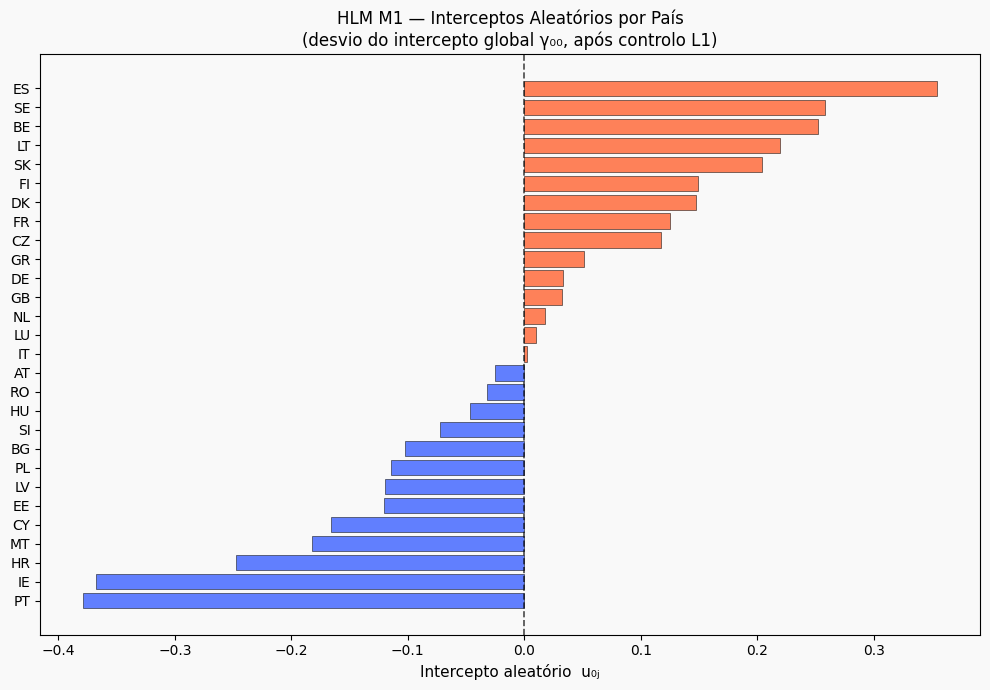

=== INTERCEPTOS ALEATÓRIOS (u₀ⱼ) POR PAÍS ===
       u₀ⱼ Sinal
PT -0.3790     ↓
IE -0.3674     ↓
HR -0.2473     ↓
MT -0.1821     ↓
CY -0.1656     ↓
EE -0.1205     ↓
LV -0.1197     ↓
PL -0.1143     ↓
BG -0.1025     ↓
SI -0.0725     ↓
HU -0.0464     ↓
RO -0.0317     ↓
AT -0.0253     ↓
IT  0.0024     ↑
LU  0.0097     ↑
NL  0.0178     ↑
GB  0.0324     ↑
DE  0.0333     ↑
GR  0.0516     ↑
CZ  0.1173     ↑
FR  0.1251     ↑
DK  0.1472     ↑
FI  0.1491     ↑
SK  0.2038     ↑
LT  0.2198     ↑
BE  0.2521     ↑
SE  0.2580     ↑
ES  0.3547     ↑


In [120]:
# ── 6.3.3  Interceptos aleatórios por país ───────────────────────────────────
re_vals = {k: float(v.iloc[0]) for k, v in hlm1.random_effects.items()}
re_df   = pd.Series(re_vals, name='u0j').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
colors  = [ORANGE if v > 0 else BLUE for v in re_df]
ax.barh(re_df.index, re_df.values, color=colors, edgecolor='black', linewidth=0.4, alpha=0.88)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Intercepto aleatório  u₀ⱼ', color='black', fontsize=11)
ax.set_title('HLM M1 — Interceptos Aleatórios por País\n'
             '(desvio do intercepto global γ₀₀, após controlo L1)', color='black', fontsize=12)
ax.tick_params(colors='black')
ax.set_facecolor(BG)
for sp in ax.spines.values():
    sp.set_edgecolor('black')
plt.tight_layout()
plt.savefig('../reports/figures/hlm_m1_random_effects.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

print('=== INTERCEPTOS ALEATÓRIOS (u₀ⱼ) POR PAÍS ===')
re_table = pd.DataFrame({'u₀ⱼ': re_df.round(4), 'Sinal': ['↑' if v > 0 else '↓' for v in re_df]})
print(re_table.to_string())


In [121]:
# ── Exportação para Streamlit app ────────────────────────────────────────────
# Executar após correr o notebook completo — gera o CSV usado pela app interactiva
import os

q1_bin_cols = [f'q1.{i}_bin' for i in range(1, 10)]
export_cols = (
    ['isocntry', 'mca_score', 'intensity_index', 'nace_b', 'scr10', 'investment_code']
    + [c for c in q1_bin_cols if c in df_model.columns]
    + ['fin_difficulty', 'turnover_size']
)

out_path = os.path.join('..', 'data', 'processed', 'df_model_app.csv')
df_model[export_cols].to_csv(out_path, index=False)
print(f'Exportado: {df_model[export_cols].shape[0]:,} linhas × {len(export_cols)} colunas')
print(f'Ficheiro: {out_path}')
print(f'Colunas: {export_cols}')

Exportado: 13,559 linhas × 17 colunas
Ficheiro: ..\data\processed\df_model_app.csv
Colunas: ['isocntry', 'mca_score', 'intensity_index', 'nace_b', 'scr10', 'investment_code', 'q1.1_bin', 'q1.2_bin', 'q1.3_bin', 'q1.4_bin', 'q1.5_bin', 'q1.6_bin', 'q1.7_bin', 'q1.8_bin', 'q1.9_bin', 'fin_difficulty', 'turnover_size']
